#Cloning and install

Applied sequence ssfpdx_n8

In [1]:
#Cloning Data Repository
!git clone https://github.com/Gian7620/SSFP---Daphnias-Data.git

Cloning into 'SSFP---Daphnias-Data'...
remote: Enumerating objects: 44, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 44 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (44/44), 15.80 MiB | 7.70 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [2]:
#Baselines correction library
!pip install pybaselines

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.9/211.9 kB 9.0 MB/s eta 0:00:00


#Smoothing Function and SNR calculation

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from pybaselines import Baseline
from pybaselines.whittaker import arpls

def calculate_nmr_manufactured_noise(noise_data):

    #Length of noise data
    N = len(noise_data)

    if N == 0:
        return 0.0 # No noise data, so assume 0 noise

    # If N is 1 or 2, std dev can be calculated (for N=1, std is 0). Bruker formula does not apply.
    if N < 3 or N % 2 == 0:
        # NMR Manufactured Equation formula requires N >= 3 and odd. Fallback to standard deviation.
        return np.std(noise_data)

    # Now N is guaranteed to be >= 3 and odd for the Bruker formula
    n = (N - 1) // 2

    # Term 1: Sum from i=-n to n of y(i)^2
    sum_i_sq = np.sum(noise_data**2)

    # Term 2: Sum from i=-n to n of y(i)
    sum_i = np.sum(noise_data)

    # Term 3: Sum from i=1 to n of i * (y(i) - y(-i))^2
    i_indices = np.arange(1, n + 1)

    # Mapping symmetric indices to array indices: y(i) -> n+i, y(-i) -> n-i
    y_i = noise_data[n + i_indices]
    y_neg_i = noise_data[n - i_indices]

    diff_term_sum = np.sum(i_indices * (y_i - y_neg_i)**2)

    # Assemble the numerator and denominator
    numerator = sum_i_sq - (1/N) * (sum_i**2 + (3*(diff_term_sum)**2) / (N**2 - 1))
    denominator = N - 1

    if numerator < 0:
        # Using the standard deviation as a fallback in case the numerator inside the square root results negative.
        return np.std(noise_data)
    else:
        # Denominator should not be 0 here as N >= 3, so N-1 >= 2
        return np.sqrt(numerator / denominator)

def calculate_noise_mean(noise_data):
  return np.mean(np.abs(noise_data))

def calculate_noise_rms(noise_data):
  return np.sqrt(np.mean(noise_data**2))

def calculate_noise_max(noise_data):
  norma_max=np.linalg.norm(noise_data,ord=np.inf)
  return norma_max

def smooth_function_daphnias(ssfp_file,proton_file,exponent_lambda,peso,upper_limit,lower_limit,noise_range,width_length,polyorder,Normalyzed):
    path_proton='/content/SSFP---Daphnias-Data/Times - Proton - Daphnias/Times - Proton'
    path_ssfp='/content/SSFP---Daphnias-Data/Times - SSFP - Daphnias/Times - SSFP'
    input_filename=f'{path_ssfp}/{ssfp_file}'
    proton_filename=f'{path_proton}/{proton_file}'
    data = np.genfromtxt(input_filename, delimiter=',',
                        skip_footer=1, skip_header=1)
    data_proton = np.genfromtxt(proton_filename, delimiter=',',
                        skip_footer=1, skip_header=1)

    intensity_irregular_in = data[:, 0]
    chemical_shift_in = data[:, 2]
    intensity_proton_in = data_proton[:, 0]
    chemical_shift_proton_in = data_proton[:, 2]

    # Apply initial general Daphnias range filtering to SSFP data
    mask_ssfp_daphnias = (chemical_shift_in <= 10) & (chemical_shift_in >= -1)
    data_daphnias = data[mask_ssfp_daphnias]

    # Derive initial intensity and chemical shift from the filtered SSFP data
    intensity_irregular = data_daphnias[:, 0]
    chemical_shift = data_daphnias[:, 2]

    # Apply initial general Daphnias range filtering to Proton data using its own chemical shift
    mask_proton_daphnias = (chemical_shift_proton_in <= 10) & (chemical_shift_proton_in >= -0.7)
    data_daphnias_proton = data_proton[mask_proton_daphnias]
    intensity_proton_in = data_daphnias_proton[:, 0]
    chemical_shift_proton = data_daphnias_proton[:, 2]

    # Existing data processing steps
    lambda_coef=10**exponent_lambda
    fitter= Baseline(x_data=chemical_shift)
    baseline, params=fitter.iasls(intensity_irregular,lam=lambda_coef,p=peso)
    intensity= intensity_irregular-baseline
    smoothed_intensity_prev = savgol_filter(intensity, width_length,polyorder)
    baseline2, params2=fitter.iasls(smoothed_intensity_prev,lam=lambda_coef,p=peso)
    smoothed_intensity = smoothed_intensity_prev-baseline2

    #Processing Proton intensity
    fitter3= Baseline(x_data=chemical_shift_proton)
    baseline_proton, params_proton=fitter3.iasls(intensity_proton_in,lam=lambda_coef,p=peso)
    intensity_proton= intensity_proton_in-baseline_proton

    # Metrics calculation (RMSD, Roughness, Integral Difference)
    differences=intensity-smoothed_intensity
    rmsd = np.sqrt(np.mean(differences**2))
    mean_intensity=np.mean(np.abs(intensity))
    rmsd_relative=(rmsd/mean_intensity)*100
    roughness_original=np.sum(np.diff(intensity, n=2)**2)
    roughness_smoothed=np.sum(np.diff(smoothed_intensity, n=2)**2)
    roughness_difference=((roughness_original-roughness_smoothed)/roughness_original)*100

    integral_original=np.abs(np.trapezoid(intensity,chemical_shift))
    integral_suavizada=np.abs(np.trapezoid(smoothed_intensity,chemical_shift))
    if integral_original != 0:
        diferencia_integral=(np.abs(integral_suavizada-integral_original)/integral_original)*100
    else:
        diferencia_integral='Can not be calculated'

    # SNR Calculation for comparison
    cs_noise_min, cs_noise_max = noise_range
    noise_mask = (chemical_shift >= cs_noise_min) & (chemical_shift <= cs_noise_max)

    # 1. SNR - Original (Raw Data) - NMR Manufactured Equation
    noise_data_raw = intensity_irregular[noise_mask]
    signal_raw = np.max(np.abs(intensity_irregular)) # Signal from full raw spectrum

    noise_estimate_raw = calculate_nmr_manufactured_noise(noise_data_raw)
    snr_raw = signal_raw/(2*noise_estimate_raw)
    snr_metric_raw = f'SNR Raw: {snr_raw:.4f}\n'

    # 2. SNR - After Baseline Correction (Before Denoising)
    noise_data_baseline_corrected = intensity[noise_mask]
    signal_baseline_corrected = np.max(np.abs(intensity)) # Signal from full baseline-corrected spectrum

    noise_estimate_baseline_corrected = calculate_nmr_manufactured_noise(noise_data_baseline_corrected)
    snr_baseline_corrected = signal_baseline_corrected/(noise_estimate_baseline_corrected*2)
    snr_metric_baseline_corrected = f'SNR Baseline-Corrected: {snr_baseline_corrected:.4f}\n'

    # 3. SNR - After Denoising - NMR Manufactured Equation
    noise_data_smoothed = smoothed_intensity[noise_mask]
    signal_smoothed = np.max(np.abs(smoothed_intensity)) # Signal from full smoothed spectrum

    noise_estimate_smoothed = calculate_nmr_manufactured_noise(noise_data_smoothed)
    snr_smoothed = signal_smoothed/(noise_estimate_smoothed*2)
    snr_metric_smoothed = f'SNR NMR Manufactured Equ. Smoothed: {snr_smoothed:.4f}\n'

    #4. SNR - Original - Mean
    noise_data_mean = intensity_irregular[noise_mask]
    snr_mean_raw = (signal_raw)/(calculate_noise_mean(noise_data_mean)*2)
    snr_metric_mean_raw = f'SNR Mean Raw: {snr_mean_raw:.4f}\n'

    #5 SNR - After denoising Mean
    noise_data_mean_corrected = smoothed_intensity[noise_mask]
    snr_mean_corrected = (signal_smoothed)/(calculate_noise_mean(noise_data_mean_corrected)*2)
    snr_metric_mean_corrected = f'SNR Mean Smoothed: {snr_mean_corrected:.4f}\n'

    #6. SNR - Original - RMS
    noise_data_rms = intensity_irregular[noise_mask]
    snr_rms_raw = (signal_raw)/(calculate_noise_rms(noise_data_rms)*2)
    snr_metric_rms_raw = f'SNR Mean Raw: {snr_rms_raw:.4f}\n'

    #7 SNR - After denoising RMS
    noise_data_rms_corrected = smoothed_intensity[noise_mask]
    snr_rms_corrected = (signal_smoothed)/(calculate_noise_rms(noise_data_rms_corrected)*2)
    snr_metric_rms_corrected = f'SNR Mean Smoothed: {snr_rms_corrected:.4f}\n'

    #8. SNR - Original - Max
    noise_data_max = intensity_irregular[noise_mask]
    snr_max_raw = (signal_raw)/(calculate_noise_max(noise_data_max)*2)
    snr_metric_max_raw = f'SNR Mean Raw: {snr_max_raw:.4f}\n'

    #9 SNR - After denoising - Max
    noise_data_max_corrected = smoothed_intensity[noise_mask]
    snr_max_corrected = (signal_smoothed)/(calculate_noise_max(noise_data_max_corrected)*2)
    snr_metric_max_corrected = f'SNR Mean Smoothed: {snr_max_corrected:.4f}\n'

    #10 Table of SNR:
    data_snr=np.array([
        [snr_raw,snr_mean_raw,snr_rms_raw,snr_max_raw],
        [snr_smoothed, snr_mean_corrected, snr_rms_corrected, snr_max_corrected]
    ])

    lines_names=np.array(["Original","Denoised"])
    columns_names=np.array(["NMR Manufactured Equation","Mean Equation","RMS Equation","Max Equation"])
    data_snr_df=pd.DataFrame(data_snr,index=lines_names,columns=columns_names)

    # Defining metrics for full spectrum
    metrics_nmr_full=f'RMSD Relative by Mean:{rmsd_relative:.2f}%\nRoughness reduction: {roughness_difference:.2f}%\nIntegral Difference:{diferencia_integral:.2E}%'

    data_base_correct = pd.DataFrame({'Chemical Shift': chemical_shift, 'Intensity': intensity})
    data_smooth = pd.DataFrame({'Chemical Shift': chemical_shift, 'Intensity': smoothed_intensity})

    # Delimited range in Spectrum:
    mask = (chemical_shift <= upper_limit) & (chemical_shift >= lower_limit)
    original_data_extracted=data_daphnias[mask] # Use data_daphnias here
    intensity_original_extracted=original_data_extracted[:,0]
    chemical_shift_original_ex=original_data_extracted[:,2]
    extracted_data_df = data_smooth[mask]
    chemical_shift_extracted = extracted_data_df['Chemical Shift'].values
    smoothed_intensity_extracted = extracted_data_df['Intensity'].values

    #For Proton spectrum:
    # Using the already filtered 'chemical_shift_proton' from data_daphnias_proton
    mask_proton = (chemical_shift_proton <= upper_limit) & (chemical_shift_proton >= lower_limit)
    data_proton_extracted=data_daphnias_proton[mask_proton]
    intensity_proton_extracted_prev=data_proton_extracted[:,0]
    chemical_shift_proton_extracted=data_proton_extracted[:,2]
    fitter4= Baseline(x_data=chemical_shift_proton_extracted)
    baseline_proton_extracted, params_proton_extracted=fitter4.iasls(intensity_proton_extracted_prev,lam=lambda_coef,p=peso)
    intensity_proton_extracted = intensity_proton_extracted_prev-baseline_proton_extracted

    # Normalyzation procedure
    if Normalyzed == True:
        def safe_normalize(arr):
            if arr.size == 0 or np.all(arr == 0):
                return np.zeros_like(arr) # Return an array of zeros if empty or all zeros
            max_val = np.max(arr)
            return arr / max_val

        intensity_proton_norm = safe_normalize(intensity_proton)
        intensity_proton_extracted_norm = safe_normalize(intensity_proton_extracted)
        intensity_norm = safe_normalize(intensity)
        smoothed_intensity_norm = safe_normalize(smoothed_intensity)
        smoothed_intensity_extracted_norm = safe_normalize(smoothed_intensity_extracted)

        mention = '(Normalized)'
    else:
        intensity_proton_norm=intensity_proton
        intensity_proton_extracted_norm=intensity_proton_extracted
        intensity_norm=intensity
        smoothed_intensity_norm=smoothed_intensity
        smoothed_intensity_extracted_norm=smoothed_intensity_extracted
        mention = '(Not normalized)'

    # Plotting:
    plt.figure(figsize=(13,9))

    plt.subplot(2, 2, 1)
    plt.plot(chemical_shift,intensity_irregular,lw=0.5)
    plt.plot(chemical_shift, intensity, lw=0.5)
    plt.legend(['Original','Baseline correction'])
    plt.title('NMR normal (Full)')
    plt.xlabel('Chemical shift (ppm)')
    plt.ylabel('Intensity')
    plt.gca().invert_xaxis()

    plt.subplot(2, 2, 2)
    plt.plot(chemical_shift, intensity_irregular, lw=0.5)
    plt.plot(chemical_shift, smoothed_intensity, lw=0.5,color='red')
    plt.legend(['Original','Denoised'])
    plt.title('NMR smooth (Full)')
    plt.xlabel('Chemical shift (ppm)')
    plt.ylabel('Intensity')
    plt.gca().invert_xaxis()

    plt.subplot(2, 2, 3)
    plt.plot(chemical_shift_proton,intensity_proton_norm,lw=0.5,color='black')
    plt.plot(chemical_shift, intensity_norm, lw=0.5,color='blue')
    plt.plot(chemical_shift, smoothed_intensity_norm, lw=0.5,color='red')
    plt.title('NMR SSFP(Full) vs 1H NMR')
    plt.xlabel('Chemical shift (ppm)')
    plt.ylabel(f'Intensity\n{mention}')
    plt.gca().invert_xaxis()
    plt.legend(['1H NMR','Baseline correction', 'Denoised'])
    plt.text(0.45, 0.95, metrics_nmr_full, transform=plt.gca().transAxes, fontsize=10,
            verticalalignment='top', horizontalalignment='right',bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

    plt.subplot(2,2,4)
    plt.plot(chemical_shift_proton_extracted,intensity_proton_extracted_norm,lw=0.5,color='black',label='1H NMR')
    plt.plot(chemical_shift_extracted, smoothed_intensity_extracted_norm, lw=0.5,color='red',label='Denoised')
    plt.title('NMR SSFP(Zoomed) vs 1H NMR')
    plt.xlabel('Chemical shift (ppm)')
    plt.ylabel(f'Intensity\n{mention}')
    plt.legend()
    plt.gca().invert_xaxis()

    plt.tight_layout()
    plt.show()
    print("\n")
    print("SNR Results")
    print(data_snr_df)


###Time 1 (Oh)

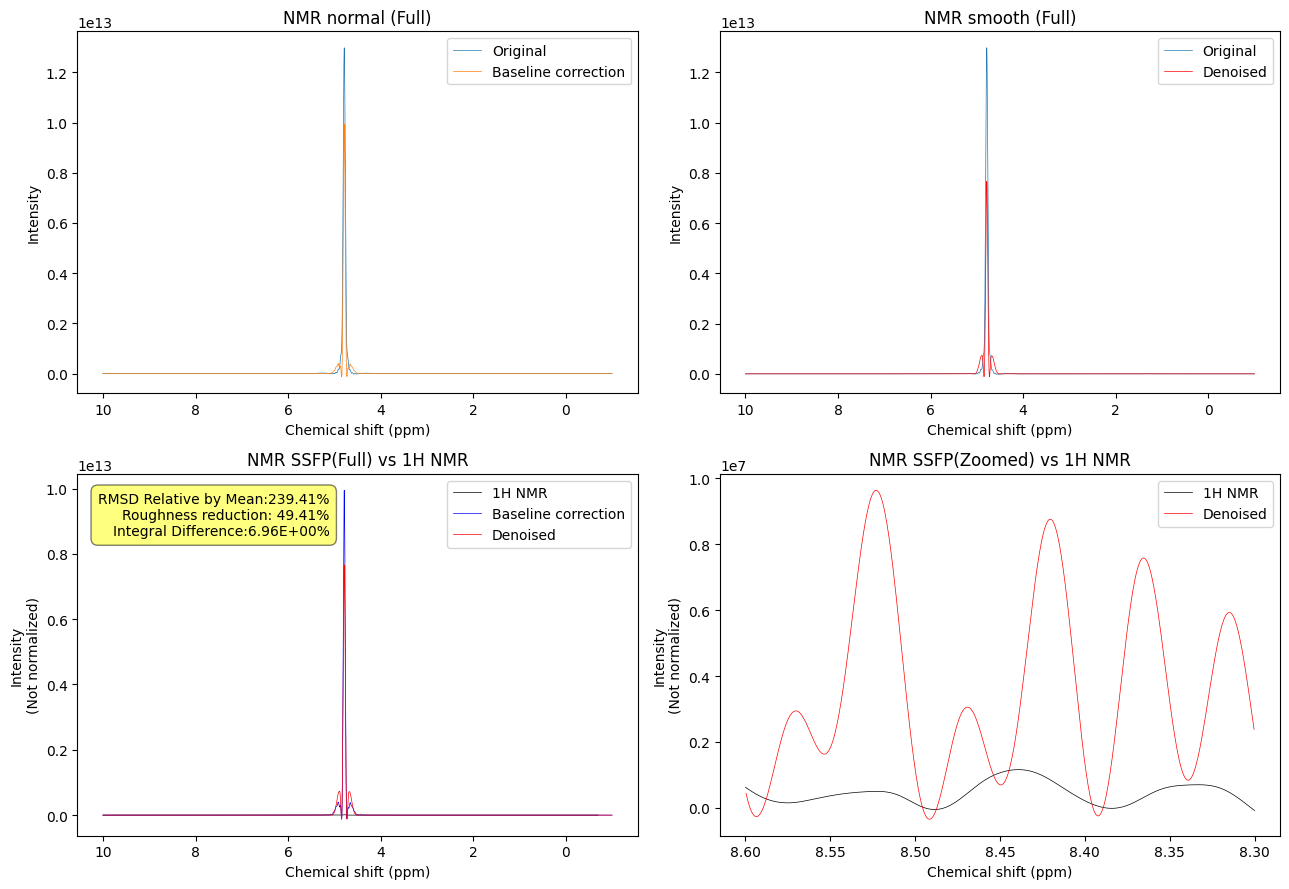



SNR Results
          NMR Manufactured Equation  Mean Equation   RMS Equation  \
Original               8.380334e+04   94093.163203   80515.852753   
Denoised               1.178354e+06  939286.810226  738388.527805   

           Max Equation  
Original   38892.977881  
Denoised  355283.162070  


In [87]:
smooth_function_daphnias('1.Time_1_n6.csv','1.Time_1_n6-proton.csv',5,0.06,8.6,8.3,(-0.60,-0.10),141,2,False)

###Time 2 (1h 30 min)

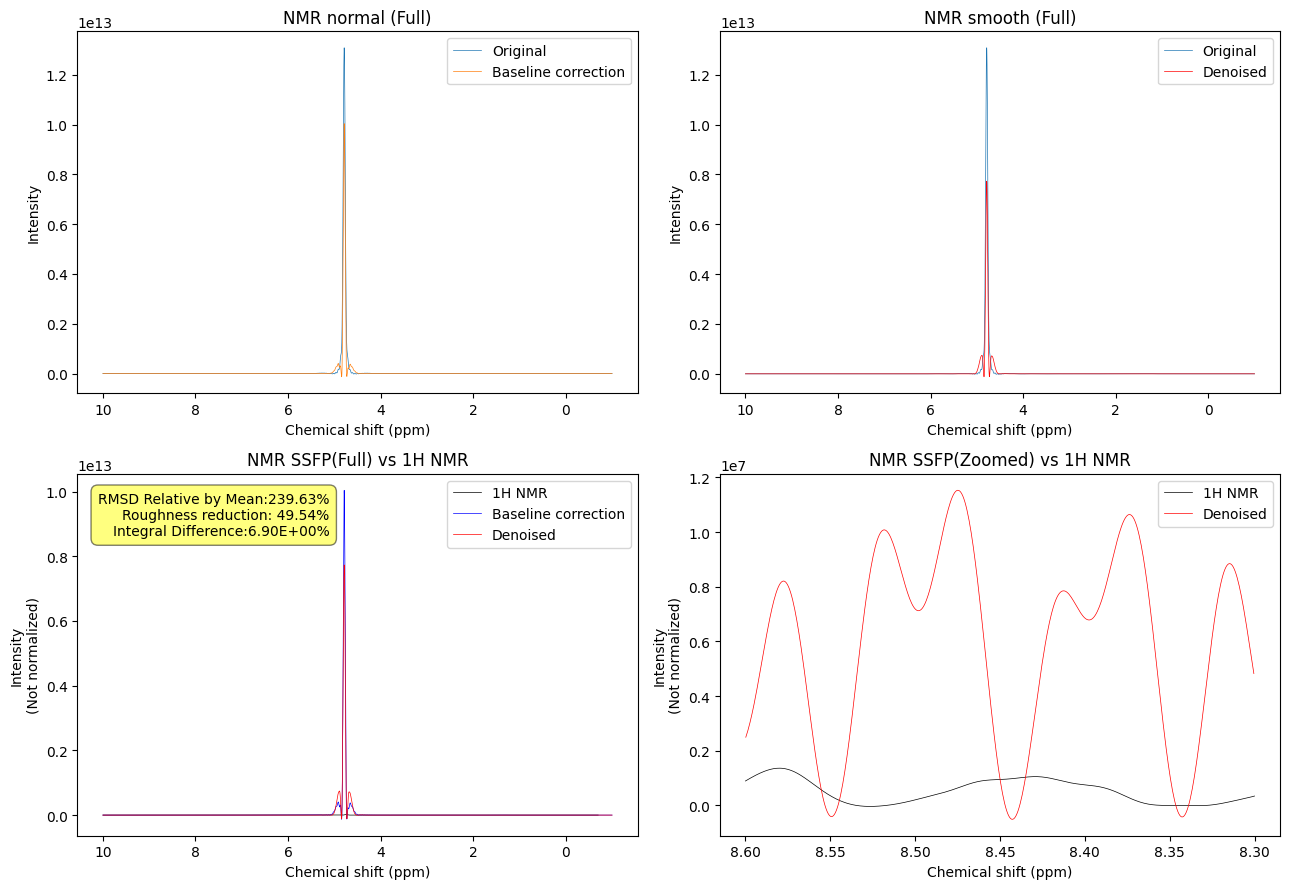



SNR Results
          NMR Manufactured Equation  Mean Equation   RMS Equation  \
Original               8.395082e+04   90913.071094   74761.927928   
Denoised               1.063264e+06  967801.826253  718817.612055   

           Max Equation  
Original   35347.276639  
Denoised  262568.362295  


In [51]:
smooth_function_daphnias('2.Time_2_n8.csv','2.Time_2_n8-proton.csv',5,0.06,8.6,8.3,(-0.60,-0.10),141,2,False)

###Time 3 (3h)

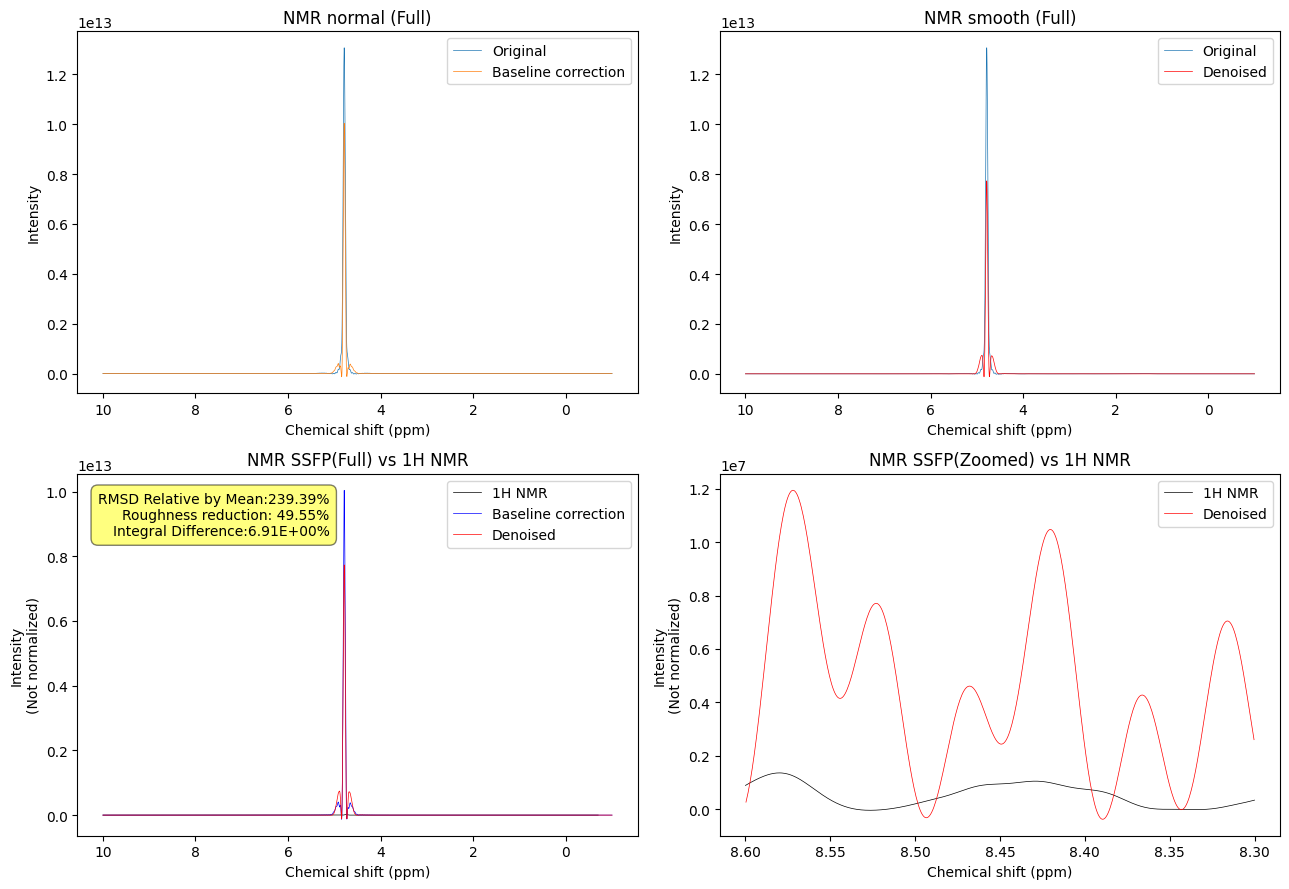



SNR Results
          NMR Manufactured Equation  Mean Equation  RMS Equation  \
Original               8.573226e+04   9.719958e+04  8.326748e+04   
Denoised               2.187295e+06   1.646817e+06  1.322786e+06   

           Max Equation  
Original   40151.974466  
Denoised  571658.681212  


In [52]:
smooth_function_daphnias('3.Time_3_n10.csv','3.Time_2_n8-proton.csv',5,0.06,8.6,8.3,(-0.60,-0.10),141,2,False)

###Time 4 (4h 30 min)

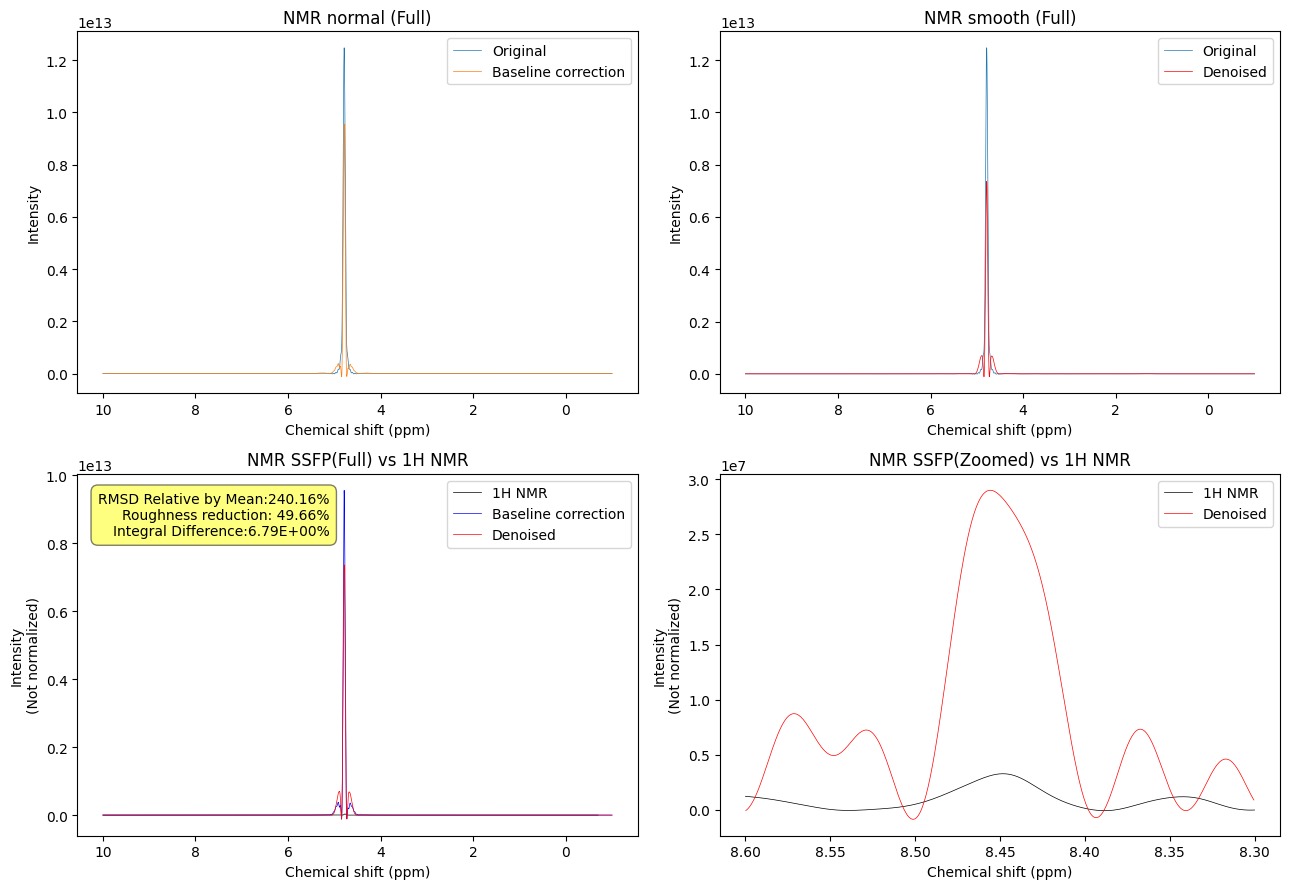



SNR Results
          NMR Manufactured Equation  Mean Equation  RMS Equation  \
Original               8.677128e+04   9.416576e+04  7.776328e+04   
Denoised               1.824241e+06   1.438620e+06  1.133661e+06   

           Max Equation  
Original   35560.307069  
Denoised  498253.294390  


In [53]:
smooth_function_daphnias('4.Time_4_n_14.csv','4.Time_4_n_14-proton.csv',5,0.06,8.6,8.3,(-0.60,-0.10),141,2,False)

###Time 5 (6h)

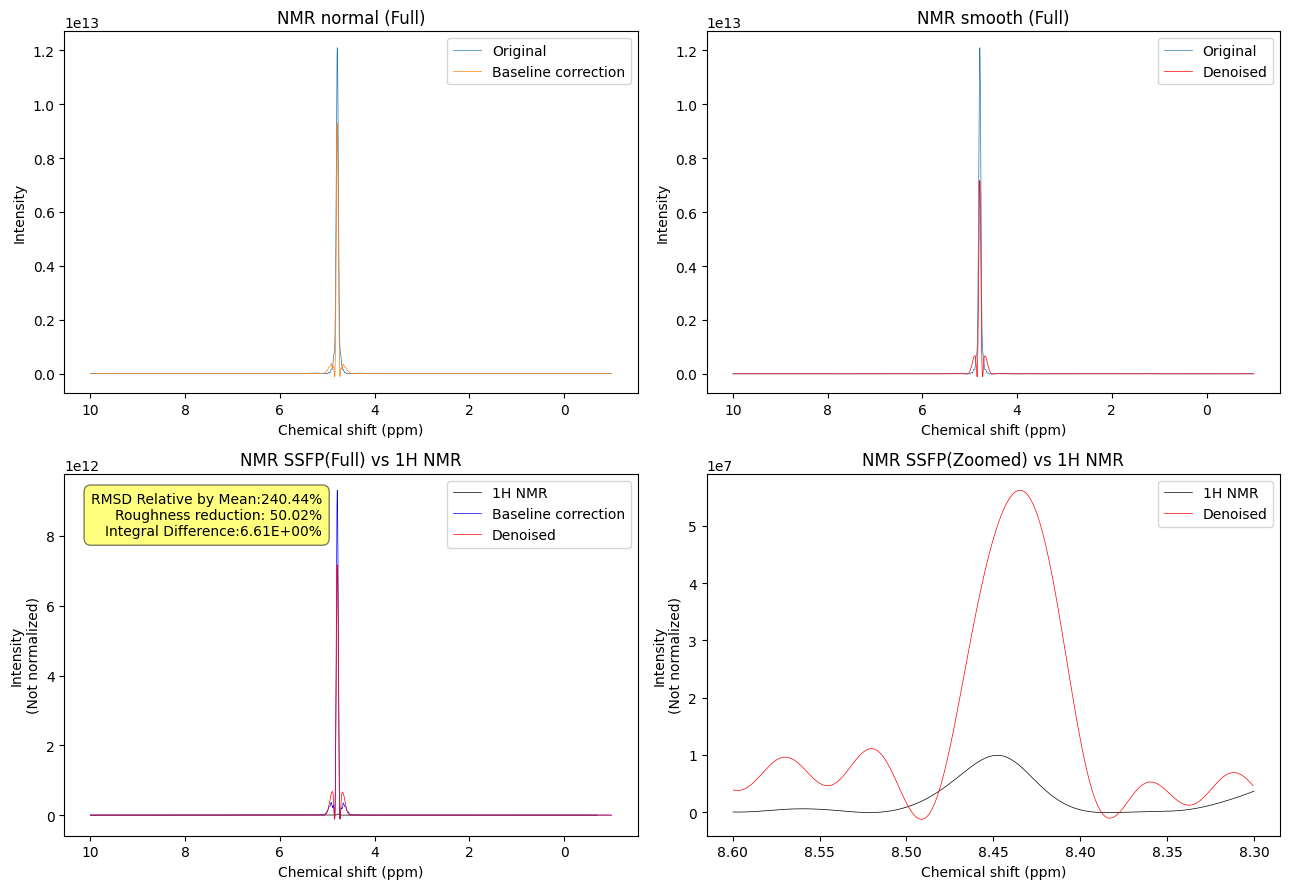



SNR Results
          NMR Manufactured Equation  Mean Equation   RMS Equation  \
Original               6.733294e+04   4.277620e+04   36106.119127   
Denoised               1.436045e+06   1.355100e+06  989180.503193   

           Max Equation  
Original   15145.728535  
Denoised  371509.481995  


In [54]:
smooth_function_daphnias('5.Time_5_n_17.csv','5.Time_5_n_17-proton.csv',5,0.06,8.6,8.3,(-0.60,-0.10),141,2,False)

###Time 6 (7h 30min)

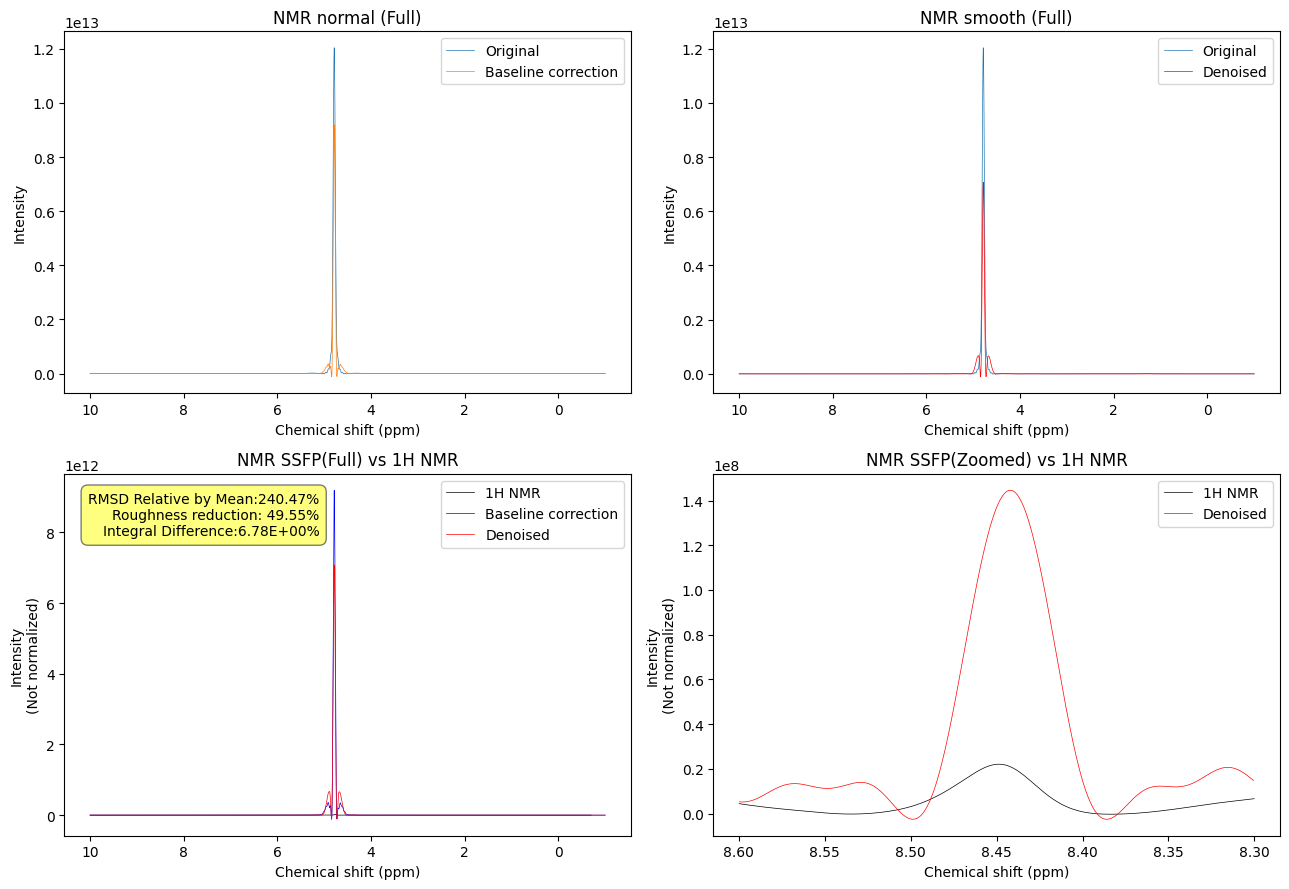



SNR Results
          NMR Manufactured Equation  Mean Equation  RMS Equation  \
Original               8.509444e+04   9.557617e+04  8.223245e+04   
Denoised               2.079168e+06   1.724582e+06  1.334261e+06   

           Max Equation  
Original   37815.218873  
Denoised  561614.062677  


In [55]:
smooth_function_daphnias('6.Time_6_n_20.csv','6.Time_6_n_20-proton.csv',5,0.06,8.6,8.3,(-0.60,-0.10),141,2,False)

###Time 7 (9h)

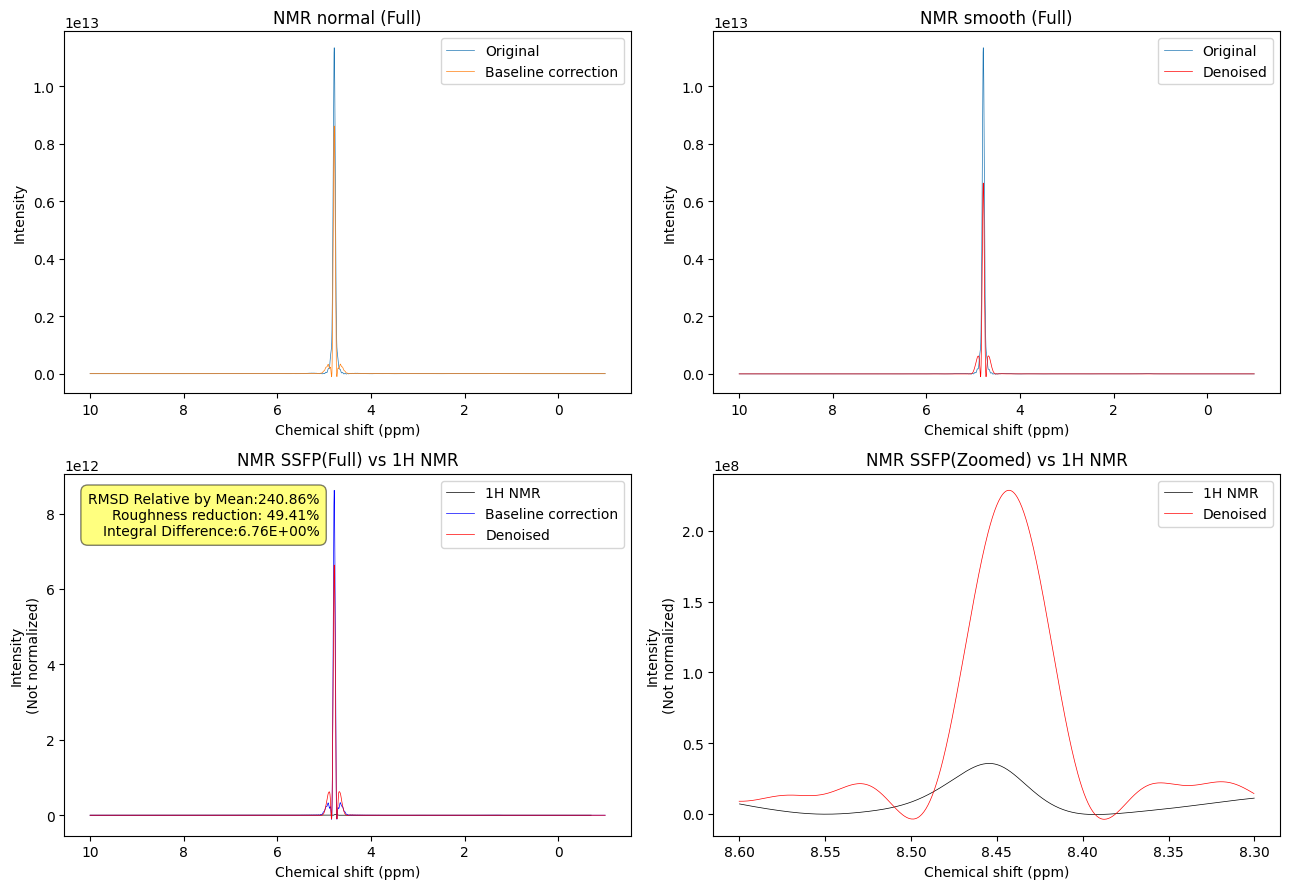



SNR Results
          NMR Manufactured Equation  Mean Equation   RMS Equation  \
Original               8.690723e+04   95125.118777   80336.720280   
Denoised               1.124109e+06  982502.075992  742775.123843   

           Max Equation  
Original   38195.488126  
Denoised  322340.940729  


In [56]:
smooth_function_daphnias('7.Time_7_n_23.csv','7.Time_7_n_23-proton.csv',5,0.06,8.6,8.3,(-0.60,-0.10),141,2,False)

###Time 8 (10h 30min)

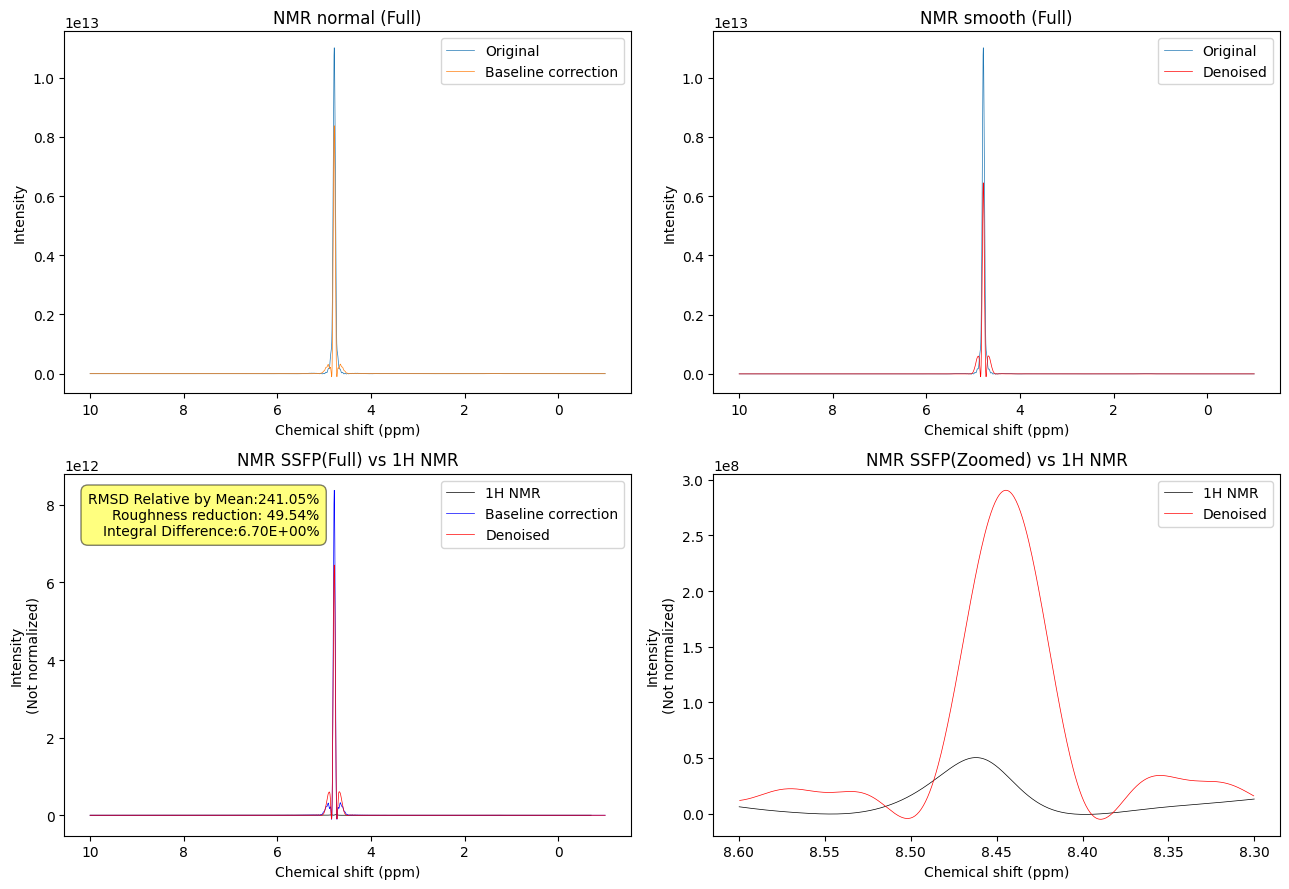



SNR Results
          NMR Manufactured Equation  Mean Equation   RMS Equation  \
Original               8.518653e+04   8.143204e+04   63631.300559   
Denoised               1.204720e+06   1.083773e+06  809430.696032   

           Max Equation  
Original   31057.235427  
Denoised  350466.797537  


In [89]:
smooth_function_daphnias('8.Time_8_n_26.csv','8.Time_8_n_26-proton.csv',5,0.06,8.6,8.3,(-0.60,-0.10),141,2,False)

###Time 9 (12 h)

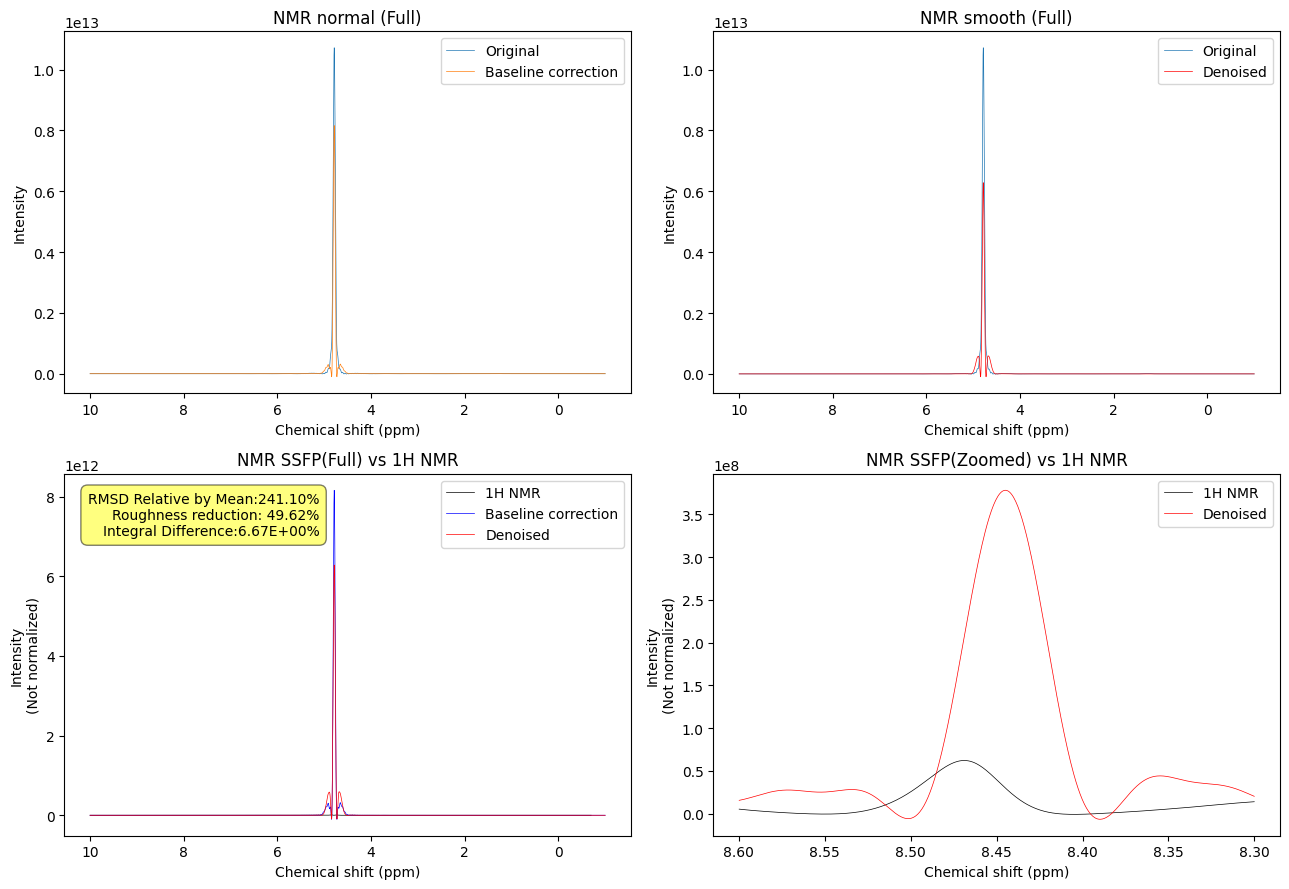



SNR Results
          NMR Manufactured Equation  Mean Equation  RMS Equation  \
Original               8.270150e+04   7.963137e+04  6.479480e+04   
Denoised               2.211254e+06   2.011368e+06  1.496010e+06   

           Max Equation  
Original   31537.185481  
Denoised  532230.288344  


In [58]:
smooth_function_daphnias('9.Time_9_n_29.csv','9.Time_9_n_29-proton.csv',5,0.06,8.6,8.3,(-0.60,-0.10),141,2,False)

###Time 10 (13h 30 min)

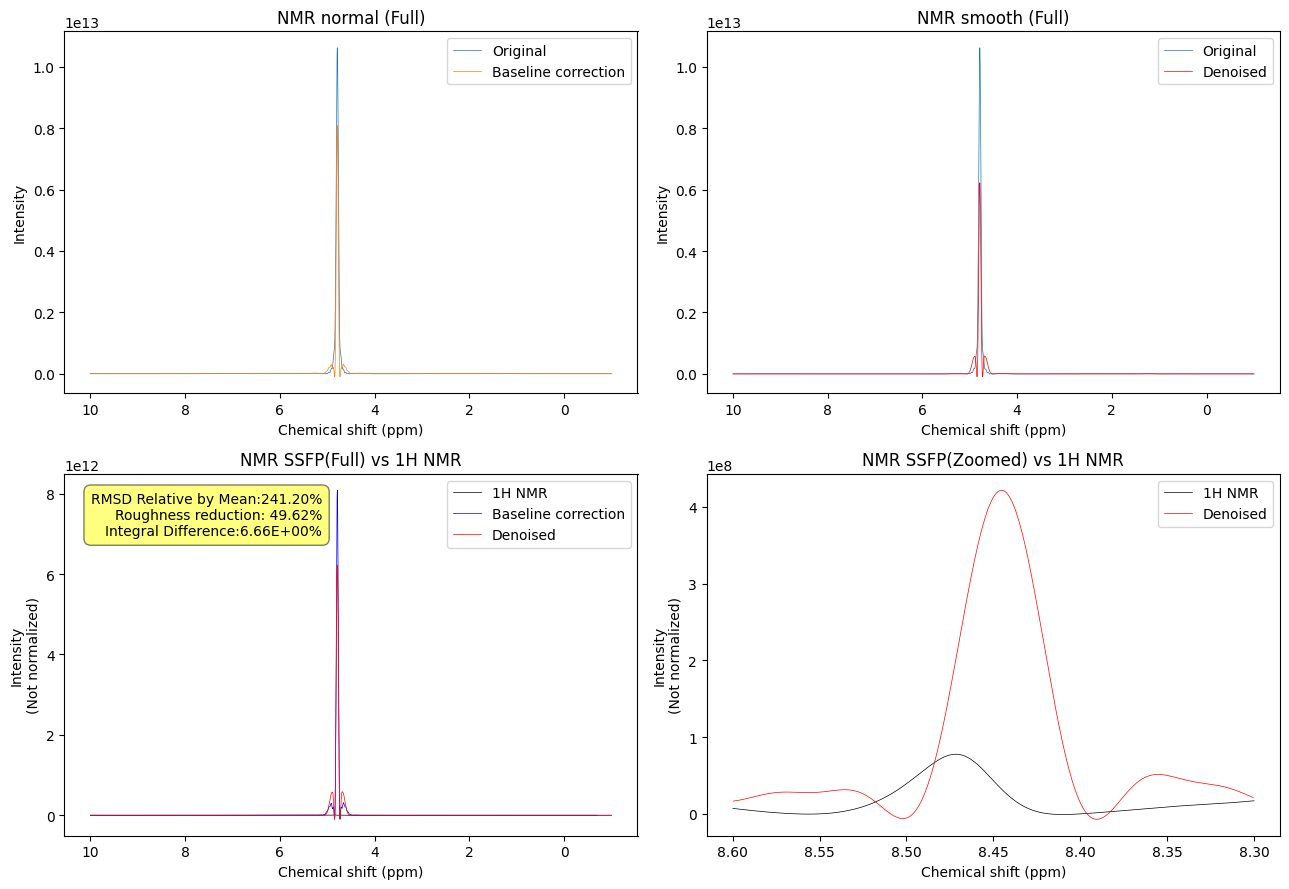



SNR Results
          NMR Manufactured Equation  Mean Equation   RMS Equation  \
Original               8.547488e+04   8.158174e+04   65383.699706   
Denoised               1.340815e+06   1.024502e+06  818509.187150   

           Max Equation  
Original   31174.545611  
Denoised  387345.234179  


In [59]:
smooth_function_daphnias('10.Time_10_n_32.csv','10.Time_10_n_32-proton.csv',5,0.06,8.6,8.3,(-0.60,-0.10),141,2,False)

###Time 11 (15h)

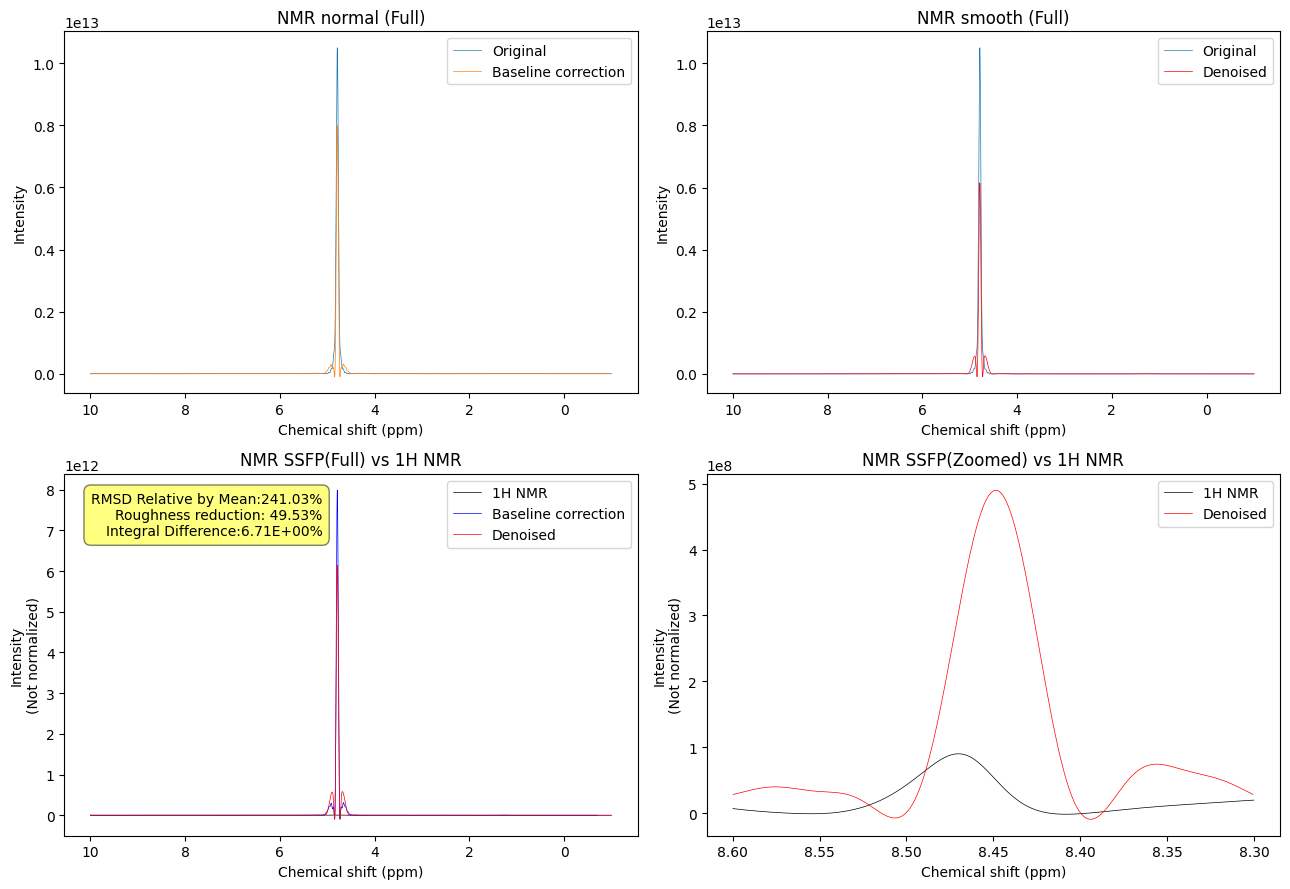



SNR Results
          NMR Manufactured Equation  Mean Equation   RMS Equation  \
Original               1.029793e+05   8.197450e+04   67686.350381   
Denoised               1.261228e+06   1.022298e+06  798788.878845   

           Max Equation  
Original   35326.031366  
Denoised  401125.011905  


In [63]:
smooth_function_daphnias('11.Time_11_n_35.csv','11.Time_11_n_35-proton.csv',5,0.06,8.6,8.3,(-0.60,-0.10),141,2,False)

###Time 12 (16h 30min)

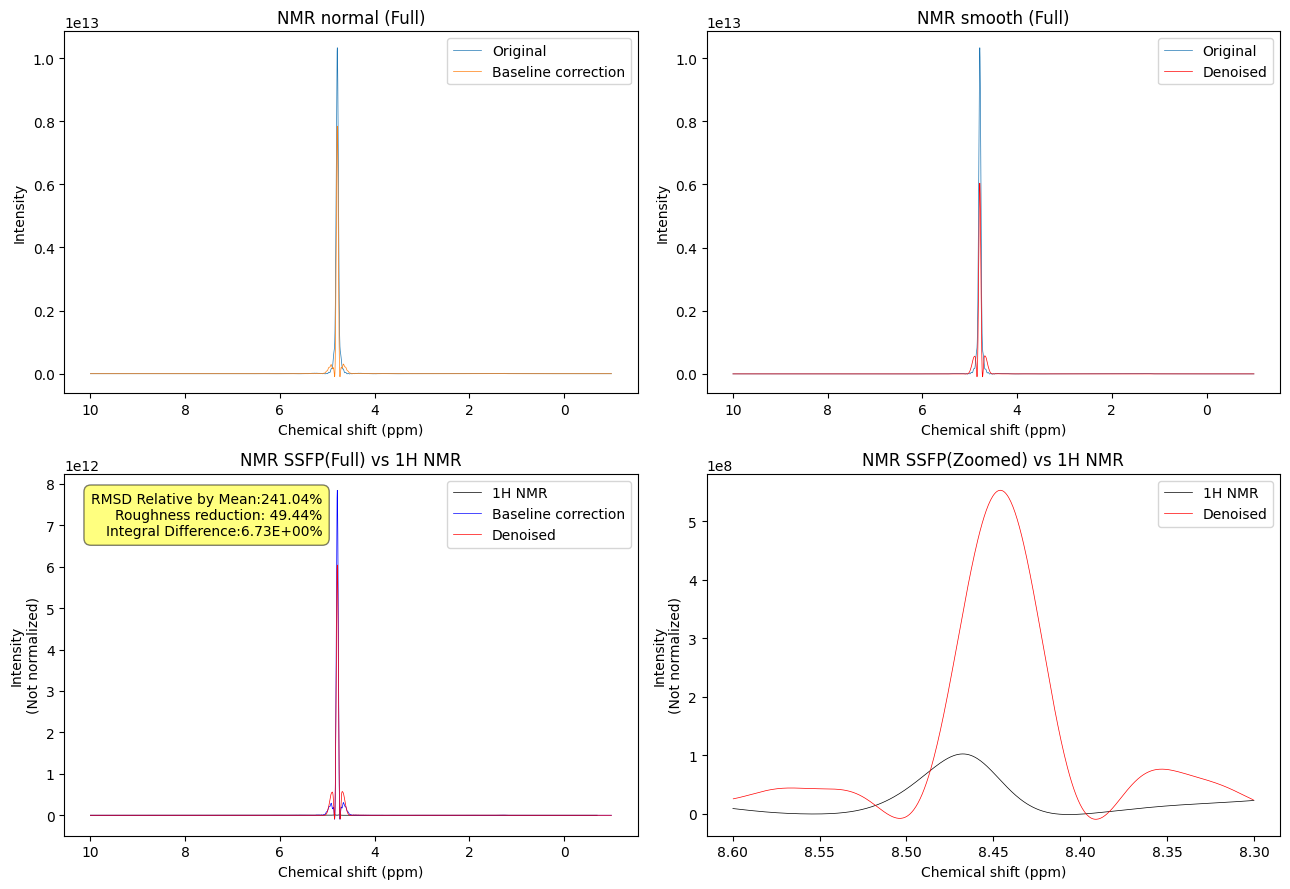



SNR Results
          NMR Manufactured Equation  Mean Equation  RMS Equation  \
Original               8.154205e+04   7.601784e+04  6.019193e+04   
Denoised               1.829179e+06   1.646244e+06  1.229198e+06   

           Max Equation  
Original   29552.313768  
Denoised  521767.970428  


In [62]:
smooth_function_daphnias('12.Time_12_n_38.csv','12.Time_12_n_38-proton.csv',5,0.06,8.6,8.3,(-0.60,-0.10),141,2,False)

###Time 13 (18h)

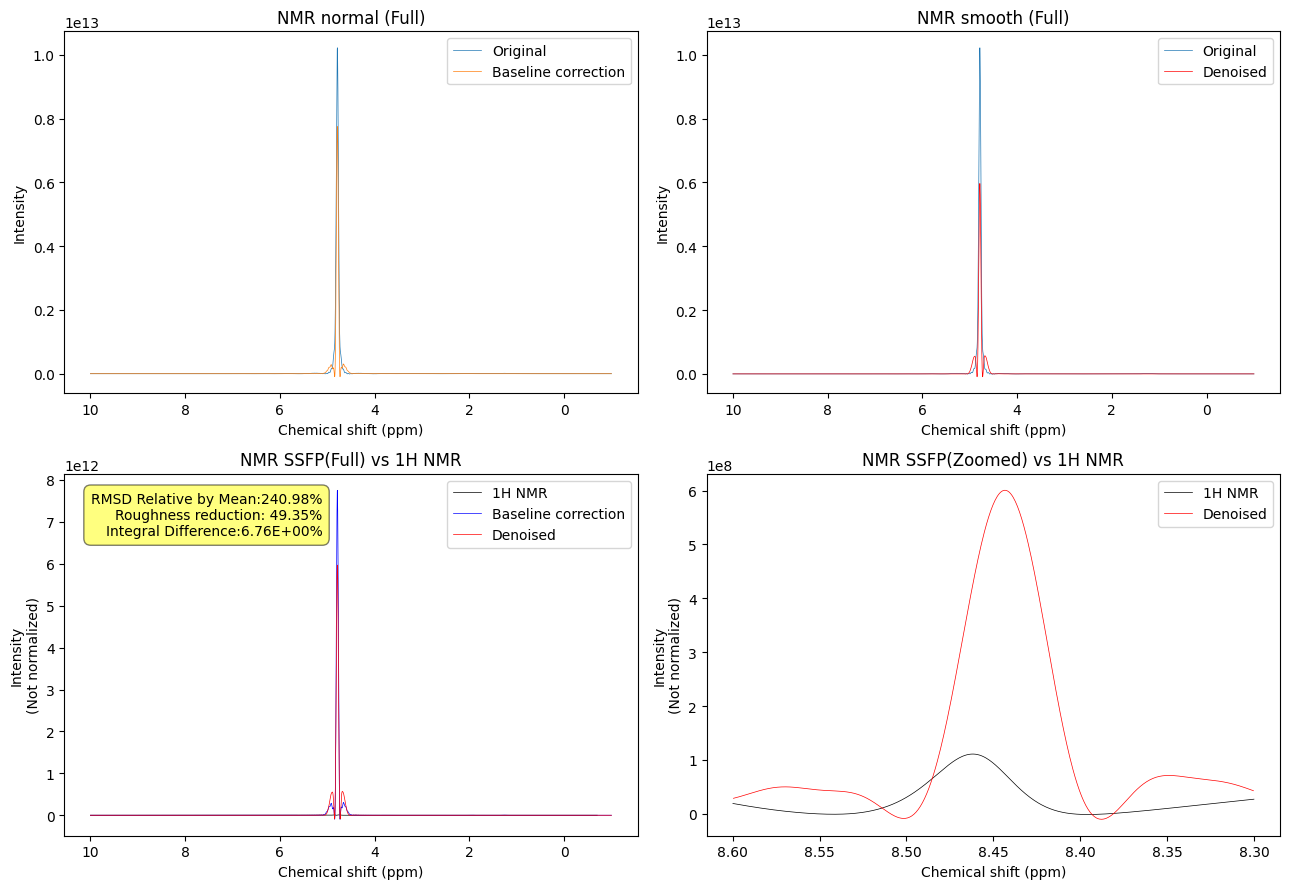



SNR Results
          NMR Manufactured Equation  Mean Equation  RMS Equation  \
Original               8.524829e+04   7.396106e+04  5.968328e+04   
Denoised               1.868606e+06   1.892911e+06  1.335354e+06   

           Max Equation  
Original   29827.737288  
Denoised  427796.133983  


In [65]:
smooth_function_daphnias('13.Time_13_n_41.csv','13.Time_13_n_41-proton.csv',5,0.06,8.6,8.3,(-0.60,-0.10),141,2,False)

###Time 14 (19h 30min)

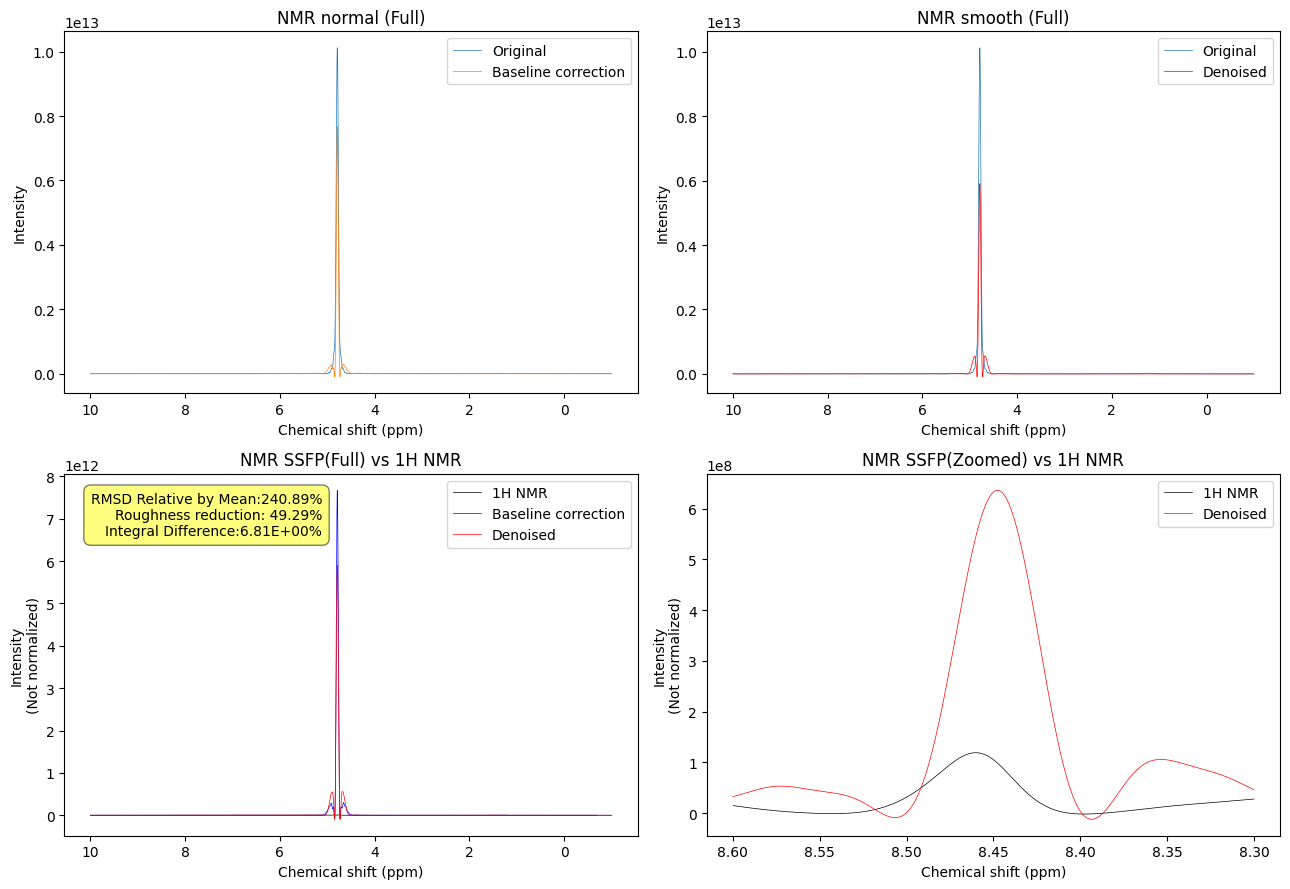



SNR Results
          NMR Manufactured Equation  Mean Equation   RMS Equation  \
Original               1.168291e+05  135668.996772  113822.547138   
Denoised               1.113248e+06  987096.683095  742301.470419   

           Max Equation  
Original   57366.698493  
Denoised  312373.548086  


In [64]:
smooth_function_daphnias('14.Time_14_n_44.csv','14.Time_14_n_44-proton.csv',5,0.06,8.6,8.3,(-0.60,-0.10),141,2,False)

###Time 15 (21 h)

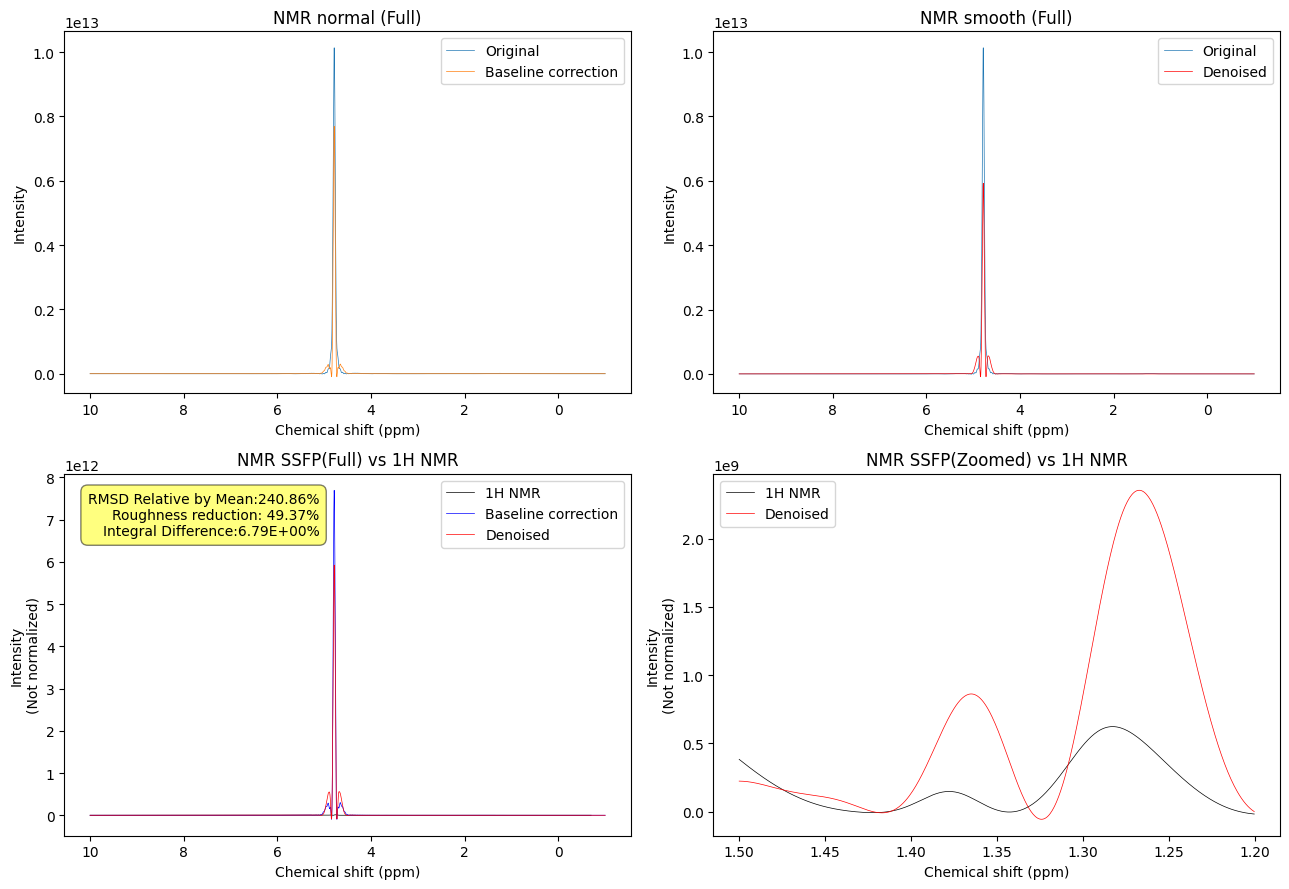



SNR Results
          NMR Manufactured Equation  Mean Equation   RMS Equation  \
Original               1.173005e+05   6.625420e+04   57911.103661   
Denoised               1.105713e+06   1.040136e+06  761093.639781   

           Max Equation  
Original   32945.393551  
Denoised  279482.249079  


In [90]:
smooth_function_daphnias('15.Time_15_n_47.csv','15.Time_15_n_47-proton.csv',5,0.06,1.5,1.2,(-0.60,-0.10),141,2,False)

# Bars Plot for SNR:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from pybaselines import Baseline
from pybaselines.whittaker import arpls

#Setting the path:
path_ssfp='/content/SSFP---Daphnias-Data/Times - SSFP - Daphnias/Times - SSFP'
import os
files_ssfp = [f for f in os.listdir(path_ssfp) if os.path.isfile(os.path.join(path_ssfp, f))]

# Sort files numerically based on the leading number
files_ssfp.sort(key=lambda x: int(x.split('.')[0]))

print(f"\nFiles in '{path_ssfp}':")
display(files_ssfp)


Files in '/content/SSFP---Daphnias-Data/Times - SSFP - Daphnias/Times - SSFP':


['1.Time_1_n6.csv',
 '2.Time_2_n8.csv',
 '3.Time_3_n10.csv',
 '4.Time_4_n_14.csv',
 '5.Time_5_n_17.csv',
 '6.Time_6_n_20.csv',
 '7.Time_7_n_23.csv',
 '8.Time_8_n_26.csv',
 '9.Time_9_n_29.csv',
 '10.Time_10_n_32.csv',
 '11.Time_11_n_35.csv',
 '12.Time_12_n_38.csv',
 '13.Time_13_n_41.csv',
 '14.Time_14_n_44.csv',
 '15.Time_15_n_47.csv']

In [ ]:
# Create an array with the samples time
time_array = np.array([0,1.5,3,4.5,6,7.5,9,10.5,12,13.5,15,16.5,18,19.5,21])

# Convert the array to a pandas DF
df_time = pd.DataFrame(time_array)

df_snr_files=pd.concat([df_time, pd.Series(files_ssfp)], axis=1)
df_snr_files.columns = ['Time (h)','SSFP']
# Display the DataFrame
display(df_snr_files.head())

,Time (h),SSFP
0,0.0,1.Time_1_n6.csv
1,1.5,2.Time_2_n8.csv
2,3.0,3.Time_3_n10.csv
3,4.5,4.Time_4_n_14.csv
4,6.0,5.Time_5_n_17.csv


In [ ]:
#Recalling the functions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from pybaselines import Baseline
from pybaselines.whittaker import arpls

def calculate_nmr_manufactured_noise(noise_data):

    N = len(noise_data)

    if N == 0:
        return 0.0 # No noise data, so assume 0 noise

    # If N is 1 or 2, std dev can be calculated (for N=1, std is 0). Bruker formula does not apply.
    if N < 3 or N % 2 == 0:
        # NMR Manufactured Equation formula requires N >= 3 and odd. Fallback to standard deviation.
        return np.std(noise_data)

    # Now N is guaranteed to be >= 3 and odd for the Bruker formula
    n = (N - 1) // 2

    # Term 1: Sum from i=-n to n of y(i)^2
    sum_i_sq = np.sum(noise_data**2)

    # Term 2: Sum from i=-n to n of y(i)
    sum_i = np.sum(noise_data)

    # Term 3: Sum from i=1 to n of i * (y(i) - y(-i))^2
    i_indices = np.arange(1, n + 1)

    # Mapping symmetric indices to array indices: y(i) -> n+i, y(-i) -> n-i
    y_i = noise_data[n + i_indices]
    y_neg_i = noise_data[n - i_indices]

    diff_term_sum = np.sum(i_indices * (y_i - y_neg_i)**2)

    # Assemble the numerator and denominator
    numerator = sum_i_sq - (1/N) * (sum_i**2 + (3*(diff_term_sum)**2) / (N**2 - 1))
    denominator = N - 1

    if numerator < 0:
        # This can happen due to noise characteristics; use the standard deviation as a fallback
        return np.std(noise_data)
    else:
        # Denominator should not be 0 here as N >= 3, so N-1 >= 2
        return np.sqrt(numerator / denominator)

def calculate_noise_mean(noise_data):
  return np.mean(np.abs(noise_data))

def calculate_noise_rms(noise_data):
  return np.sqrt(np.mean(noise_data**2))

def calculate_noise_max(noise_data):
  norma_max=np.linalg.norm(noise_data,ord=np.inf)
  return norma_max

def snr_function_daphnias(ssfp_file,exponent_lambda,peso,noise_range,width_length,polyorder):
    path_ssfp='/content/SSFP---Daphnias-Data/Times - SSFP - Daphnias/Times - SSFP'
    input_filename=f'{path_ssfp}/{ssfp_file}'
    data = np.genfromtxt(input_filename, delimiter=',',
                        skip_footer=1, skip_header=1)

    intensity_irregular_in = data[:, 0]
    chemical_shift_in = data[:, 2]

    # Apply initial general Daphnias range filtering to SSFP data
    mask_ssfp_daphnias = (chemical_shift_in <= 10) & (chemical_shift_in >= -1)
    # print(f"DEBUG: Length of mask_ssfp_daphnias: {len(mask_ssfp_daphnias)}") # Debug print
    data_daphnias = data[mask_ssfp_daphnias]

    # Derive initial intensity and chemical shift from the filtered SSFP data
    intensity_irregular = data_daphnias[:, 0]
    chemical_shift = data_daphnias[:, 2]

    # Existing data processing steps
    lambda_coef=10**exponent_lambda
    fitter= Baseline(x_data=chemical_shift)
    baseline, params=fitter.iasls(intensity_irregular,lam=lambda_coef,p=peso)
    intensity= intensity_irregular-baseline
    smoothed_intensity_prev = savgol_filter(intensity, width_length,polyorder)
    baseline2, params2=fitter.iasls(smoothed_intensity_prev,lam=lambda_coef,p=peso)
    smoothed_intensity = smoothed_intensity_prev-baseline2

    # SNR Calculation for comparison
    cs_noise_min, cs_noise_max = noise_range
    noise_mask = (chemical_shift >= cs_noise_min) & (chemical_shift <= cs_noise_max)

    # 1. SNR - Original - Manufactured
    noise_data_raw = intensity_irregular[noise_mask]
    signal_raw = np.max(np.abs(intensity_irregular)) # Signal from full raw spectrum

    noise_estimate_raw = calculate_nmr_manufactured_noise(noise_data_raw)
    snr_raw = signal_raw/(2*noise_estimate_raw)

    # 2. SNR - After Denoising
    noise_data_smoothed = smoothed_intensity[noise_mask]
    signal_smoothed = np.max(np.abs(smoothed_intensity)) # Signal from full smoothed spectrum

    noise_estimate_smoothed = calculate_nmr_manufactured_noise(noise_data_smoothed)
    snr_smoothed = signal_smoothed/(noise_estimate_smoothed*2)

    #3. SNR - Original - Mean
    noise_data_mean = intensity_irregular[noise_mask]
    snr_mean_raw = (signal_raw)/(calculate_noise_mean(noise_data_mean)*2)

    #5 SNR - After denoising Mean
    noise_data_mean_corrected = smoothed_intensity[noise_mask]
    snr_mean_corrected = (signal_smoothed)/(calculate_noise_mean(noise_data_mean_corrected)*2)

    #6. SNR - Original -  RMS
    noise_data_rms = intensity_irregular[noise_mask]
    snr_rms_raw = (signal_raw)/(calculate_noise_rms(noise_data_rms)*2)

    #7 SNR - After Denoising Mean
    noise_data_rms_corrected = smoothed_intensity[noise_mask]
    snr_rms_corrected = (signal_smoothed)/(calculate_noise_rms(noise_data_rms_corrected)*2)

    #8. SNR - Original -  Max
    noise_data_max = intensity_irregular[noise_mask]
    snr_max_raw = (signal_raw)/(calculate_noise_max(noise_data_max)*2)

    #9 SNR - After Denoising Max
    noise_data_max_corrected = smoothed_intensity[noise_mask]
    snr_max_corrected = (signal_smoothed)/(calculate_noise_max(noise_data_max_corrected)*2)

    #10 Table of SNR:
    data_snr=np.array([
       snr_raw,snr_smoothed,snr_mean_raw,snr_mean_corrected,snr_rms_raw,snr_rms_corrected,snr_max_raw,snr_max_corrected
      ])

    return data_snr


In [ ]:
#SNR variable:
snr_values=[]

# Define column names for the df_snr_values DataFrame
snr_column_names = [
    'NMR Manufactured Eq (Raw)', 'NMR Manufactured Eq (Smoothed)',
    'Mean Eq (Raw)', 'Mean Eq (Smoothed)',
    'RMS Eq (Raw)', 'RMS Eq (Smoothed)',
    'Max Eq (Raw)', 'Max Eq (Smoothed)'
]

# Iterate through the DataFrame rows
for index, row in df_snr_files.iterrows():
    snr_array = snr_function_daphnias(
        row['SSFP'],
        5,
        0.06,
        (-0.60,-0.10), #Noise region that matches with the width of the biggest signal (0.5 ppm=)
        141,
        2,
    )
    snr_values.append(snr_array)

# Create the DataFrame from the collected SNR values, with one row per time point
df_snr_values = pd.DataFrame(snr_values, columns=snr_column_names)

# Concatenate the time information with the calculated SNR values
df_snr_files_final = pd.concat([df_snr_files, df_snr_values], axis=1)

# Display the resulting DataFrame
display(df_snr_files_final)

,Time (h),SSFP,NMR Manufactured Eq (Raw),NMR Manufactured Eq (Smoothed),Mean Eq (Raw),Mean Eq (Smoothed),RMS Eq (Raw),RMS Eq (Smoothed),Max Eq (Raw),Max Eq (Smoothed)
0,0.0,1.Time_1_n6.csv,83803.341440,1.178354e+06,94093.163203,9.392868e+05,80515.852753,7.383885e+05,38892.977881,355283.162070
1,1.5,2.Time_2_n8.csv,83950.822134,1.063264e+06,90913.071094,9.678018e+05,74761.927928,7.188176e+05,35347.276639,262568.362295
2,3.0,3.Time_3_n10.csv,85732.259859,2.187295e+06,97199.582823,1.646817e+06,83267.482208,1.322786e+06,40151.974466,571658.681212
3,4.5,4.Time_4_n_14.csv,86771.278972,1.824241e+06,94165.759712,1.438620e+06,77763.275687,1.133661e+06,35560.307069,498253.294390
4,6.0,5.Time_5_n_17.csv,67332.939527,1.436045e+06,42776.202093,1.355100e+06,36106.119127,9.891805e+05,15145.728535,371509.481995
5,7.5,6.Time_6_n_20.csv,85094.438106,2.079168e+06,95576.171834,1.724582e+06,82232.446554,1.334261e+06,37815.218873,561614.062677
6,9.0,7.Time_7_n_23.csv,86907.233855,1.124109e+06,95125.118777,9.825021e+05,80336.720280,7.427751e+05,38195.488126,322340.940729
7,10.5,8.Time_8_n_26.csv,85186.531861,1.204720e+06,81432.035225,1.083773e+06,63631.300559,8.094307e+05,31057.235427,350466.797537
8,12.0,9.Time_9_n_29.csv,82701.504997,2.211254e+06,79631.365504,2.011368e+06,64794.798879,1.496010e+06,31537.185481,532230.288344
9,13.5,10.Time_10_n_32.csv,85474.875669,1.340815e+06,81581.739539,1.024502e+06,65383.699706,8.185092e+05,31174.545611,387345.234179


##Bar Plotting for all the Spectra

###SNR Manufactured Equation

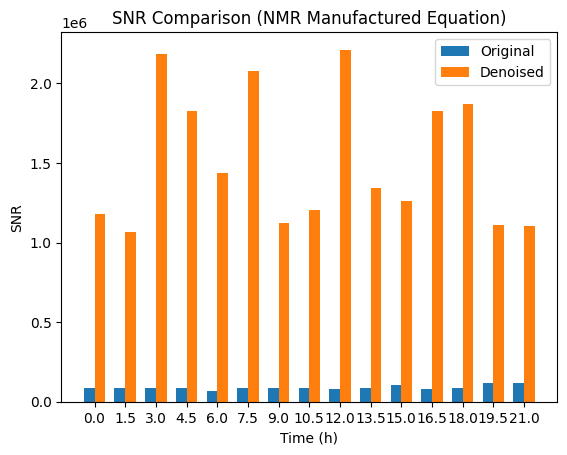

In [ ]:
#Plotting SNR Manufactured Equation
bar_width = 0.35
r = np.arange(len(df_snr_files_final['Time (h)']))

plt.bar(r - (bar_width/2), df_snr_files_final['NMR Manufactured Eq (Raw)'], width=bar_width, label='Original')
plt.bar(r + (bar_width/2), df_snr_files_final['NMR Manufactured Eq (Smoothed)'], width=bar_width, label='Denoised')

plt.title('SNR Comparison (NMR Manufactured Equation)')
plt.xlabel('Time (h)')
plt.ylabel('SNR')
plt.xticks(r, df_snr_files_final['Time (h)'])
plt.legend()
plt.show()

###SNR Mean

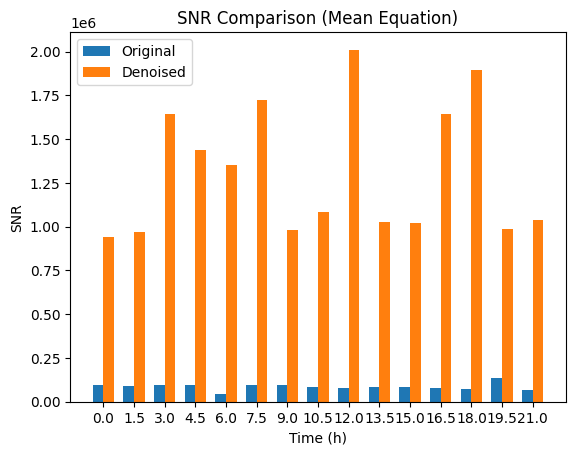

In [ ]:
#Plotting SNR Mean
bar_width = 0.35
r = np.arange(len(df_snr_files_final['Time (h)']))

plt.bar(r - (bar_width/2), df_snr_files_final['Mean Eq (Raw)'], width=bar_width, label='Original')
plt.bar(r + (bar_width/2), df_snr_files_final['Mean Eq (Smoothed)'], width=bar_width, label='Denoised')

plt.title('SNR Comparison (Mean Equation)')
plt.xlabel('Time (h)')
plt.ylabel('SNR')
plt.xticks(r, df_snr_files_final['Time (h)'])
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.legend()
plt.show()

###SNR RMS

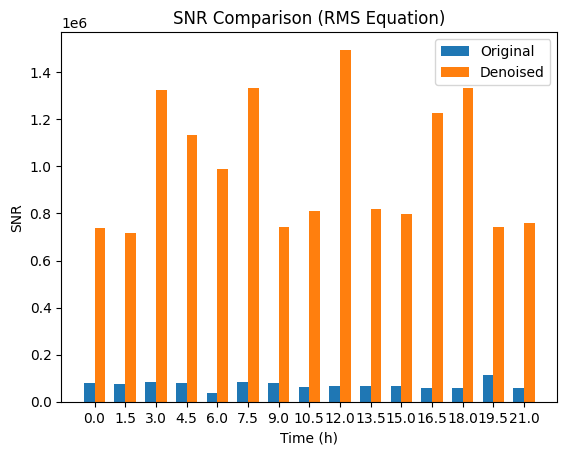

In [ ]:
bar_width = 0.35
r = np.arange(len(df_snr_files_final['Time (h)']))

plt.bar(r - (bar_width/2), df_snr_files_final['RMS Eq (Raw)'], width=bar_width, label='Original')
plt.bar(r + (bar_width/2), df_snr_files_final['RMS Eq (Smoothed)'], width=bar_width, label='Denoised')
plt.title('SNR Comparison (RMS Equation)')
plt.xlabel('Time (h)')
plt.ylabel('SNR')
plt.xticks(r, df_snr_files_final['Time (h)'])
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.legend()
plt.show()

###SNR Max

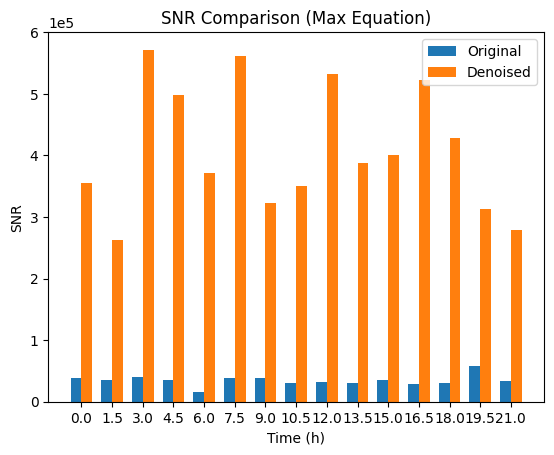

In [ ]:
bar_width = 0.35
r = np.arange(len(df_snr_files_final['Time (h)']))

plt.bar(r - (bar_width/2), df_snr_files_final['Max Eq (Raw)'], width=bar_width, label='Original')
plt.bar(r + (bar_width/2), df_snr_files_final['Max Eq (Smoothed)'], width=bar_width, label='Denoised')

plt.title('SNR Comparison (Max Equation)')
plt.xlabel('Time (h)')
plt.ylabel('SNR')
plt.xticks(r, df_snr_files_final['Time (h)'])
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.legend()
plt.show()

## Bar Plotting for each Metabolite

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from pybaselines import Baseline
from pybaselines.whittaker import arpls

#Setting the path:
path_ssfp='/content/SSFP---Daphnias-Data/Times - SSFP - Daphnias/Times - SSFP'
import os
files_ssfp = [f for f in os.listdir(path_ssfp) if os.path.isfile(os.path.join(path_ssfp, f))]

# Sort files numerically based on the leading number
files_ssfp.sort(key=lambda x: int(x.split('.')[0]))

# Create an array with the samples time
time_array = np.array([0,1.5,3,4.5,6,7.5,9,10.5,12,13.5,15,16.5,18,19.5,21])

# Convert the array to a pandas DF
df_time = pd.DataFrame(time_array)

df_snr_files=pd.concat([df_time, pd.Series(files_ssfp)], axis=1)
df_snr_files.columns = ['Time (h)','SSFP']

#Recalling the function:

def calculate_nmr_manufactured_noise(noise_data):

    N = len(noise_data)

    if N == 0:
        return 0.0 # No noise data, so assume 0 noise

    # If N is 1 or 2, std dev can be calculated (for N=1, std is 0). Bruker formula does not apply.
    if N < 3 or N % 2 == 0:
        # NMR Manufactured Equation formula requires N >= 3 and odd. Fallback to standard deviation.
        return np.std(noise_data)

    # Now N is guaranteed to be >= 3 and odd for the Bruker formula
    n = (N - 1) // 2

    # Term 1: Sum from i=-n to n of y(i)^2
    sum_i_sq = np.sum(noise_data**2)

    # Term 2: Sum from i=-n to n of y(i)
    sum_i = np.sum(noise_data)

    # Term 3: Sum from i=1 to n of i * (y(i) - y(-i))^2
    i_indices = np.arange(1, n + 1)

    # Mapping symmetric indices to array indices: y(i) -> n+i, y(-i) -> n-i
    y_i = noise_data[n + i_indices]
    y_neg_i = noise_data[n - i_indices]

    diff_term_sum = np.sum(i_indices * (y_i - y_neg_i)**2)

    # Assemble the numerator and denominator
    numerator = sum_i_sq - (1/N) * (sum_i**2 + (3*(diff_term_sum)**2) / (N**2 - 1))
    denominator = N - 1

    if numerator < 0:
        # This can happen due to noise characteristics; use the standard deviation as a fallback
        return np.std(noise_data)
    else:
        # Denominator should not be 0 here as N >= 3, so N-1 >= 2
        return np.sqrt(numerator / denominator)

def calculate_noise_mean(noise_data):
  return np.mean(np.abs(noise_data))

def calculate_noise_rms(noise_data):
  return np.sqrt(np.mean(noise_data**2))

def calculate_noise_max(noise_data):
  norma_max=np.linalg.norm(noise_data,ord=np.inf)
  return norma_max

def snr_local_daphnias(ssfp_file,exponent_lambda,peso,upper_limit,lower_limit,noise_range,width_length,polyorder):
    path_ssfp='/content/SSFP---Daphnias-Data/Times - SSFP - Daphnias/Times - SSFP'
    input_filename=f'{path_ssfp}/{ssfp_file}'
    data = np.genfromtxt(input_filename, delimiter=',',
                        skip_footer=1, skip_header=1)

    intensity_irregular_in = data[:, 0]
    chemical_shift_in = data[:, 2]

    # Apply initial general Daphnias range filtering to SSFP data
    mask_ssfp_daphnias = (chemical_shift_in <= 10) & (chemical_shift_in >= -1)
    # print(f"DEBUG: Length of mask_ssfp_daphnias: {len(mask_ssfp_daphnias)}") # Debug print
    data_daphnias = data[mask_ssfp_daphnias]

    # Derive initial intensity and chemical shift from the filtered SSFP data
    intensity_irregular = data_daphnias[:, 0]
    chemical_shift = data_daphnias[:, 2]

    # Existing data processing steps
    lambda_coef=10**exponent_lambda
    fitter= Baseline(x_data=chemical_shift)
    baseline, params=fitter.iasls(intensity_irregular,lam=lambda_coef,p=peso)
    intensity= intensity_irregular-baseline
    smoothed_intensity_prev = savgol_filter(intensity, width_length,polyorder)
    baseline2, params2=fitter.iasls(smoothed_intensity_prev,lam=lambda_coef,p=peso)
    smoothed_intensity = smoothed_intensity_prev-baseline2

    #Corrected data:
    data_corrected=pd.DataFrame({'Chemical Shift': chemical_shift, 'Intensity': smoothed_intensity})

    #Local Maximums (for a specific signal):
     # Corrected data:
    mask_max = (chemical_shift <= upper_limit) & (chemical_shift >= lower_limit)
    data_extracted=data_corrected[mask_max]
    intensity_smooth_extracted = data_extracted['Intensity'].values
    chemical_shift_extracted = data_extracted['Chemical Shift'].values
    max_intensity_smoothed=np.max(np.abs(intensity_smooth_extracted))

     #Raw data:
    data_local_raw=data_daphnias[mask_max]
    intensity_raw_extracted = data_local_raw[:, 0]
    chemical_shift_raw_extracted = data_local_raw[:, 2]
    max_intensity_raw=np.max(np.abs(intensity_raw_extracted))


    # SNR Calculation for comparison
    cs_noise_min, cs_noise_max = noise_range
    noise_mask = (chemical_shift >= cs_noise_min) & (chemical_shift <= cs_noise_max)

#====================================
# NMR Manufactured equation
#====================================

    # SNR - Original (Raw Data)
    noise_data_raw = intensity_irregular[noise_mask]
    signal_raw = max_intensity_raw # Signal from selected local region

    noise_estimate_raw = calculate_nmr_manufactured_noise(noise_data_raw)
    snr_raw = signal_raw/(2*noise_estimate_raw)

    # SNR - After Denoising
    noise_data_smoothed = smoothed_intensity[noise_mask]
    signal_smoothed = max_intensity_smoothed # Signal from full smoothed spectrum

    noise_estimate_smoothed = calculate_nmr_manufactured_noise(noise_data_smoothed)
    snr_smoothed = signal_smoothed/(2*noise_estimate_smoothed)

#=================================
# Mean Equation:
#=================================

    #SNR - Original (Raw Data)
    noise_data_mean = intensity_irregular[noise_mask]
    snr_mean_raw = (signal_raw)/(calculate_noise_mean(noise_data_mean)*2)

    #SNR - After Denoising
    noise_data_mean_corrected = smoothed_intensity[noise_mask]
    snr_mean_corrected = (signal_smoothed)/(calculate_noise_mean(noise_data_mean_corrected)*2)

#=================================
#RMS equation
#=================================

    #SNR - Original (Raw Data)
    noise_data_rms = intensity_irregular[noise_mask]
    snr_rms_raw = (signal_raw)/(calculate_noise_rms(noise_data_rms)*2)

    #SNR - After Denoising
    noise_data_rms_corrected = smoothed_intensity[noise_mask]
    snr_rms_corrected = (signal_smoothed)/(calculate_noise_rms(noise_data_rms_corrected)*2)

#==================================
# Max Equation
#==================================

    #8. SNR - Original (Raw Data)
    noise_data_max = intensity_irregular[noise_mask]
    snr_max_raw = (signal_raw)/(calculate_noise_max(noise_data_max)*2)

    #9 SNR - After Denoising
    noise_data_max_corrected = smoothed_intensity[noise_mask]
    snr_max_corrected = (signal_smoothed)/(calculate_noise_max(noise_data_max_corrected)*2)

#Compiling data
    data_snr=np.array([
       snr_raw,snr_smoothed,snr_mean_raw,snr_mean_corrected,snr_rms_raw,snr_rms_corrected,snr_max_raw,snr_max_corrected
      ])

    return data_snr

def snr_data_calculation(exponent_lambda,peso,upper_limit,lower_limit,noise_range,width_length,polyorder):

 #SNR variable:
 snr_values=[]

 # Define column names for the df_snr_values DataFrame
 snr_column_names = [
    'NMR Manufactured Eq (Raw)', 'NMR Manufactured Eq (Smoothed)',
    'Mean Eq (Raw)', 'Mean Eq (Smoothed)',
    'RMS Eq (Raw)', 'RMS Eq (Smoothed)',
    'Max Eq (Raw)', 'Max Eq (Smoothed)'
]

 # Iterate through the DataFrame rows
 for index, row in df_snr_files.iterrows():
     snr_array = snr_local_daphnias(row['SSFP'],exponent_lambda,peso,upper_limit,lower_limit,noise_range,width_length,polyorder)
     snr_values.append(snr_array)

 # Create the DataFrame from the collected SNR values, with one row per time point
 df_snr_values = pd.DataFrame(snr_values, columns=snr_column_names)

 # Concatenate the time information with the calculated SNR values
 df_snr_files_final = pd.concat([df_snr_files, df_snr_values], axis=1)

 return df_snr_files_final


### Formic acid

#### SNR Manufactured Equation

,Time (h),SSFP,NMR Manufactured Eq (Raw),NMR Manufactured Eq (Smoothed),Mean Eq (Raw),Mean Eq (Smoothed),RMS Eq (Raw),RMS Eq (Smoothed),Max Eq (Raw),Max Eq (Smoothed)
0,0.0,1.Time_1_n6.csv,3.588977,1.352113,3.768352,1.049449,3.252041,0.833262,1.701361,0.446745
1,1.5,2.Time_2_n8.csv,2.157198,1.344800,2.672390,1.218108,2.154209,0.906371,0.867563,0.391549
2,3.0,3.Time_3_n10.csv,3.428309,3.213875,3.544832,2.324469,3.053389,1.892904,1.620651,0.882963
3,4.5,4.Time_4_n_14.csv,2.605419,7.449553,3.169636,6.646738,2.584342,4.982649,1.056683,2.061139
4,6.0,5.Time_5_n_17.csv,3.637296,11.138397,1.683237,11.356945,1.527593,7.988395,0.653576,2.912362
5,7.5,6.Time_6_n_20.csv,5.093103,42.037666,5.271788,36.768610,4.492661,27.789626,2.431971,11.472798


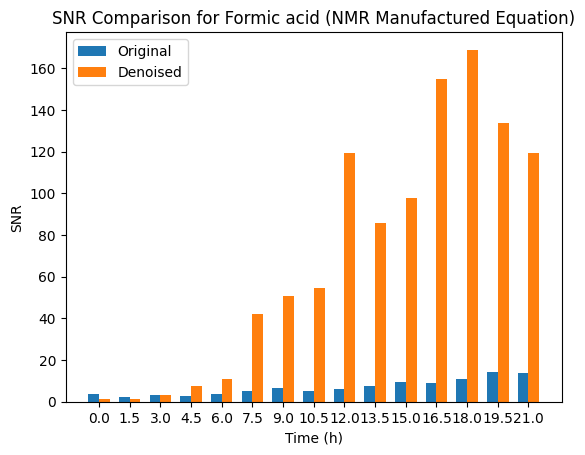

In [14]:
df_formic_acid_snr=snr_data_calculation(5,0.06,8.6,8.3,(-0.50,-0.20),141,2)
time_array=np.array(df_formic_acid_snr['Time (h)'])
snr_manu_raw=np.array(df_formic_acid_snr['NMR Manufactured Eq (Raw)'])
snr_manu_smoothed=np.array(df_formic_acid_snr['NMR Manufactured Eq (Smoothed)'])
print('SNR values for formic acid')
display(df_formic_acid_snr.head(6))
print("\n")

bar_width=0.35
r=np.arange(len(time_array))
plt.bar(r-(bar_width/2),snr_manu_raw,width=bar_width,label='Original')
plt.bar(r+(bar_width/2),snr_manu_smoothed,width=bar_width,label='Denoised')
plt.title('SNR Comparison for Formic acid (NMR Manufactured Equation)')
plt.xlabel('Time (h)')
plt.ylabel('SNR')
plt.xticks(r,time_array)
plt.legend()
plt.show()

#### SNR Mean

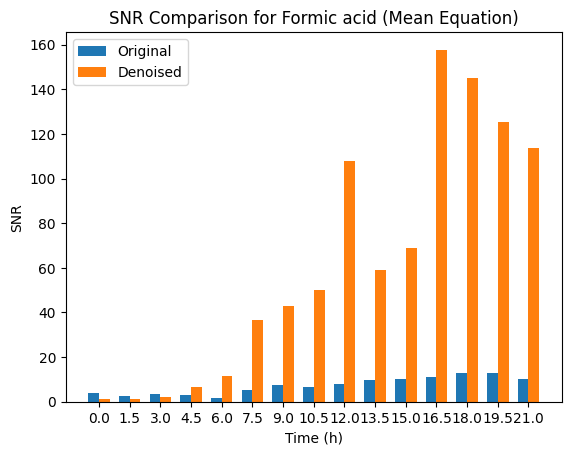

In [ ]:
df_formic_acid_snr=snr_data_calculation(5,0.06,8.6,8.3,(-0.50,-0.20),141,2)
time_array=np.array(df_formic_acid_snr['Time (h)'])
snr_mean_raw=np.array(df_formic_acid_snr['Mean Eq (Raw)'])
snr_mean_smoothed=np.array(df_formic_acid_snr['Mean Eq (Smoothed)'])

bar_width=0.35
r=np.arange(len(time_array))
plt.bar(r-(bar_width/2),snr_mean_raw,width=bar_width,label='Original')
plt.bar(r+(bar_width/2),snr_mean_smoothed,width=bar_width,label='Denoised')
plt.title('SNR Comparison for Formic acid (Mean Equation)')
plt.xlabel('Time (h)')
plt.ylabel('SNR')
plt.legend()
plt.xticks(r,time_array)
plt.show()

#### SNR RMS

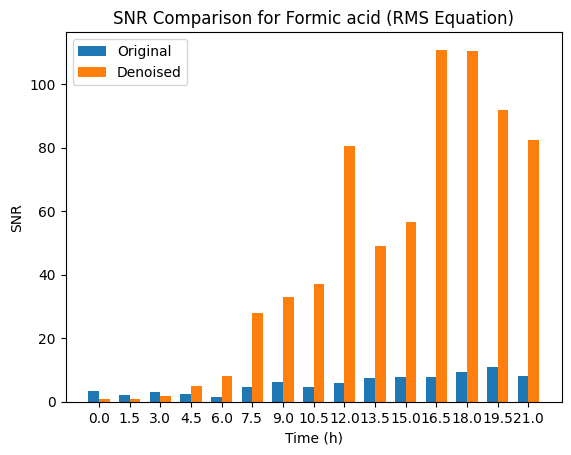

In [ ]:
df_formic_acid_snr=snr_data_calculation(5,0.06,8.6,8.3,(-0.50,-0.20),141,2)
time_array=np.array(df_formic_acid_snr['Time (h)'])
snr_rms_raw=np.array(df_formic_acid_snr['RMS Eq (Raw)'])
snr_rms_smoothed=np.array(df_formic_acid_snr['RMS Eq (Smoothed)'])

bar_width=0.35
r=np.arange(len(time_array))
plt.bar(r-(bar_width/2),snr_rms_raw,width=bar_width,label='Original')
plt.bar(r+(bar_width/2),snr_rms_smoothed,width=bar_width,label='Denoised')
plt.title('SNR Comparison for Formic acid (RMS Equation)')
plt.xlabel('Time (h)')
plt.ylabel('SNR')
plt.legend()
plt.xticks(r,time_array)
plt.show()

#### SNR Max

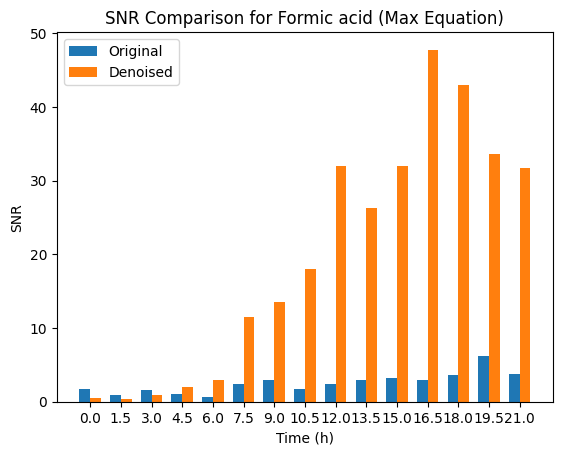

In [ ]:
df_formic_acid_snr=snr_data_calculation(5,0.06,8.6,8.3,(-0.50,-0.20),141,2)
time_array=np.array(df_formic_acid_snr['Time (h)'])
snr_max_raw=np.array(df_formic_acid_snr['Max Eq (Raw)'])
snr_max_smoothed=np.array(df_formic_acid_snr['Max Eq (Smoothed)'])

bar_width=0.35
r=np.arange(len(time_array))
plt.bar(r-(bar_width/2),snr_max_raw,width=bar_width,label='Original')
plt.bar(r+(bar_width/2),snr_max_smoothed,width=bar_width,label='Denoised')
plt.title('SNR Comparison for Formic acid (Max Equation)')
plt.xlabel('Time (h)')
plt.ylabel('SNR')
plt.legend()
plt.xticks(r,time_array)
plt.show()

### Lactic Acid

#### SNR Manufactured Equation

SNR values for lactic acid


,Time (h),SSFP,NMR Manufactured Eq (Raw),NMR Manufactured Eq (Smoothed),Mean Eq (Raw),Mean Eq (Smoothed),RMS Eq (Raw),RMS Eq (Smoothed),Max Eq (Raw),Max Eq (Smoothed)
0,0.0,1.Time_1_n6.csv,70.417298,174.280401,73.936710,135.268604,63.806467,107.403195,33.381452,57.583097
1,1.5,2.Time_2_n8.csv,62.665078,151.552559,77.631041,137.275051,62.578259,102.143748,25.202096,44.125708
2,3.0,3.Time_3_n10.csv,75.079008,378.903060,77.630823,274.045600,66.868366,223.165882,35.491796,104.097770
3,4.5,4.Time_4_n_14.csv,88.401166,378.389292,107.544866,337.611447,87.686004,253.086448,35.852970,104.692605
4,6.0,5.Time_5_n_17.csv,97.605095,298.425156,45.168852,304.280597,40.992230,214.028836,17.538394,78.029371
5,7.5,6.Time_6_n_20.csv,111.617856,501.603859,115.533827,438.732175,98.458868,331.592708,53.297828,136.896271


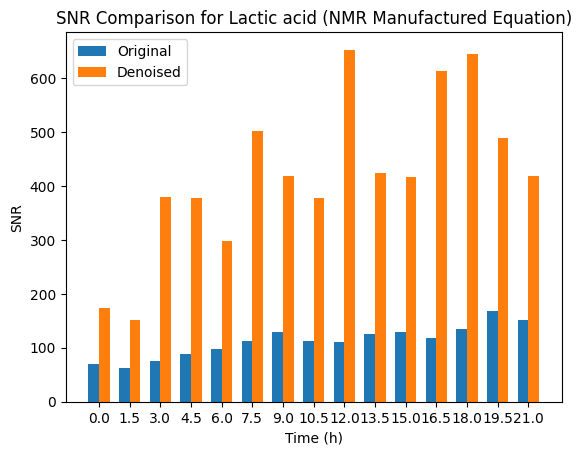

In [15]:
df_lactic_acid_snr=snr_data_calculation(5,0.06,1.5,1.2,(-0.50,-0.20),141,2)
time_array=np.array(df_lactic_acid_snr['Time (h)'])
snr_manu_raw=np.array(df_lactic_acid_snr['NMR Manufactured Eq (Raw)'])
snr_manu_smoothed=np.array(df_lactic_acid_snr['NMR Manufactured Eq (Smoothed)'])
print('SNR values for lactic acid')
display(df_lactic_acid_snr.head(6))
print("\n")

bar_width=0.35
r=np.arange(len(time_array))
plt.bar(r-(bar_width/2),snr_manu_raw,width=bar_width,label='Original')
plt.bar(r+(bar_width/2),snr_manu_smoothed,width=bar_width,label='Denoised')
plt.title('SNR Comparison for Lactic acid (NMR Manufactured Equation)')
plt.xlabel('Time (h)')
plt.ylabel('SNR')
plt.xticks(r,time_array)
plt.legend()
plt.show()

#### SNR Mean

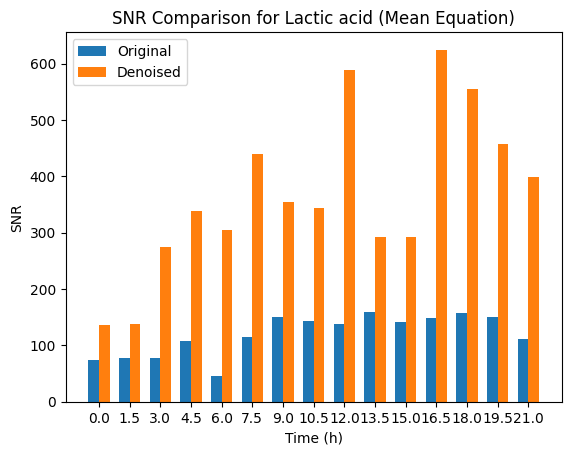

In [ ]:
df_lactic_acid_snr=snr_data_calculation(5,0.06,1.5,1.2,(-0.50,-0.20),141,2)
time_array=np.array(df_lactic_acid_snr['Time (h)'])
snr_mean_raw=np.array(df_lactic_acid_snr['Mean Eq (Raw)'])
snr_mean_smoothed=np.array(df_lactic_acid_snr['Mean Eq (Smoothed)'])

bar_width=0.35
r=np.arange(len(time_array))
plt.bar(r-(bar_width/2),snr_mean_raw,width=bar_width,label='Original')
plt.bar(r+(bar_width/2),snr_mean_smoothed,width=bar_width,label='Denoised')
plt.title('SNR Comparison for Lactic acid (Mean Equation)')
plt.xlabel('Time (h)')
plt.ylabel('SNR')
plt.legend()
plt.xticks(r,time_array)
plt.show()

#### SNR RMS

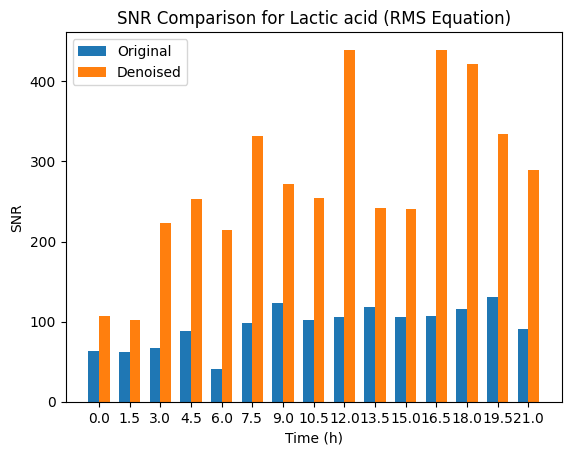

In [ ]:
df_lactic_acid_snr=snr_data_calculation(5,0.06,1.5,1.2,(-0.50,-0.20),141,2)
time_array=np.array(df_lactic_acid_snr['Time (h)'])
snr_rms_raw=np.array(df_lactic_acid_snr['RMS Eq (Raw)'])
snr_rms_smoothed=np.array(df_lactic_acid_snr['RMS Eq (Smoothed)'])

bar_width=0.35
r=np.arange(len(time_array))
plt.bar(r-(bar_width/2),snr_rms_raw,width=bar_width,label='Original')
plt.bar(r+(bar_width/2),snr_rms_smoothed,width=bar_width,label='Denoised')
plt.title('SNR Comparison for Lactic acid (RMS Equation)')
plt.xlabel('Time (h)')
plt.ylabel('SNR')
plt.legend()
plt.xticks(r,time_array)
plt.show()

#### SNR Max

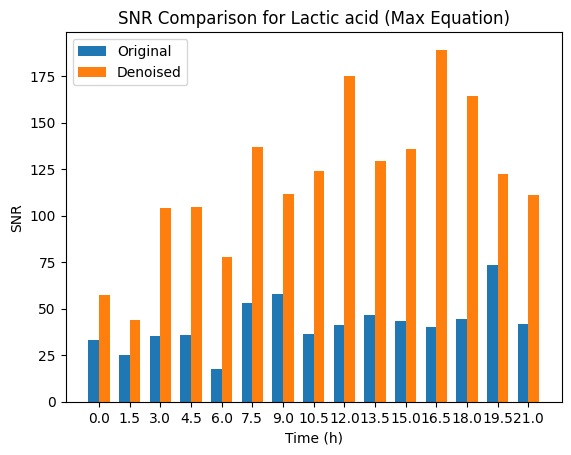

In [ ]:
df_lactic_acid_snr=snr_data_calculation(5,0.06,1.5,1.2,(-0.50,-0.20),141,2)
time_array=np.array(df_lactic_acid_snr['Time (h)'])
snr_max_raw=np.array(df_lactic_acid_snr['Max Eq (Raw)'])
snr_max_smoothed=np.array(df_lactic_acid_snr['Max Eq (Smoothed)'])

bar_width=0.35
r=np.arange(len(time_array))
plt.bar(r-(bar_width/2),snr_max_raw,width=bar_width,label='Original')
plt.bar(r+(bar_width/2),snr_max_smoothed,width=bar_width,label='Denoised')
plt.title('SNR Comparison for Lactic acid (Max Equation)')
plt.xlabel('Time (h)')
plt.ylabel('SNR')
plt.legend()
plt.xticks(r,time_array)
plt.show()

### Acetic acid

#### SNR Manufactured Equation

SNR valued for Acetic acid


,Time (h),SSFP,NMR Manufactured Eq (Raw),NMR Manufactured Eq (Smoothed),Mean Eq (Raw),Mean Eq (Smoothed),RMS Eq (Raw),RMS Eq (Smoothed),Max Eq (Raw),Max Eq (Smoothed)
0,0.0,1.Time_1_n6.csv,8.350381,2.852284,9.615373,2.325193,8.340295,1.812540,4.426559,0.924144
1,1.5,2.Time_2_n8.csv,7.383569,5.288009,8.691193,4.823657,7.215131,3.580257,3.033877,1.411299
2,3.0,3.Time_3_n10.csv,10.097184,10.147582,11.559875,7.053207,10.038886,5.820519,5.389816,2.596519
3,4.5,4.Time_4_n_14.csv,11.767874,11.076291,13.694886,9.066233,11.542595,7.047717,5.154208,3.064051
4,6.0,5.Time_5_n_17.csv,15.834377,23.998797,6.547206,24.079674,6.050397,17.073229,2.761728,6.006711
5,7.5,6.Time_6_n_20.csv,15.874179,82.468768,18.167987,74.606449,15.839004,55.610722,8.752385,21.144955


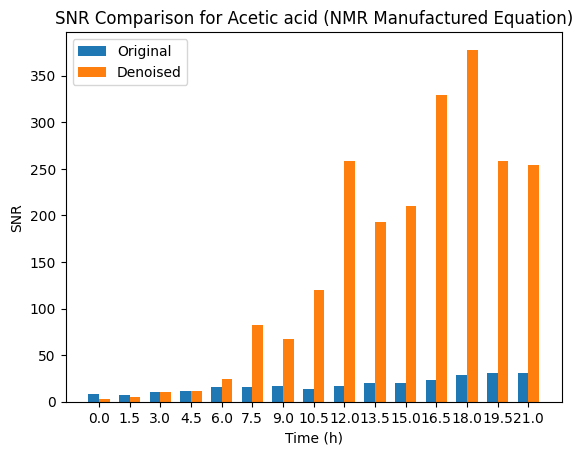

In [16]:
df_acetic_acid_snr=snr_data_calculation(5,0.06,2.1,1.7,(-0.60,-0.20),141,2)
time_array=np.array(df_acetic_acid_snr['Time (h)'])
snr_manu_raw=np.array(df_acetic_acid_snr['NMR Manufactured Eq (Raw)'])
snr_manu_smoothed=np.array(df_acetic_acid_snr['NMR Manufactured Eq (Smoothed)'])
print('SNR valued for Acetic acid')
display(df_acetic_acid_snr.head(6))
print('\n')

bar_width=0.35
r=np.arange(len(time_array))
plt.bar(r-(bar_width/2),snr_manu_raw,width=bar_width,label='Original')
plt.bar(r+(bar_width/2),snr_manu_smoothed,width=bar_width,label='Denoised')
plt.title('SNR Comparison for Acetic acid (NMR Manufactured Equation)')
plt.xlabel('Time (h)')
plt.ylabel('SNR')
plt.xticks(r,time_array)
plt.legend()
plt.show()

#### SNR Mean

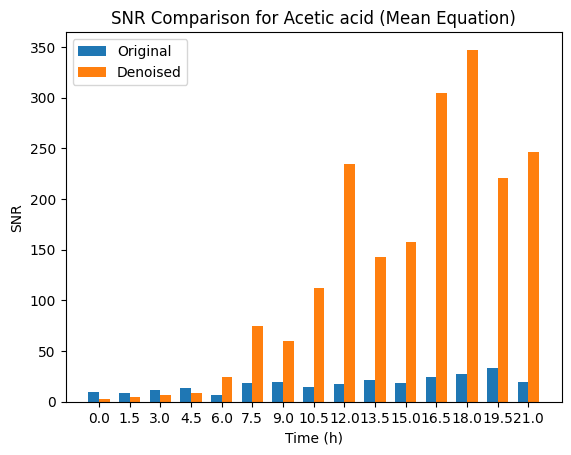

In [ ]:
df_acetic_acid_snr=snr_data_calculation(5,0.06,2.1,1.7,(-0.60,-0.20),141,2)
time_array=np.array(df_acetic_acid_snr['Time (h)'])
snr_mean_raw=np.array(df_acetic_acid_snr['Mean Eq (Raw)'])
snr_mean_smoothed=np.array(df_acetic_acid_snr['Mean Eq (Smoothed)'])

bar_width=0.35
r=np.arange(len(time_array))
plt.bar(r-(bar_width/2),snr_mean_raw,width=bar_width,label='Original')
plt.bar(r+(bar_width/2),snr_mean_smoothed,width=bar_width,label='Denoised')
plt.title('SNR Comparison for Acetic acid (Mean Equation)')
plt.xlabel('Time (h)')
plt.ylabel('SNR')
plt.legend()
plt.xticks(r,time_array)
plt.show()

#### SNR RMS

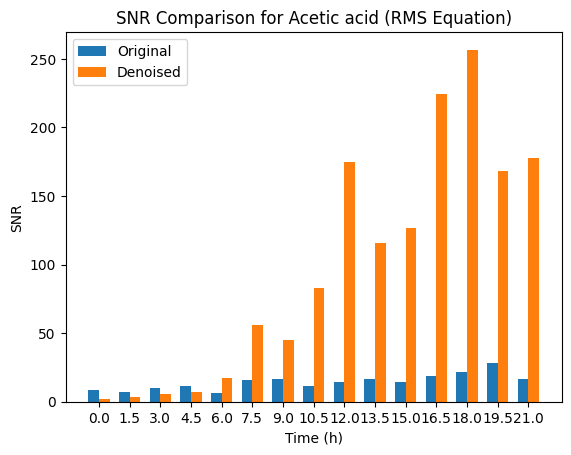

In [ ]:
df_acetic_acid_snr=snr_data_calculation(5,0.06,2.1,1.7,(-0.60,-0.20),141,2)
time_array=np.array(df_acetic_acid_snr['Time (h)'])
snr_rms_raw=np.array(df_acetic_acid_snr['RMS Eq (Raw)'])
snr_rms_smoothed=np.array(df_acetic_acid_snr['RMS Eq (Smoothed)'])

bar_width=0.35
r=np.arange(len(time_array))
plt.bar(r-(bar_width/2),snr_rms_raw,width=bar_width,label='Original')
plt.bar(r+(bar_width/2),snr_rms_smoothed,width=bar_width,label='Denoised')
plt.title('SNR Comparison for Acetic acid (RMS Equation)')
plt.xlabel('Time (h)')
plt.ylabel('SNR')
plt.legend()
plt.xticks(r,time_array)
plt.show()

#### SNR Max

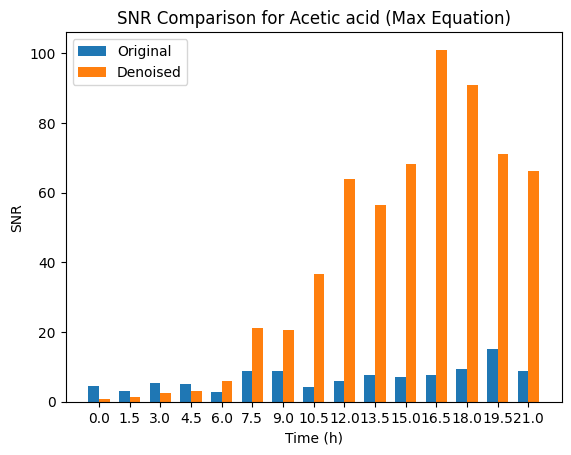

In [ ]:
df_acetic_acid_snr=snr_data_calculation(5,0.06,2.1,1.7,(-0.60,-0.20),141,2)
time_array=np.array(df_acetic_acid_snr['Time (h)'])
snr_max_raw=np.array(df_acetic_acid_snr['Max Eq (Raw)'])
snr_max_smoothed=np.array(df_acetic_acid_snr['Max Eq (Smoothed)'])

bar_width=0.35
r=np.arange(len(time_array))
plt.bar(r-(bar_width/2),snr_max_raw,width=bar_width,label='Original')
plt.bar(r+(bar_width/2),snr_max_smoothed,width=bar_width,label='Denoised')
plt.title('SNR Comparison for Acetic acid (Max Equation)')
plt.xlabel('Time (h)')
plt.ylabel('SNR')
plt.legend()
plt.xticks(r,time_array)
plt.show()

### Pyruvic Acid

#### SNR Manufactured Equation

SNR values for Pyruvic acid


,Time (h),SSFP,NMR Manufactured Eq (Raw),NMR Manufactured Eq (Smoothed),Mean Eq (Raw),Mean Eq (Smoothed),RMS Eq (Raw),RMS Eq (Smoothed),Max Eq (Raw),Max Eq (Smoothed)
0,0.0,1.Time_1_n6.csv,10.169473,6.449272,11.710037,5.257471,10.157190,4.098316,5.390864,2.089573
1,1.5,2.Time_2_n8.csv,8.922479,6.682941,10.502641,6.096097,8.718934,4.524698,3.666208,1.783587
2,3.0,3.Time_3_n10.csv,12.184932,12.252066,13.950056,8.515956,12.114579,7.027623,6.504243,3.135005
3,4.5,4.Time_4_n_14.csv,13.291486,11.572988,15.467993,9.472792,13.037040,7.363760,5.821535,3.201453
4,6.0,5.Time_5_n_17.csv,21.748870,10.887581,8.992734,10.924272,8.310355,7.745645,3.793295,2.725076
5,7.5,6.Time_6_n_20.csv,17.766309,20.443345,20.333528,18.494339,17.726940,13.785451,9.795629,5.241665
6,9.0,7.Time_7_n_23.csv,18.598389,14.667957,21.678522,13.107190,18.482923,9.806947,9.726846,4.517452
7,10.5,8.Time_8_n_26.csv,13.603319,43.341244,14.553594,40.549863,11.208341,29.764221,4.296837,13.244234


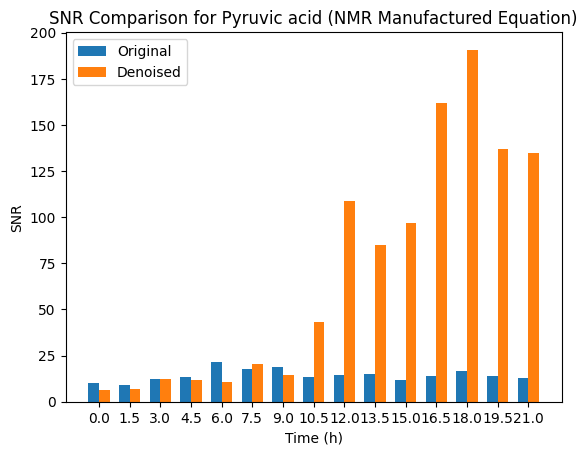

In [17]:
df_pyruvic_acid_snr=snr_data_calculation(5,0.06,2.6,2.2,(-0.60,-0.20),141,2)
time_array=np.array(df_pyruvic_acid_snr['Time (h)'])
snr_manu_raw=np.array(df_pyruvic_acid_snr['NMR Manufactured Eq (Raw)'])
snr_manu_smoothed=np.array(df_pyruvic_acid_snr['NMR Manufactured Eq (Smoothed)'])
print('SNR values for Pyruvic acid')
display(df_pyruvic_acid_snr.head(8))
print('\n')

bar_width=0.35
r=np.arange(len(time_array))
plt.bar(r-(bar_width/2),snr_manu_raw,width=bar_width,label='Original')
plt.bar(r+(bar_width/2),snr_manu_smoothed,width=bar_width,label='Denoised')
plt.title('SNR Comparison for Pyruvic acid (NMR Manufactured Equation)')
plt.xlabel('Time (h)')
plt.ylabel('SNR')
plt.xticks(r,time_array)
plt.legend()
plt.show()

#### SNR Mean

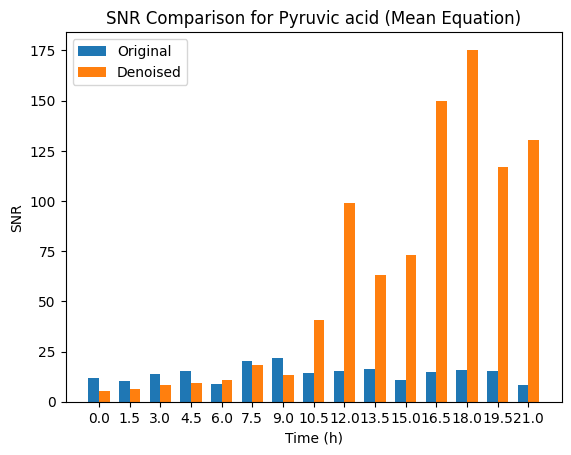

In [6]:
df_pyruvic_acid_snr=snr_data_calculation(5,0.06,2.6,2.2,(-0.60,-0.20),141,2)
time_array=np.array(df_pyruvic_acid_snr['Time (h)'])
snr_mean_raw=np.array(df_pyruvic_acid_snr['Mean Eq (Raw)'])
snr_mean_smoothed=np.array(df_pyruvic_acid_snr['Mean Eq (Smoothed)'])

bar_width=0.35
r=np.arange(len(time_array))
plt.bar(r-(bar_width/2),snr_mean_raw,width=bar_width,label='Original')
plt.bar(r+(bar_width/2),snr_mean_smoothed,width=bar_width,label='Denoised')
plt.title('SNR Comparison for Pyruvic acid (Mean Equation)')
plt.xlabel('Time (h)')
plt.ylabel('SNR')
plt.legend()
plt.xticks(r,time_array)
plt.show()

#### SNR RMS

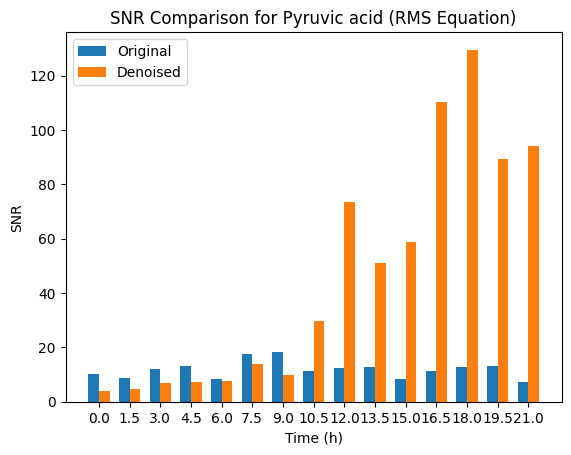

In [ ]:
df_pyruvic_acid_snr=snr_data_calculation(5,0.06,2.6,2.2,(-0.60,-0.20),141,2)
time_array=np.array(df_pyruvic_acid_snr['Time (h)'])
snr_rms_raw=np.array(df_pyruvic_acid_snr['RMS Eq (Raw)'])
snr_rms_smoothed=np.array(df_pyruvic_acid_snr['RMS Eq (Smoothed)'])

bar_width=0.35
r=np.arange(len(time_array))
plt.bar(r-(bar_width/2),snr_rms_raw,width=bar_width,label='Original')
plt.bar(r+(bar_width/2),snr_rms_smoothed,width=bar_width,label='Denoised')
plt.title('SNR Comparison for Pyruvic acid (RMS Equation)')
plt.xlabel('Time (h)')
plt.ylabel('SNR')
plt.legend()
plt.xticks(r,time_array)
plt.show()

#### SNR Max

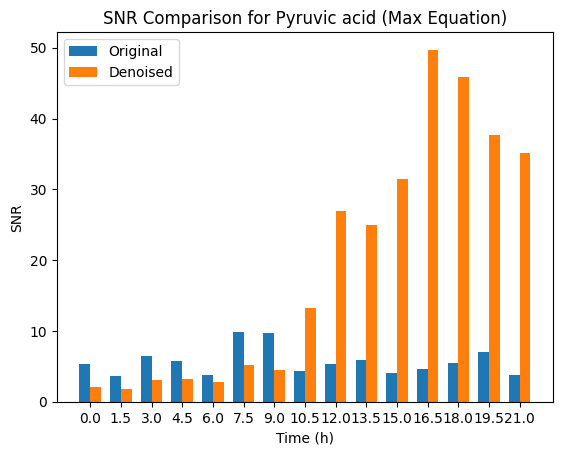

In [ ]:
df_pyruvic_acid_snr=snr_data_calculation(5,0.06,2.6,2.2,(-0.60,-0.20),141,2)
time_array=np.array(df_pyruvic_acid_snr['Time (h)'])
snr_max_raw=np.array(df_pyruvic_acid_snr['Max Eq (Raw)'])
snr_max_smoothed=np.array(df_pyruvic_acid_snr['Max Eq (Smoothed)'])

bar_width=0.35
r=np.arange(len(time_array))
plt.bar(r-(bar_width/2),snr_max_raw,width=bar_width,label='Original')
plt.bar(r+(bar_width/2),snr_max_smoothed,width=bar_width,label='Denoised')
plt.title('SNR Comparison for Pyruvic acid (Max Equation)')
plt.xlabel('Time (h)')
plt.ylabel('SNR')
plt.legend()
plt.xticks(r,time_array)
plt.show()

# Intensity vs time:

In [ ]:
#Setting the paths again:
path_proton='/content/SSFP---Daphnias-Data/Times - Proton - Daphnias/Times - Proton'
path_ssfp='/content/SSFP---Daphnias-Data/Times - SSFP - Daphnias/Times - SSFP'
import os
files_proton = [f for f in os.listdir(path_proton) if os.path.isfile(os.path.join(path_proton, f))]
files_ssfp = [f for f in os.listdir(path_ssfp) if os.path.isfile(os.path.join(path_ssfp, f))]

# Sort files numerically based on the leading number
files_proton.sort(key=lambda x: int(x.split('.')[0]))
files_ssfp.sort(key=lambda x: int(x.split('.')[0]))

print(f"Files in '{path_proton}':")
display(files_proton)

print(f"\nFiles in '{path_ssfp}':")
display(files_ssfp)

Files in '/content/SSFP---Daphnias-Data/Times - Proton - Daphnias/Times - Proton':


['1.Time_1_n6-proton.csv',
 '2.Time_2_n8-proton.csv',
 '3.Time_2_n8-proton.csv',
 '4.Time_4_n_14-proton.csv',
 '5.Time_5_n_17-proton.csv',
 '6.Time_6_n_20-proton.csv',
 '7.Time_7_n_23-proton.csv',
 '8.Time_8_n_26-proton.csv',
 '9.Time_9_n_29-proton.csv',
 '10.Time_10_n_32-proton.csv',
 '11.Time_11_n_35-proton.csv',
 '12.Time_12_n_38-proton.csv',
 '13.Time_13_n_41-proton.csv',
 '14.Time_14_n_44-proton.csv',
 '15.Time_15_n_47-proton.csv']


Files in '/content/SSFP---Daphnias-Data/Times - SSFP - Daphnias/Times - SSFP':


['1.Time_1_n6.csv',
 '2.Time_2_n8.csv',
 '3.Time_3_n10.csv',
 '4.Time_4_n_14.csv',
 '5.Time_5_n_17.csv',
 '6.Time_6_n_20.csv',
 '7.Time_7_n_23.csv',
 '8.Time_8_n_26.csv',
 '9.Time_9_n_29.csv',
 '10.Time_10_n_32.csv',
 '11.Time_11_n_35.csv',
 '12.Time_12_n_38.csv',
 '13.Time_13_n_41.csv',
 '14.Time_14_n_44.csv',
 '15.Time_15_n_47.csv']

In [ ]:
import numpy as np
import pandas as pd
# Create an array with the samples time
time_array = np.array([0,1.5,3,4.5,6,7.5,9,10.5,12,13.5,15,16.5,18,19.5,21])

# Convert the array to a pandas DF
df_time = pd.DataFrame(time_array)

df_time_files=pd.concat([df_time, pd.Series(files_ssfp),pd.Series(files_proton)], axis=1)
df_time_files.columns = ['Time (h)','SSFP','Proton'] # Corrected line: use '=' for assignment
# Display the DataFrame
display(df_time_files.head())

,Time (h),SSFP,Proton
0,0.0,1.Time_1_n6.csv,1.Time_1_n6-proton.csv
1,1.5,2.Time_2_n8.csv,2.Time_2_n8-proton.csv
2,3.0,3.Time_3_n10.csv,3.Time_2_n8-proton.csv
3,4.5,4.Time_4_n_14.csv,4.Time_4_n_14-proton.csv
4,6.0,5.Time_5_n_17.csv,5.Time_5_n_17-proton.csv


In [ ]:
#Defining the functions:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from pybaselines import Baseline
from pybaselines.whittaker import arpls
import os

def smoothed_short_maximum(input_filename,proton_filename,exponent_lambda,peso,upper_limit,lower_limit,width_length,polyorder):
    data = np.genfromtxt(input_filename, delimiter=',',
                        skip_footer=1, skip_header=1)
    data_proton = np.genfromtxt(proton_filename, delimiter=',',
                        skip_footer=1, skip_header=1)
    intensity_proton = data_proton[:, 0]
    chemical_shift_proton = data_proton[:, 2]

    # Existing data processing steps
    lambda_coef=10**exponent_lambda
    intensity_irregular = data[:, 0]
    chemical_shift = data[:, 2]
    fitter= Baseline(x_data=chemical_shift)
    baseline, params=fitter.iasls(intensity_irregular,lam=lambda_coef,p=peso)
    intensity= intensity_irregular-baseline
    smoothed_intensity_prev = savgol_filter(intensity, width_length,polyorder)
    baseline2, params2=fitter.iasls(smoothed_intensity_prev,lam=lambda_coef,p=peso)
    smoothed_intensity=smoothed_intensity_prev-baseline2

    data_base_correct = pd.DataFrame({'Chemical Shift': chemical_shift, 'Intensity': intensity})
    data_smooth = pd.DataFrame({'Chemical Shift': chemical_shift, 'Intensity': smoothed_intensity})

    #Local Extraction:
    mask = (chemical_shift <= upper_limit) & (chemical_shift >= lower_limit)
    extracted_data_df = data_smooth[mask]
    chemical_shift_extracted = extracted_data_df['Chemical Shift'].values
    smoothed_intensity_extracted = extracted_data_df['Intensity'].values

    #For proton
    mask_proton = (chemical_shift_proton <= upper_limit) & (chemical_shift_proton >= lower_limit)
    data_proton_extracted=data_proton[mask_proton]
    intensity_proton_extracted_prev=data_proton_extracted[:,0]
    chemical_shift_proton_extracted=data_proton_extracted[:,2]
    fitter2= Baseline(x_data=chemical_shift_proton_extracted)
    baseline2, params2= fitter2.iasls(intensity_proton_extracted_prev,lam=lambda_coef,p=peso)
    intensity_proton_extracted = intensity_proton_extracted_prev-baseline2

    return smoothed_intensity_extracted, intensity_proton_extracted

def intensity_vs_time(input_filename,proton_filename,exponent_lambda,peso,upper_limit,lower_limit,width_length,polyorder):
    #For ssfp:
    smoothed_ssfp, _ = smoothed_short_maximum(input_filename,proton_filename,exponent_lambda,peso,upper_limit,lower_limit,width_length,polyorder)
    max_intensity = np.max(smoothed_ssfp)

    #For proton:
    _, intensity_proton = smoothed_short_maximum(input_filename,proton_filename,exponent_lambda,peso,upper_limit,lower_limit,width_length,polyorder)
    max_intensity_proton = np.max(intensity_proton)

    return max_intensity, max_intensity_proton

##Formic acid (~ 8.4 ppm)

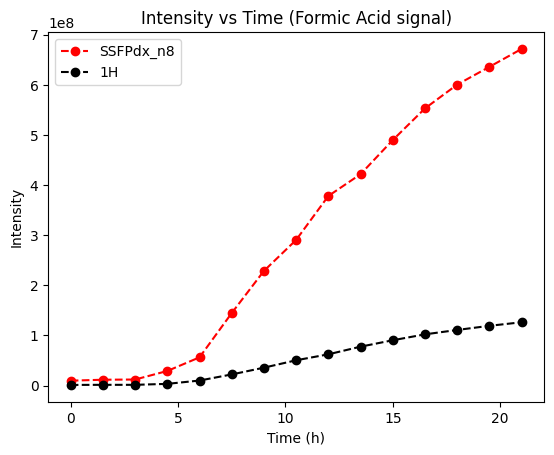

In [ ]:
# Initialize lists to store the maximum intensities
max_intensities_ssfp_formic = []
max_intensities_proton_formic = []

# Iterate through the DataFrame rows
for index, row in df_time_files.iterrows():
    # Construct the full paths to the files
    full_path_ssfp = f"{path_ssfp}/{row['SSFP']}"
    full_path_proton = f"{path_proton}/{row['Proton']}"

    # Call the intensity_vs_time function for each pair of files_
    max_ssfp, max_proton = intensity_vs_time(
        full_path_ssfp,
        full_path_proton,
        5,
        0.06,
        8.6,
        8.3,
        141,
        2
    )
    max_intensities_ssfp_formic.append(max_ssfp)
    max_intensities_proton_formic.append(max_proton)

# Add the results to the DataFrame
df_time_files['Max_Intensity_SSFP_formic'] = max_intensities_ssfp_formic
df_time_files['Max_Intensity_Proton_formic'] = max_intensities_proton_formic

#Plotting the graph
plt.plot(df_time_files['Time (h)'],df_time_files['Max_Intensity_SSFP_formic'], marker='o', linestyle='--',color='red')
plt.plot(df_time_files['Time (h)'],df_time_files['Max_Intensity_Proton_formic'], marker='o', linestyle='--',color='black')
plt.legend(['SSFPdx_n8','1H'])
plt.title('Intensity vs Time (Formic Acid signal)')
plt.xlabel('Time (h)')
plt.ylabel('Intensity')
plt.show()

##Lactic Acid (~1.3 ppm)

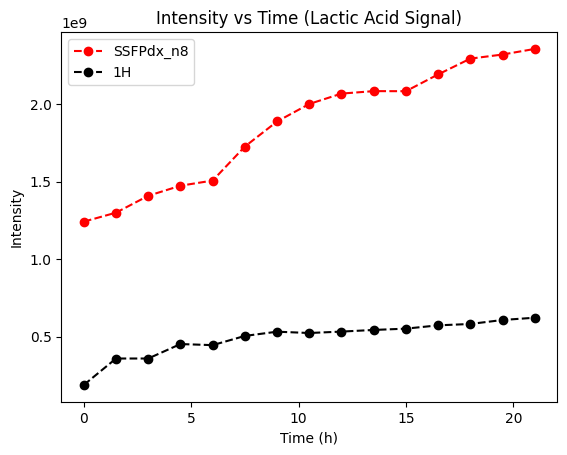

In [ ]:
# Initialize lists to store the maximum intensities
max_intensities_ssfp_lactic = []
max_intensities_proton_lactic = []

# Iterate through the DataFrame rows
for index, row in df_time_files.iterrows():
    # Construct the full paths to the files
    full_path_ssfp = f"{path_ssfp}/{row['SSFP']}"
    full_path_proton = f"{path_proton}/{row['Proton']}"

    # Call the intensity_vs_time function for each pair of files_
    max_ssfp, max_proton = intensity_vs_time(
        full_path_ssfp,
        full_path_proton,
        5,
        0.06,
        1.5,
        1.2,
        141,
        2
    )
    max_intensities_ssfp_lactic.append(max_ssfp)
    max_intensities_proton_lactic.append(max_proton)

# Add the results to the df_time_files DataFrame
df_time_files['Max_Intensity_SSFP_lactic'] = max_intensities_ssfp_lactic
df_time_files['Max_Intensity_Proton_lactic'] = max_intensities_proton_lactic

plt.plot(df_time_files['Time (h)'],df_time_files['Max_Intensity_SSFP_lactic'], marker='o', linestyle='--',color='red')
plt.plot(df_time_files['Time (h)'],df_time_files['Max_Intensity_Proton_lactic'], marker='o', linestyle='--',color='black')
plt.legend(['SSFPdx_n8','1H'])
plt.title('Intensity vs Time (Lactic Acid Signal)')
plt.xlabel('Time (h)')
plt.ylabel('Intensity')
plt.show()

##Acetic Acid (~1.9 ppm)

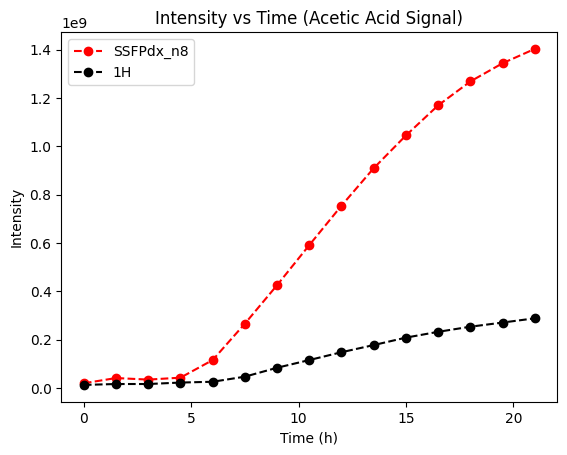

In [ ]:
# Initialize lists to store the maximum intensities
max_intensities_ssfp_acetic = []
max_intensities_proton_acetic = []

# Iterate through the DataFrame rows
for index, row in df_time_files.iterrows():
    # Construct the full paths to the files
    full_path_ssfp = f"{path_ssfp}/{row['SSFP']}"
    full_path_proton = f"{path_proton}/{row['Proton']}"

    # Call the intensity_vs_time function for each pair of files_
    max_ssfp, max_proton = intensity_vs_time(
        full_path_ssfp,
        full_path_proton,
        5,
        0.06,
        2.1,
        1.7,
        141,
        2
    )
    max_intensities_ssfp_acetic.append(max_ssfp)
    max_intensities_proton_acetic.append(max_proton)

# Add the results to the df_time_files DataFrame
df_time_files['Max_Intensity_SSFP_acetic'] = max_intensities_ssfp_acetic
df_time_files['Max_Intensity_Proton_acetic'] = max_intensities_proton_acetic

#Plotting data
plt.plot(df_time_files['Time (h)'],df_time_files['Max_Intensity_SSFP_acetic'], marker='o', linestyle='--',color='red')
plt.plot(df_time_files['Time (h)'],df_time_files['Max_Intensity_Proton_acetic'], marker='o', linestyle='--',color='black')
plt.legend(['SSFPdx_n8','1H'])
plt.title('Intensity vs Time (Acetic Acid Signal)')
plt.xlabel('Time (h)')
plt.ylabel('Intensity')
plt.show()

##Pyruvic Acid (~2.4 ppm)

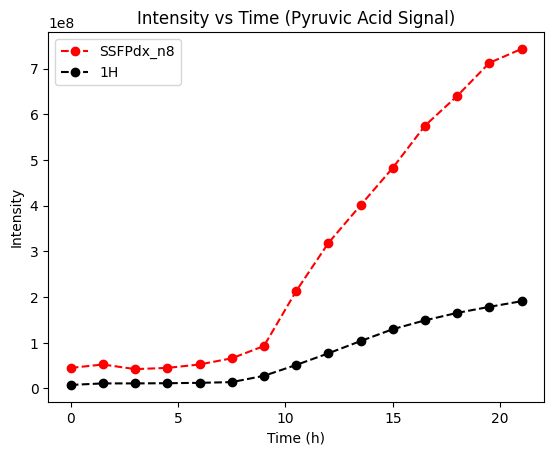

In [ ]:
# Initialize lists to store the maximum intensities
max_intensities_ssfp_pyruvic = []
max_intensities_proton_pyruvic = []

# Iterate through the DataFrame rows
for index, row in df_time_files.iterrows():
    # Construct the full paths to the files
    full_path_ssfp = f"{path_ssfp}/{row['SSFP']}"
    full_path_proton = f"{path_proton}/{row['Proton']}"

    # Call the intensity_vs_time function for each pair of files_
    max_ssfp, max_proton = intensity_vs_time(
        full_path_ssfp,
        full_path_proton,
        5,
        0.06,
        2.6,
        2.2,
        141,
        2
    )
    max_intensities_ssfp_pyruvic.append(max_ssfp)
    max_intensities_proton_pyruvic.append(max_proton)

# Add the results to the df_time_files DataFrame
df_time_files['Max_Intensity_SSFP_pyruvic'] = max_intensities_ssfp_pyruvic
df_time_files['Max_Intensity_Proton_pyruvic'] = max_intensities_proton_pyruvic

plt.plot(df_time_files['Time (h)'],df_time_files['Max_Intensity_SSFP_pyruvic'], marker='o', linestyle='--',color='red')
plt.plot(df_time_files['Time (h)'],df_time_files['Max_Intensity_Proton_pyruvic'], marker='o', linestyle='--',color='black')
plt.legend(['SSFPdx_n8','1H'])
plt.title('Intensity vs Time (Pyruvic Acid Signal)')
plt.xlabel('Time (h)')
plt.ylabel('Intensity')
plt.show()

#Spectra Graphics over time

##2D Lines

In [ ]:
#Defining the functions
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import interp1d

def smoothed_data_plotting(input_filename,proton_filename,exponent_lambda,peso,upper_limit,lower_limit,width_length,polyorder,Normalyzed):
    data = np.genfromtxt(input_filename, delimiter=',',
                        skip_footer=1, skip_header=1)
    data_proton = np.genfromtxt(proton_filename, delimiter=',',
                        skip_footer=1, skip_header=1)
    intensity_proton = data_proton[:, 0]
    chemical_shift_proton = data_proton[:, 2]

    # Existing data processing steps
    lambda_coef=10**exponent_lambda
    intensity_irregular = data[:, 0]
    chemical_shift = data[:, 2]
    fitter= Baseline(x_data=chemical_shift)
    baseline, params=fitter.iasls(intensity_irregular,lam=lambda_coef,p=peso)
    intensity= intensity_irregular-baseline
    smoothed_intensity_prev = savgol_filter(intensity, width_length,polyorder)
    baseline2, params2=fitter.iasls(smoothed_intensity_prev,lam=lambda_coef,p=peso)
    smoothed_intensity=smoothed_intensity_prev-baseline2
    data_base_correct = pd.DataFrame({'Chemical Shift': chemical_shift, 'Intensity': intensity})
    data_smooth = pd.DataFrame({'Chemical Shift': chemical_shift, 'Intensity': smoothed_intensity})

    #Delimited range:
    mask = (chemical_shift <= upper_limit) & (chemical_shift >= lower_limit)
    data_extracted=data_smooth[mask]
    extracted_data_df = pd.DataFrame(data_extracted)
    chemical_shift_extracted = extracted_data_df['Chemical Shift'].values
    smoothed_intensity_extracted = extracted_data_df['Intensity'].values

    #For proton
    baseline_proton, params_proton=fitter.iasls(intensity_proton,lam=lambda_coef,p=peso)
    intensity_proton_norm= intensity_proton-baseline_proton
    data_proton_correct = pd.DataFrame({'Chemical Shift': chemical_shift_proton, 'Intensity': intensity_proton_norm})
    mask_proton = (chemical_shift_proton <= upper_limit) & (chemical_shift_proton >= lower_limit)
    data_proton_extracted=data_proton_correct[mask_proton]
    intensity_proton_extracted=data_proton_extracted['Intensity'].values
    chemical_shift_proton_extracted=data_proton_extracted['Chemical Shift'].values

    return smoothed_intensity_extracted, intensity_proton_extracted, chemical_shift_extracted, chemical_shift_proton_extracted

def get_spectrum_data_for_time_point(input_filename,proton_filename,exponent_lambda,peso,upper_limit,lower_limit,width_length,polyorder,Normalyzed):
  return smoothed_data_plotting(input_filename,proton_filename,exponent_lambda,peso,upper_limit,lower_limit,width_length,polyorder,Normalyzed)

def plot_nmr_over_time_2d_lines(df_time_files, path_ssfp, path_proton, exponent_lambda, peso, upper_limit, lower_limit, width_length, polyorder, Normalyzed):
    path_proton='/content/SSFP---Daphnias-Data/Times - Proton - Daphnias/Times - Proton'
    path_ssfp='/content/SSFP---Daphnias-Data/Times - SSFP - Daphnias/Times - SSFP'
    all_smoothed_ssfp_intensities = []
    all_proton_intensities = []
    chemical_shifts_ssfp = None # This will be the common reference chemical shift axis
    chemical_shifts_proton = None # This will be the common reference chemical shift axis
    time_points = df_time_files['Time (h)'].values

    for index, row in df_time_files.iterrows():
        full_path_ssfp = f"{path_ssfp}/{row['SSFP']}"
        full_path_proton = f"{path_proton}/{row['Proton']}"

        smoothed_ssfp_raw, proton_intensity_raw, cs_ssfp_raw, cs_proton_raw = get_spectrum_data_for_time_point(
            full_path_ssfp, full_path_proton, exponent_lambda, peso, upper_limit, lower_limit, width_length, polyorder, Normalyzed
        )

        if index == 0: # For the first file, set the reference chemical shifts
            chemical_shifts_ssfp = cs_ssfp_raw
            chemical_shifts_proton = cs_proton_raw
            interpolated_smoothed_ssfp = smoothed_ssfp_raw
            interpolated_proton_intensity = proton_intensity_raw
        else: # For subsequent files, interpolate to the reference chemical shift
            # SSFP interpolation
            f_ssfp = interp1d(cs_ssfp_raw, smoothed_ssfp_raw, kind='linear', fill_value="extrapolate")
            interpolated_smoothed_ssfp = f_ssfp(chemical_shifts_ssfp)

            # Proton interpolation
            f_proton = interp1d(cs_proton_raw, proton_intensity_raw, kind='linear', fill_value="extrapolate")
            interpolated_proton_intensity = f_proton(chemical_shifts_proton)

        all_smoothed_ssfp_intensities.append(interpolated_smoothed_ssfp)
        all_proton_intensities.append(interpolated_proton_intensity)

    # Convert lists of 1D arrays to 2D arrays for easy iteration
    Z_ssfp = np.array(all_smoothed_ssfp_intensities)
    Z_proton = np.array(all_proton_intensities)

    # Create a single figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # Plot SSFP spectra
    for i, time_point in enumerate(time_points):
        axes[0].plot(chemical_shifts_ssfp, Z_ssfp[i], lw=0.8, label=f'Time: {time_point}h')
    axes[0].set_xlabel('Chemical Shift (ppm)')
    axes[0].invert_xaxis()
    axes[0].set_ylabel('Intensity')
    axes[0].set_title('SSFPdx_n8 NMR in time')
    axes[0].legend(loc='upper right', bbox_to_anchor=(1.2, 1))

    # Plot Proton NMR
    for i, time_point in enumerate(time_points):
        axes[1].plot(chemical_shifts_proton, Z_proton[i], lw=0.8, label=f'Time: {time_point}h')
    axes[1].set_xlabel('Chemical Shift (ppm)')
    axes[1].invert_xaxis()
    axes[1].set_ylabel('Intensity')
    axes[1].set_title('1H NMR in time')
    axes[1].legend(loc='upper right', bbox_to_anchor=(1.2, 1))

    plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for legends
    plt.show()

    # Return figures and axes if needed for further manipulation
    return fig, axes

###Formic Acid

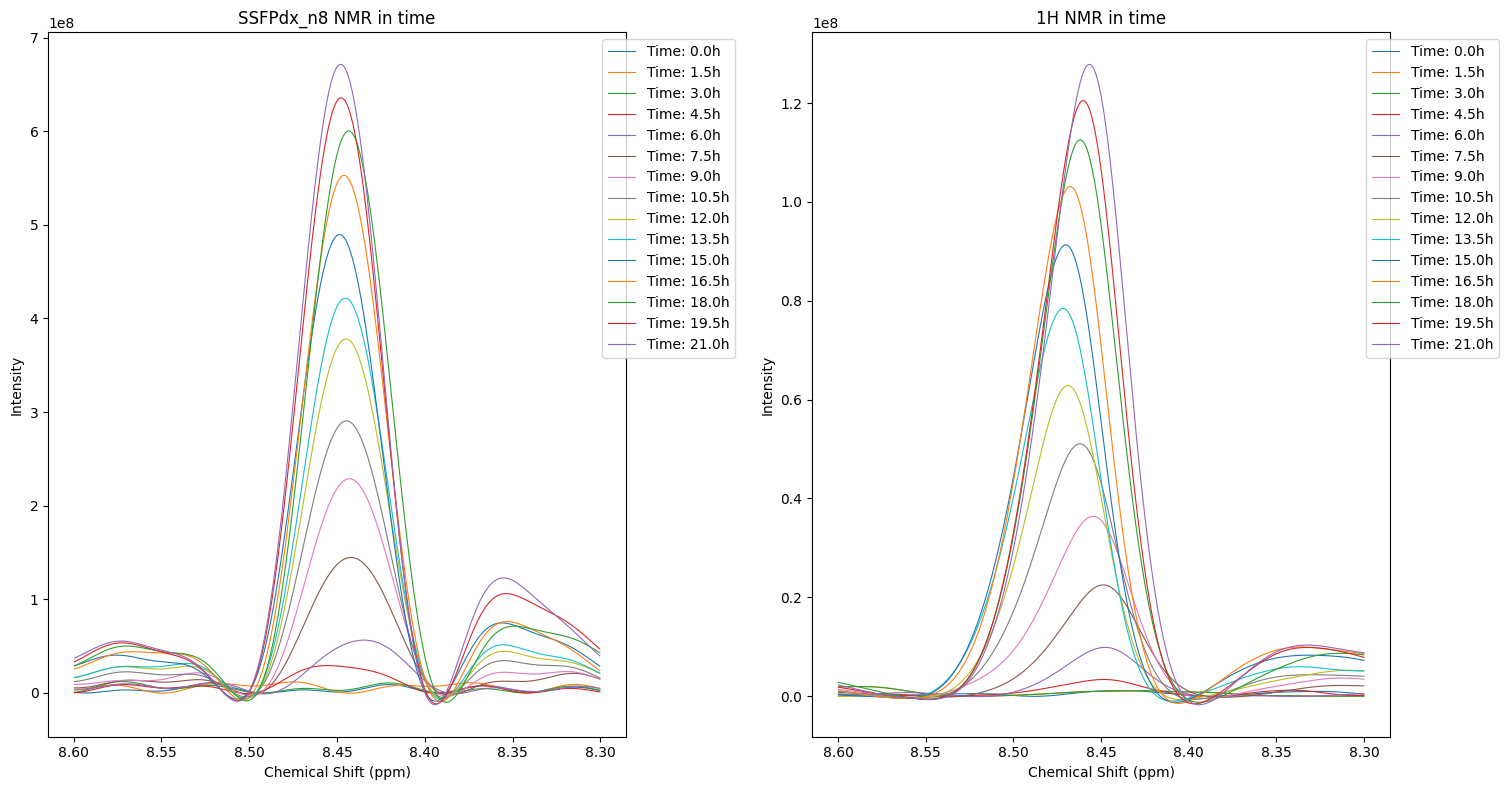

In [ ]:
# Call the new function to generate the 2D line plots
fig, axes = plot_nmr_over_time_2d_lines(
    df_time_files,
    path_ssfp,
    path_proton,
    5,
    0.06,
    8.6,
    8.3,
    141,
    2,
    False
)

###Lactic Acid

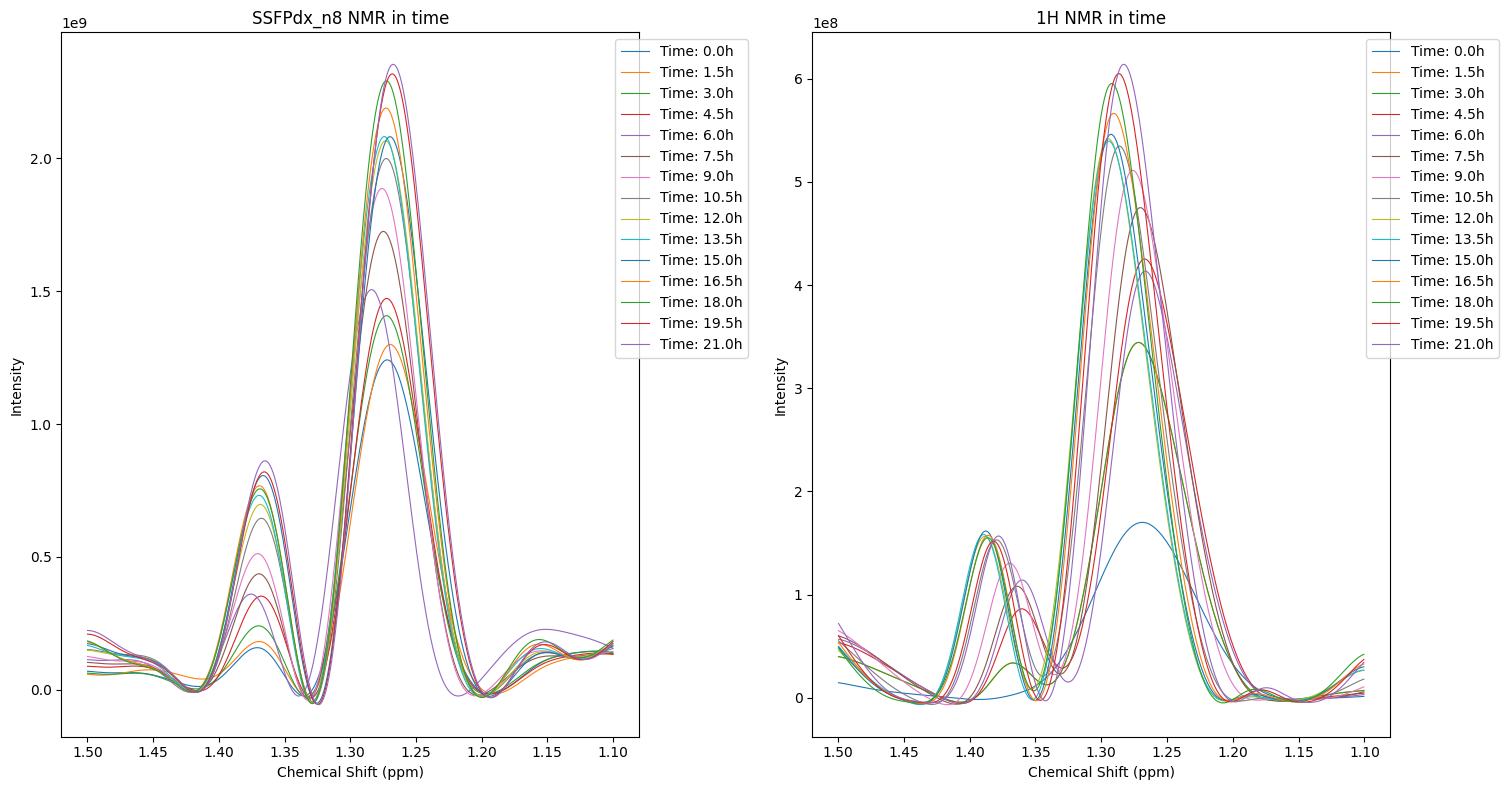

In [ ]:
# Call the new function to generate the 2D line plots
fig, axes = plot_nmr_over_time_2d_lines(
    df_time_files,
    path_ssfp,
    path_proton,
    5,
    0.06,
    1.5,
    1.1,
    141,
    2,
    False
)

###Acetic Acid

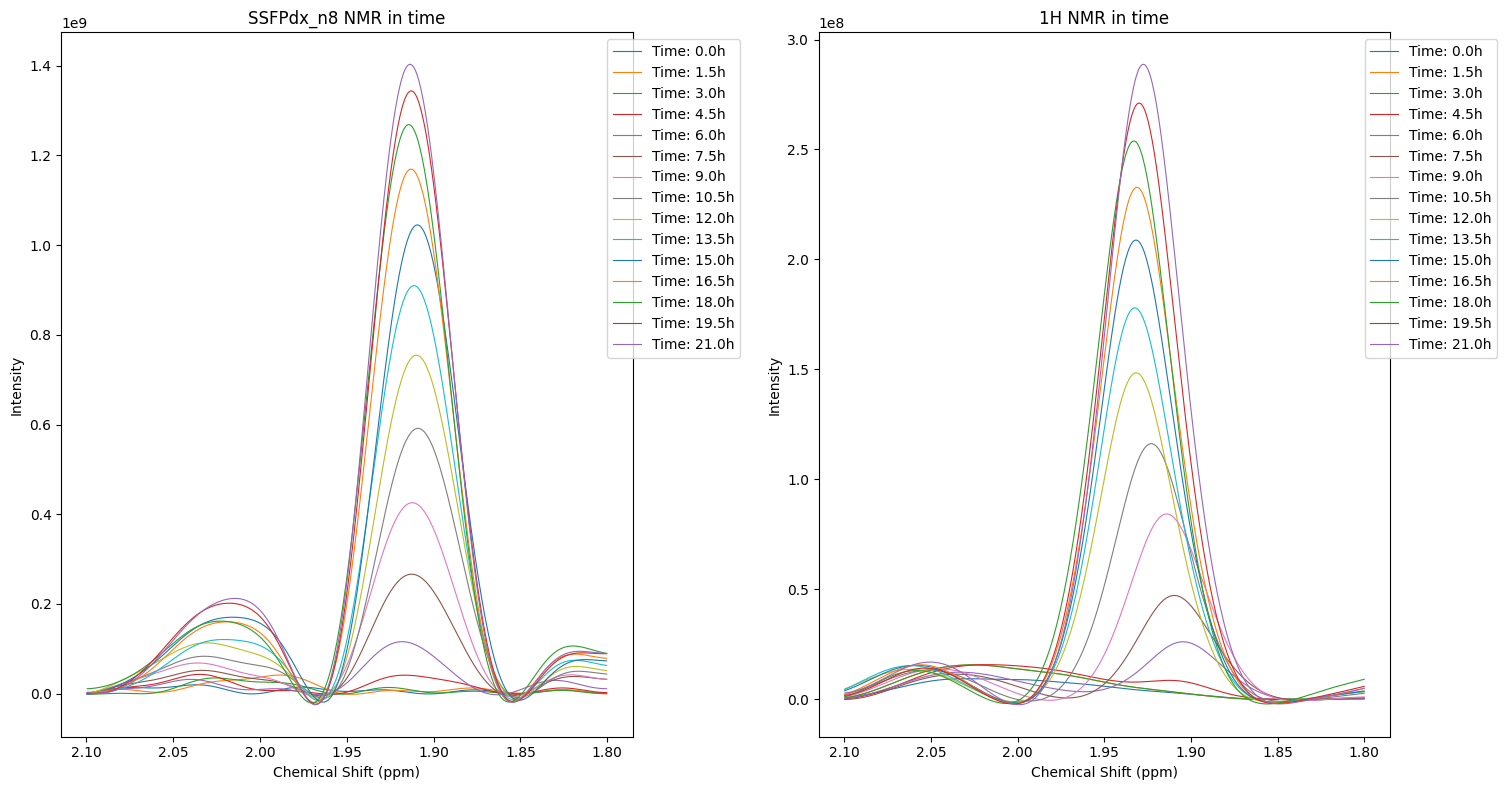

In [ ]:
# Call the new function to generate the 2D line plots
fig, axes = plot_nmr_over_time_2d_lines(
    df_time_files,
    path_ssfp,
    path_proton,
    5,
    0.06,
    2.1,
    1.8,
    141,
    2,
    False
)

###Pyruvic Acid

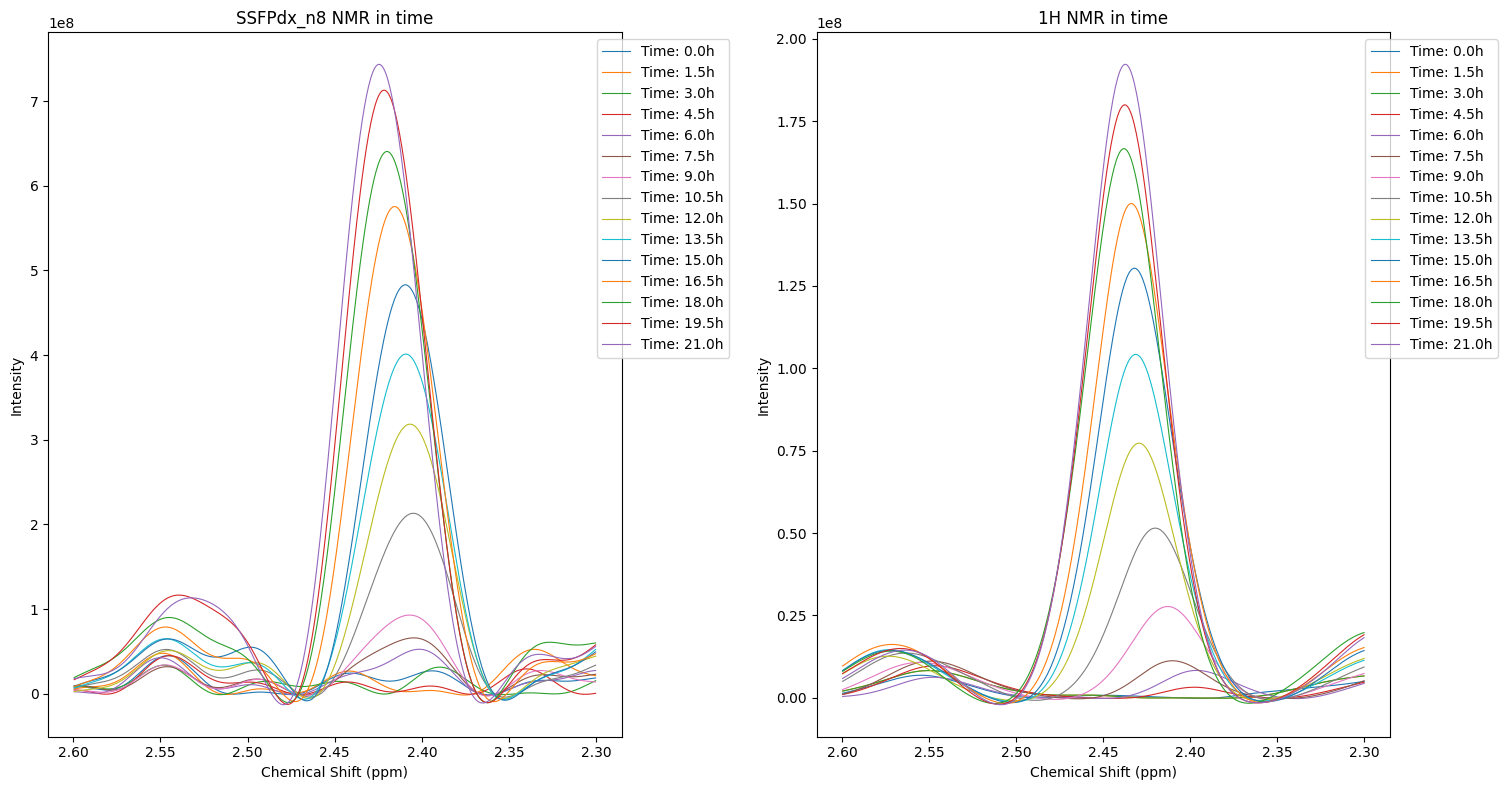

In [ ]:
# Call the new function to generate the 2D line plots
fig, axes = plot_nmr_over_time_2d_lines(
    df_time_files,
    path_ssfp,
    path_proton,
    5,
    0.06,
    2.6,
    2.3,
    141,
    2,
    False
)

##3D Stacks

In [ ]:
#Defining the functon
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from pybaselines import Baseline
from scipy.interpolate import interp1d

def plot_nmr_data_3d_stack(Molecule,df_time_files, path_ssfp, path_proton, exponent_lambda, peso, upper_limit, lower_limit, width_length, polyorder, Normalyzed):
    all_smoothed_ssfp_intensities = []
    all_proton_intensities = []
    chemical_shifts_ssfp = None
    chemical_shifts_proton = None
    time_points = df_time_files['Time (h)'].values

    for index, row in df_time_files.iterrows():
        full_path_ssfp = f"{path_ssfp}/{row['SSFP']}"
        full_path_proton = f"{path_proton}/{row['Proton']}"

        smoothed_ssfp_raw, proton_intensity_raw, cs_ssfp_raw, cs_proton_raw = get_spectrum_data_for_time_point(
            full_path_ssfp, full_path_proton, exponent_lambda, peso, upper_limit, lower_limit, width_length, polyorder, Normalyzed
        )

        if index == 0: # For the first file, set the reference chemical shifts
            chemical_shifts_ssfp = cs_ssfp_raw
            chemical_shifts_proton = cs_proton_raw
            interpolated_smoothed_ssfp = smoothed_ssfp_raw
            interpolated_proton_intensity = proton_intensity_raw
        else: # For subsequent files, interpolate to the reference chemical shift
            # SSFP interpolation
            f_ssfp = interp1d(cs_ssfp_raw, smoothed_ssfp_raw, kind='linear', fill_value="extrapolate")
            interpolated_smoothed_ssfp = f_ssfp(chemical_shifts_ssfp)

            # Proton interpolation
            f_proton = interp1d(cs_proton_raw, proton_intensity_raw, kind='linear', fill_value="extrapolate")
            interpolated_proton_intensity = f_proton(chemical_shifts_proton)

        all_smoothed_ssfp_intensities.append(interpolated_smoothed_ssfp)
        all_proton_intensities.append(interpolated_proton_intensity)

    # Convert lists of 1D arrays to 2D arrays
    Z_ssfp = np.array(all_smoothed_ssfp_intensities)
    Z_proton = np.array(all_proton_intensities)

    # Create a 3D figure with two subplots
    fig = plt.figure(figsize=(20, 20)) # Adjusted figure size

    fig.suptitle(f'3D Stacks Plots for {Molecule}', y=0.90, fontsize=16) # Main title for the entire figure

    # SSFP Subplot
    ax1 = fig.add_subplot(2, 2, 1, projection='3d')
    ax1.grid(False) # Remove grid
    for i, time_point in enumerate(time_points):
        # Plot each spectrum as a line, offset by time_point along the y-axis
        ax1.plot(chemical_shifts_ssfp, Z_ssfp[i], zs=time_point, zdir='y', lw=0.8, color='red')
    ax1.set_xlabel('Chemical Shift (ppm)')
    ax1.set_ylabel('Time (h)')
    ax1.set_zlabel('Intensity') # Z-axis label remains Intensity
    ax1.set_title(f'SSFPdx_n8 NMR over Time ({Molecule})',y=0.94)
    ax1.invert_xaxis()
    ax1.view_init(elev=20, azim=-120) # Adjust view angle for better stack visualization


    # Proton Subplot
    ax2 = fig.add_subplot(2, 2, 2, projection='3d')
    ax2.grid(False) # Remove grid
    for i, time_point in enumerate(time_points):
        # Plot each spectrum as a line, offset by time_point along the y-axis
        ax2.plot(chemical_shifts_proton, Z_proton[i], zs=time_point, zdir='y', lw=0.8, color='black')
    ax2.set_xlabel('Chemical Shift (ppm)')
    ax2.set_ylabel('Time (h)')
    ax2.set_zlabel('Intensity') # Z-axis label remains Intensity
    ax2.set_title(f'1H NMR over Time ({Molecule})',y=0.94)
    ax2.invert_xaxis()
    ax2.view_init(elev=20, azim=-120) # Adjust view angle for better stack visualization

    #SSFP and Proton Subplot
    ax3 = fig.add_subplot(2, 2, 3, projection='3d')
    ax3.grid(False) # Remove grid
    for i, time_point in enumerate(time_points):
        # Plot each spectrum as a line, offset by time_point along the y-axis
        # Assign labels only for the first iteration to avoid duplicate legend entries
        ax3.plot(chemical_shifts_ssfp, Z_ssfp[i], zs=time_point, zdir='y', lw=0.8, color='red', label='SSFPdx_n8 NMR' if i == 0 else "_nolegend_")
        ax3.plot(chemical_shifts_proton, Z_proton[i], zs=time_point, zdir='y', lw=0.8, color='black', label='1H NMR' if i == 0 else "_nolegend_",linestyle='--')
    ax3.set_xlabel('Chemical Shift (ppm)')
    ax3.set_ylabel('Time (h)')
    ax3.set_zlabel('Intensity') # Z-axis label remains Intensity
    ax3.set_title(f'SSFPdx_n8 and 1H NMR over Time ({Molecule})',y=0.94)
    ax3.invert_xaxis()
    ax3.legend(loc='upper right', bbox_to_anchor=(1,0.75)) # Adjust legend position to be outside the plot area
    ax3.view_init(elev=20, azim=-120) # Adjust view angle for better stack visualization

    plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to make space for the suptitle
    plt.show()


###Formic Acid

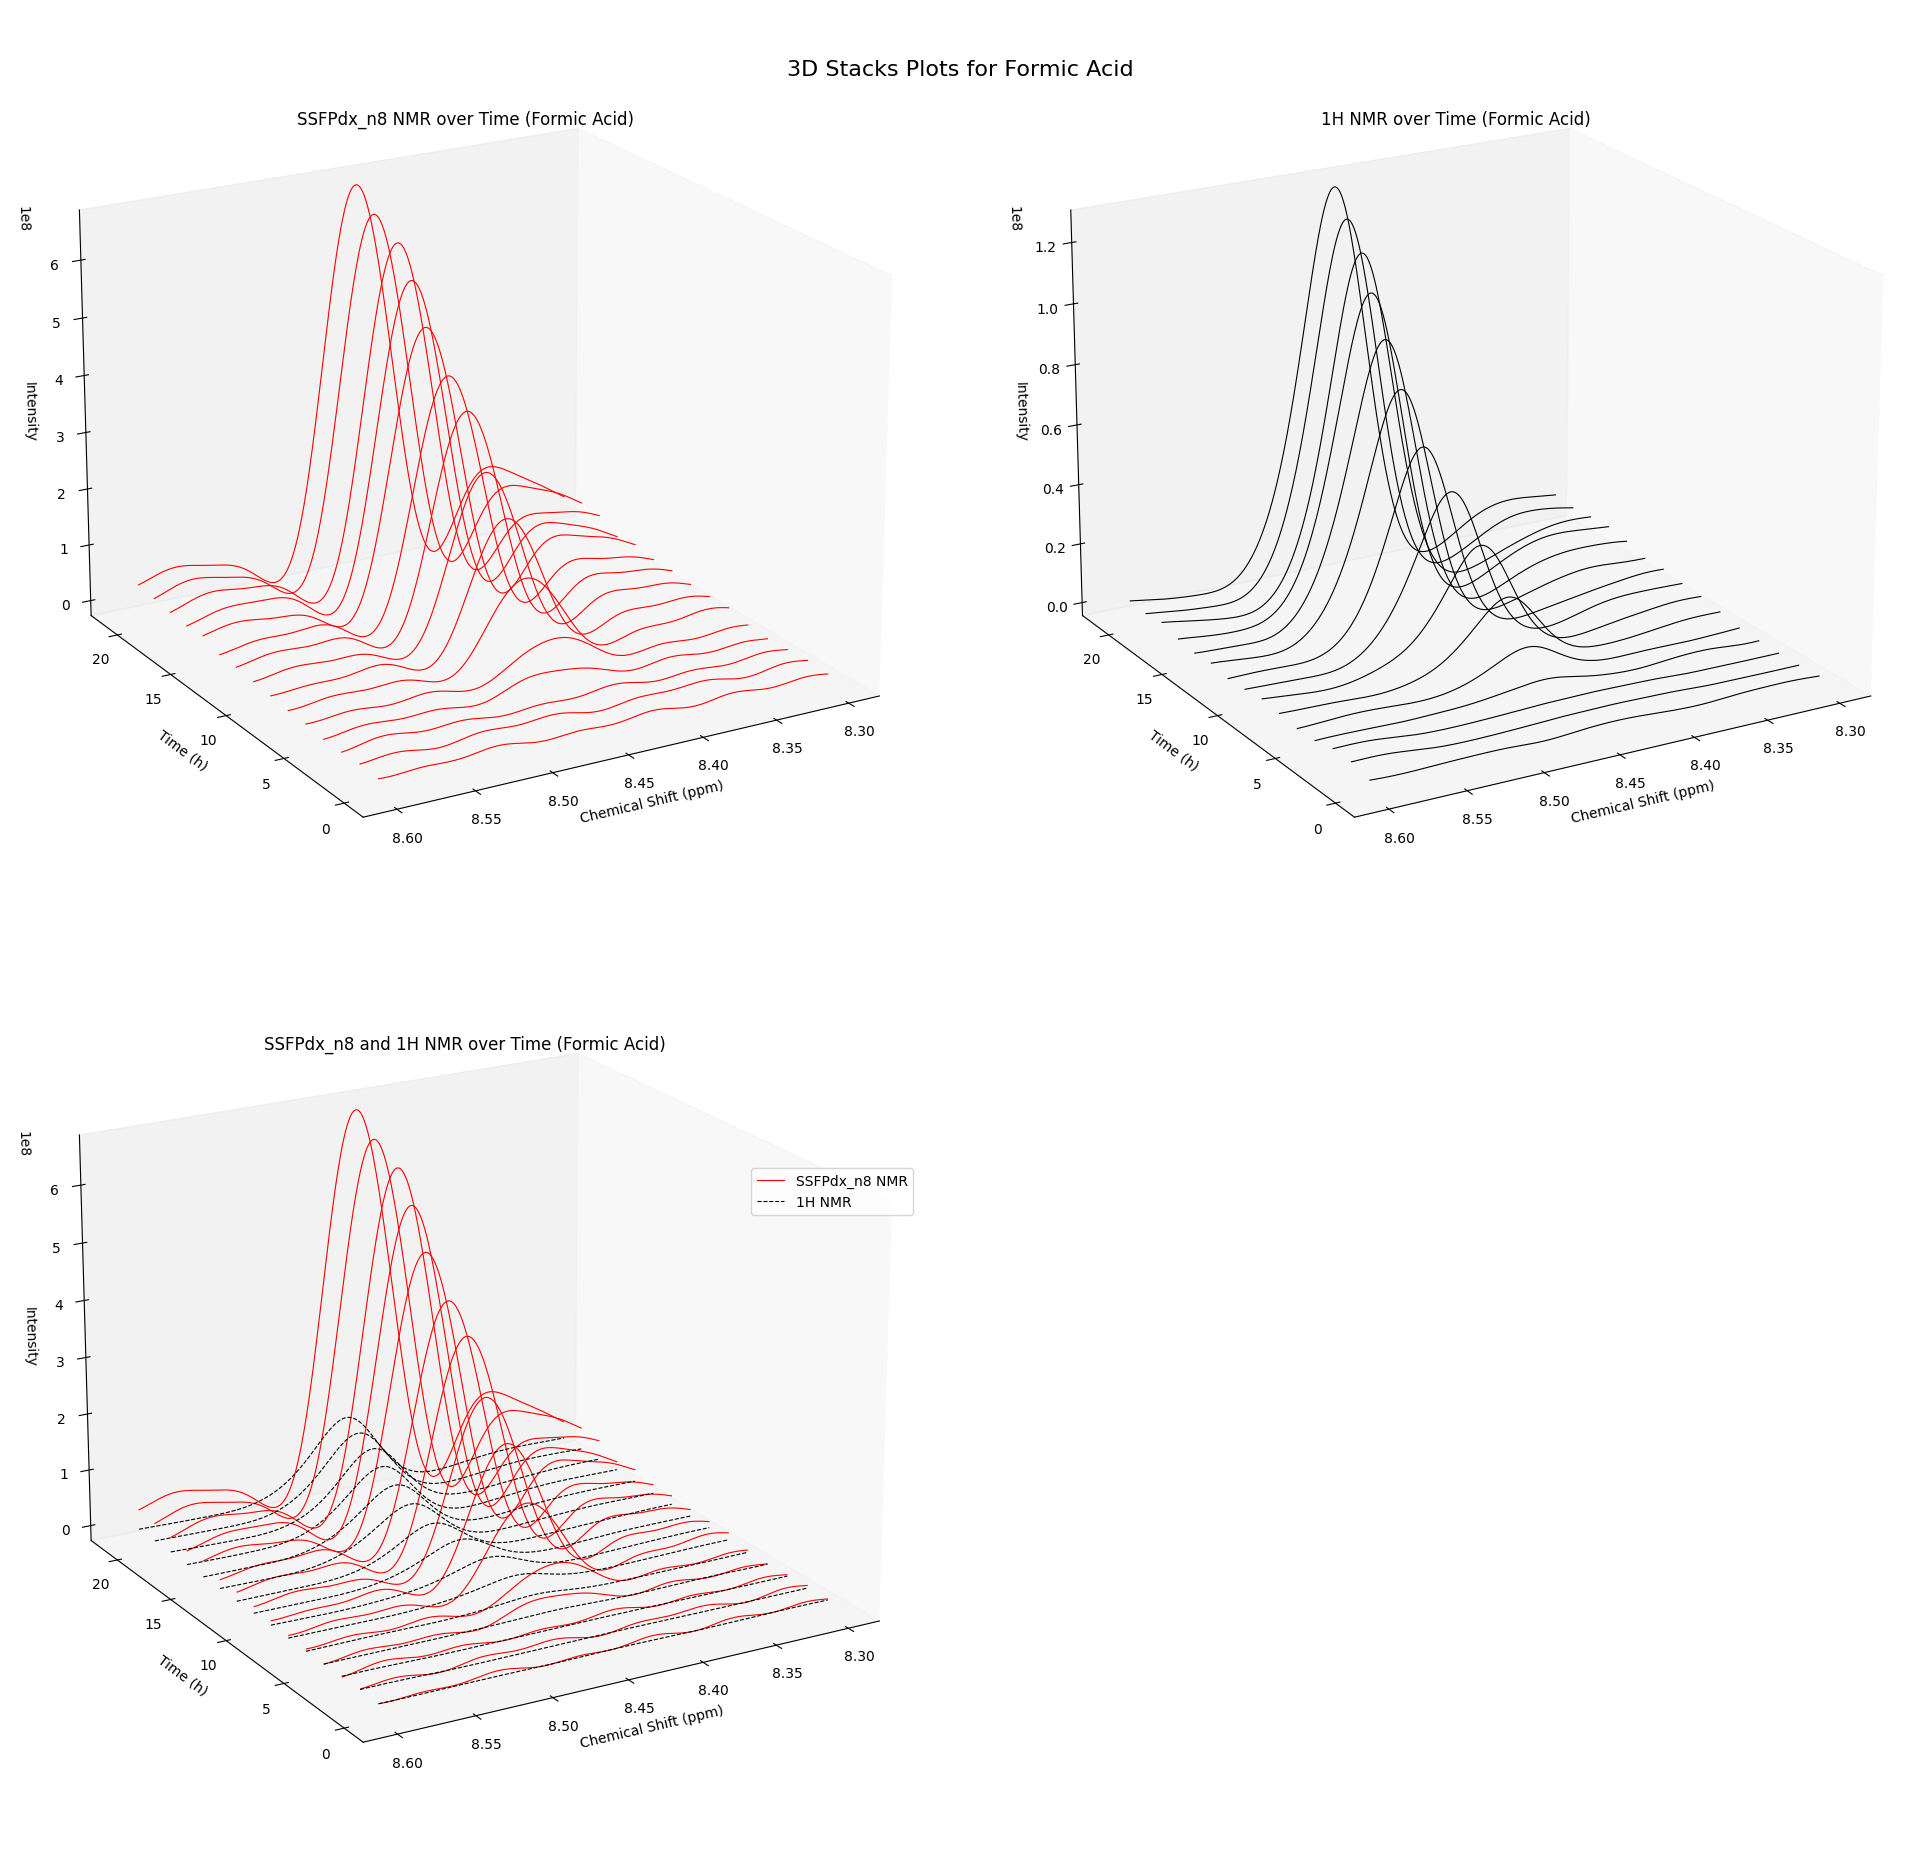

In [ ]:
# Call the new function to generate the 3D line plots
plot_nmr_data_3d_stack('Formic Acid',
    df_time_files,
    path_ssfp,
    path_proton,
    5,
    0.06,
    8.6,
    8.3,
    141,
    2,
    False,
)


###Lactic Acid

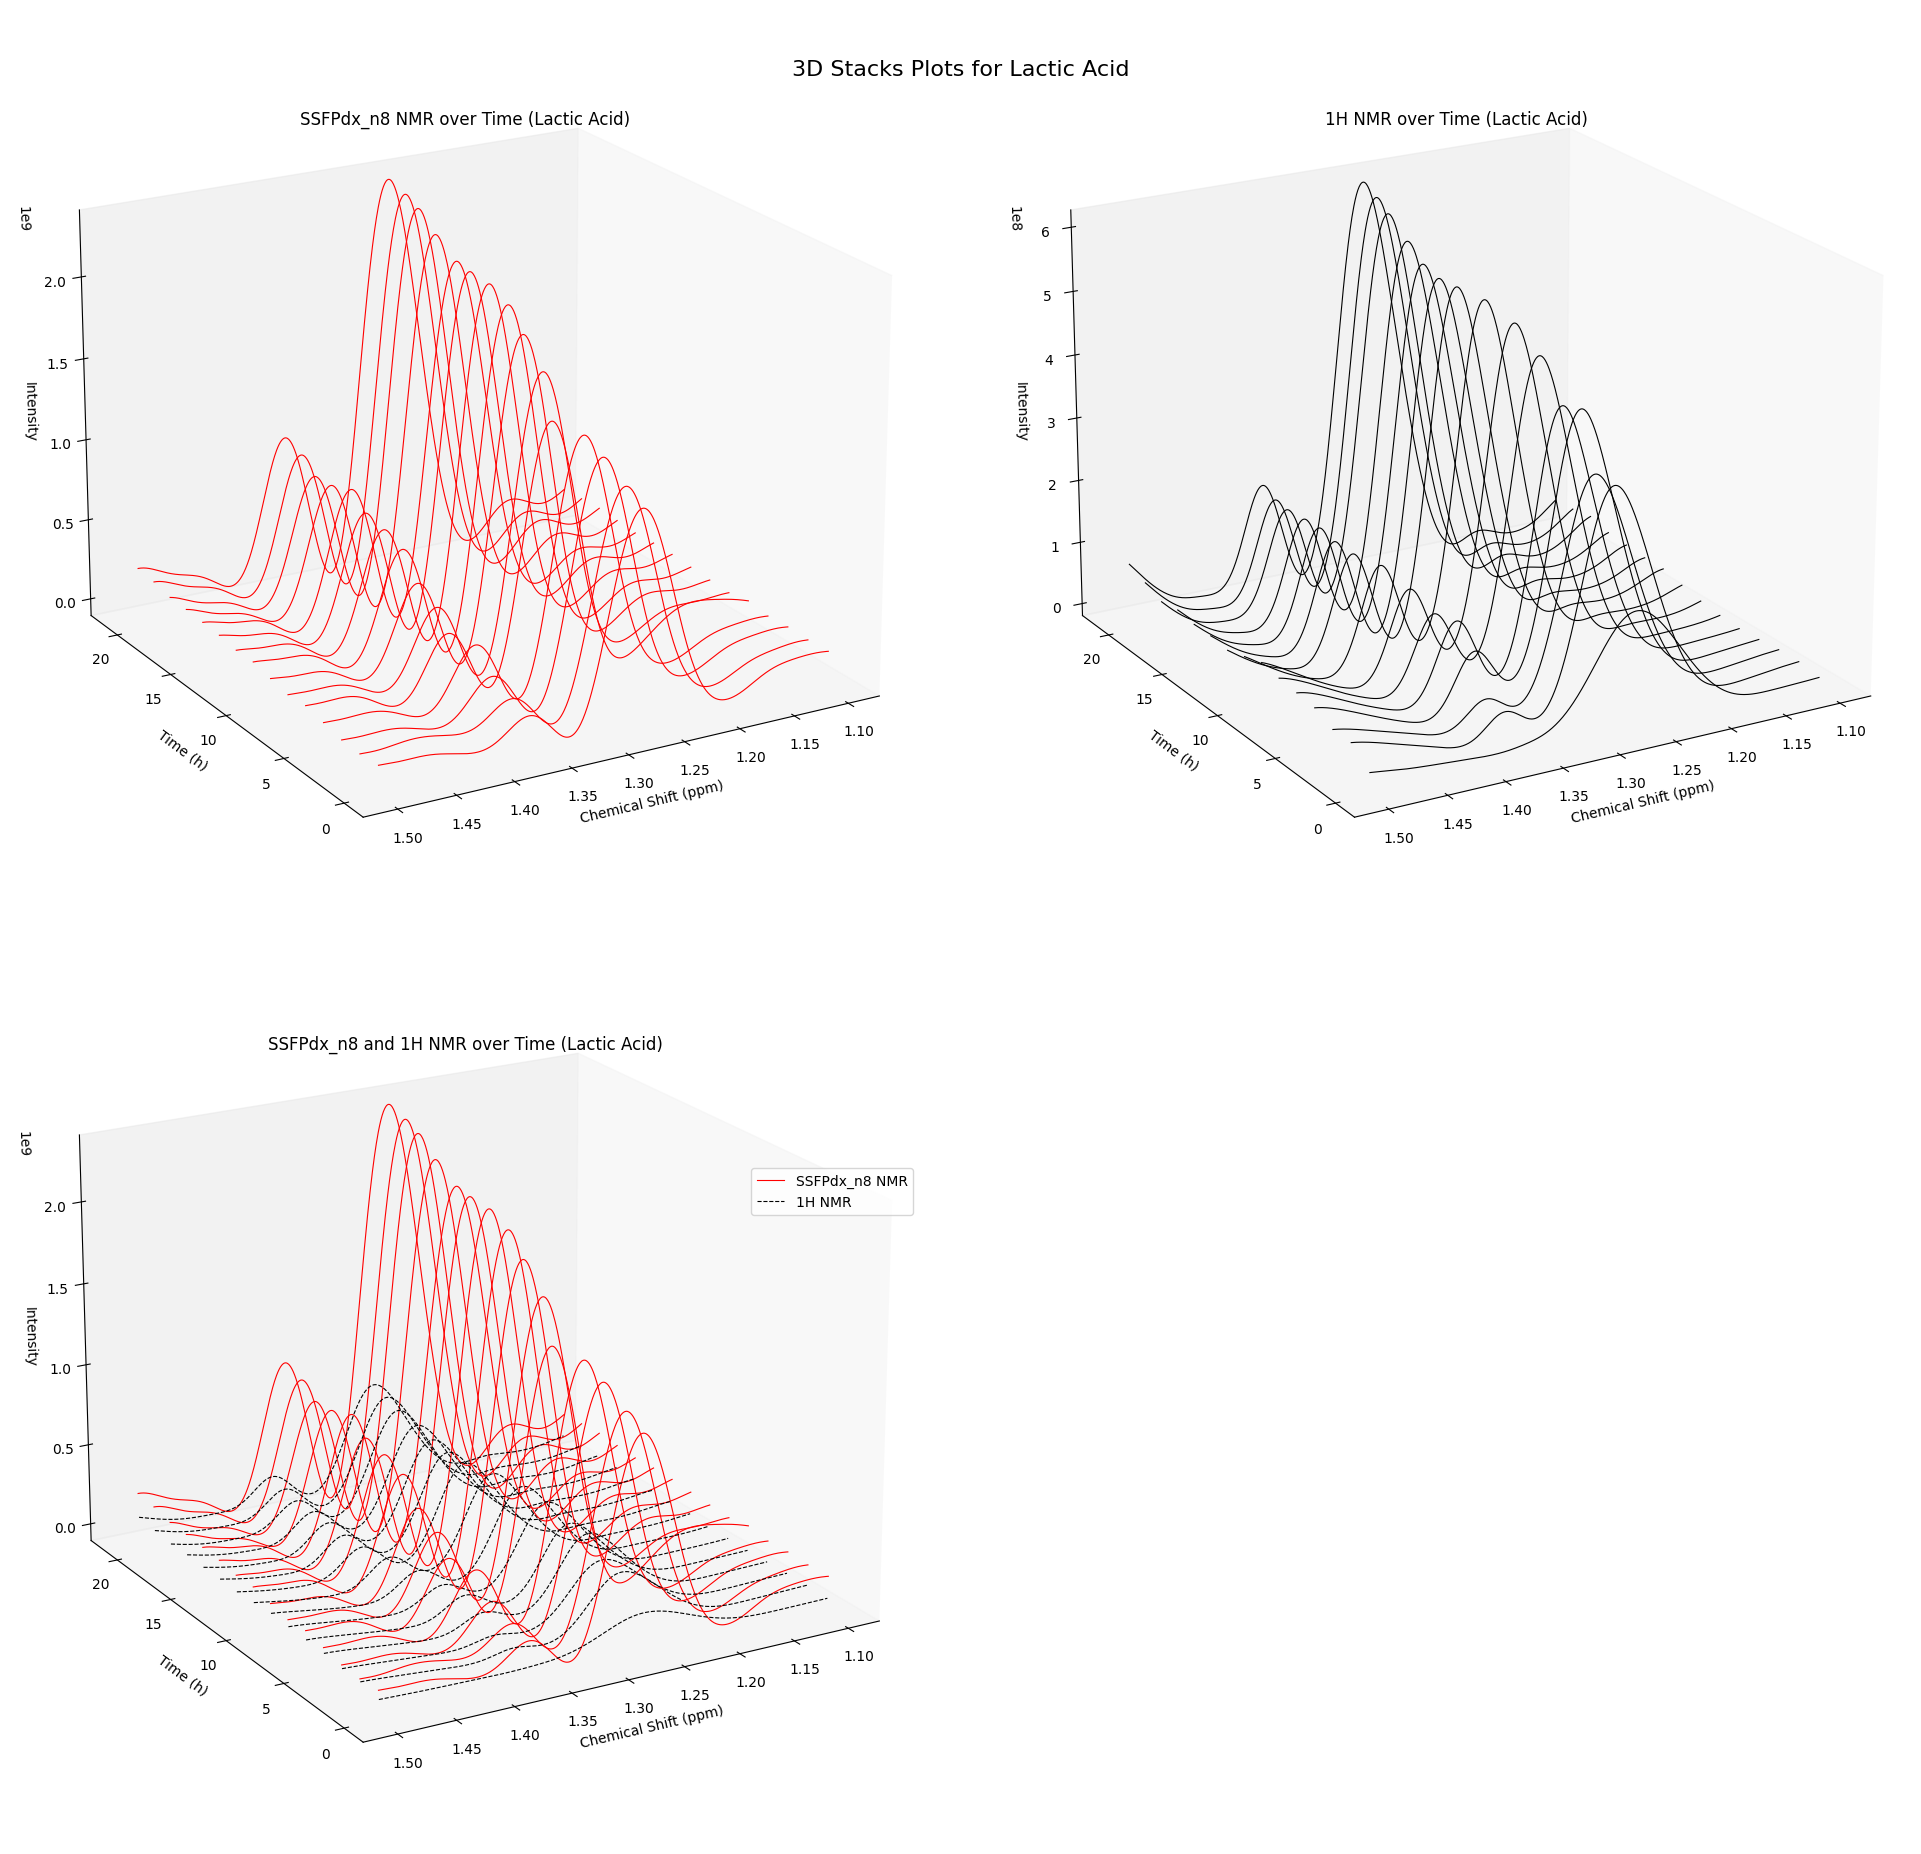

In [ ]:
# Call the new function to generate the 3D line plots
plot_nmr_data_3d_stack('Lactic Acid',
    df_time_files,
    path_ssfp,
    path_proton,
    5,
    0.06,
    1.5,
    1.1,
    141,
    2,
    False
)

###Acetic Acid

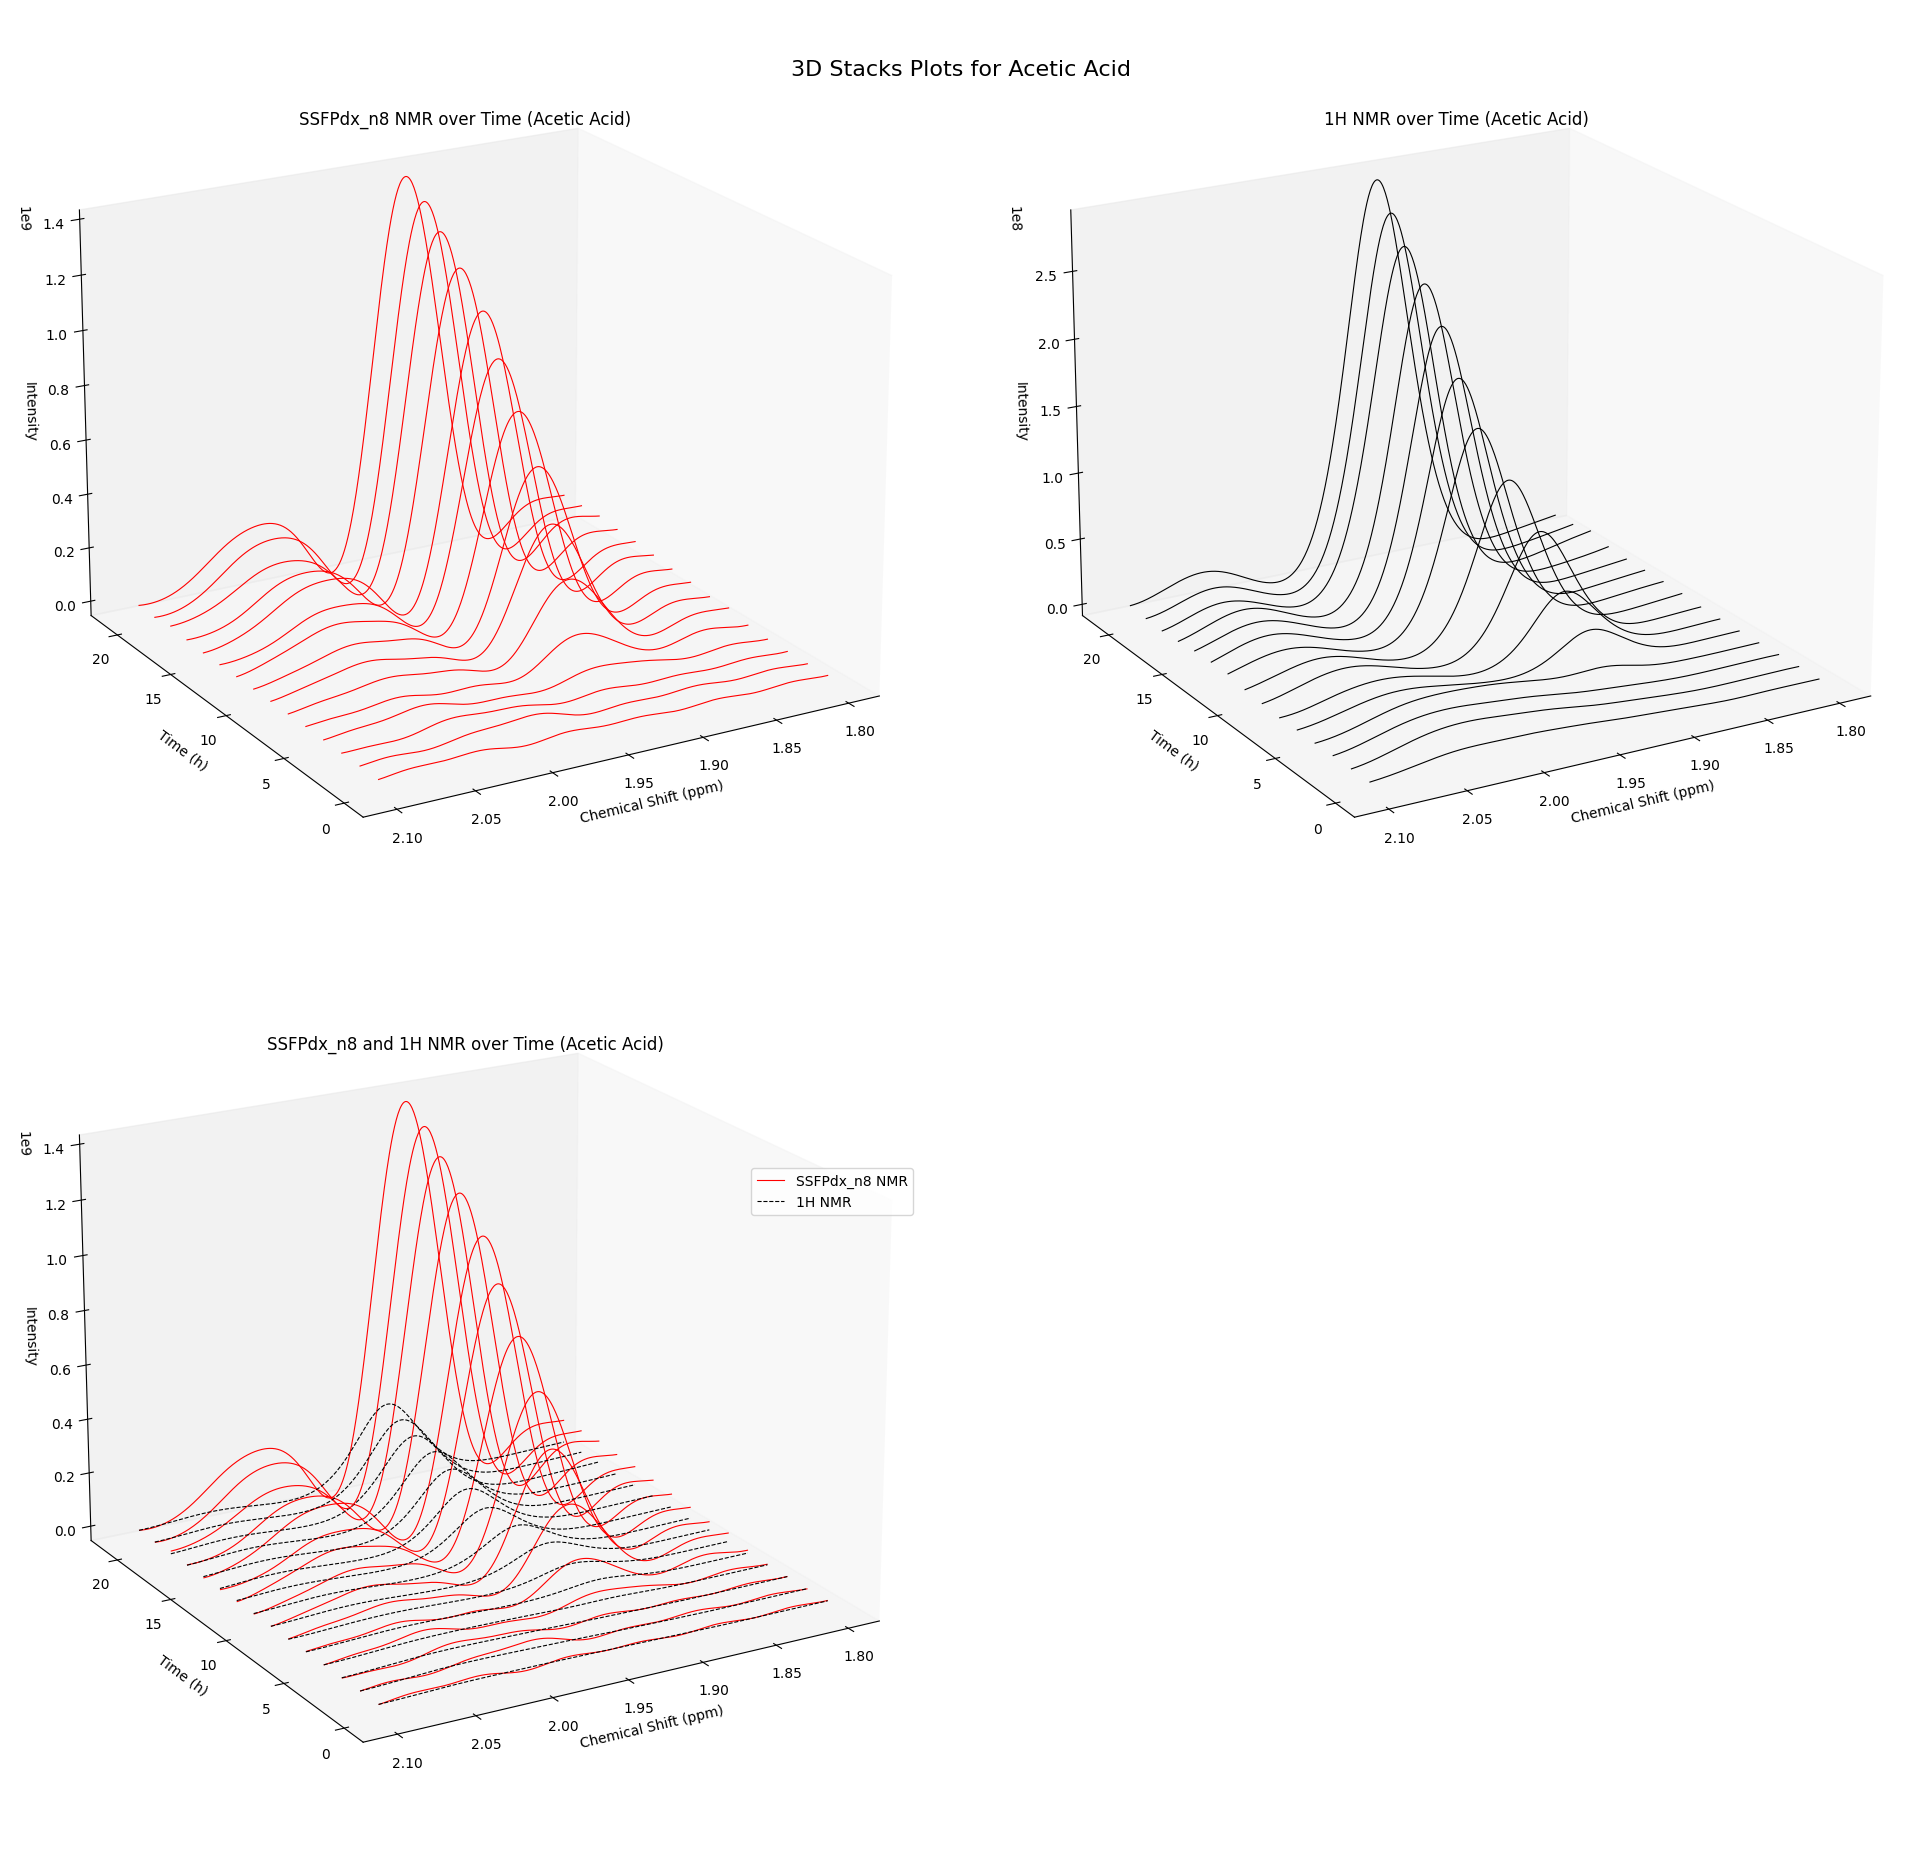

In [ ]:
# Call the new function to generate the 3D line plots
plot_nmr_data_3d_stack('Acetic Acid',
    df_time_files,
    path_ssfp,
    path_proton,
    5,
    0.06,
    2.1,
    1.8,
    141,
    2,
    False
)

###Pyruvic Acid

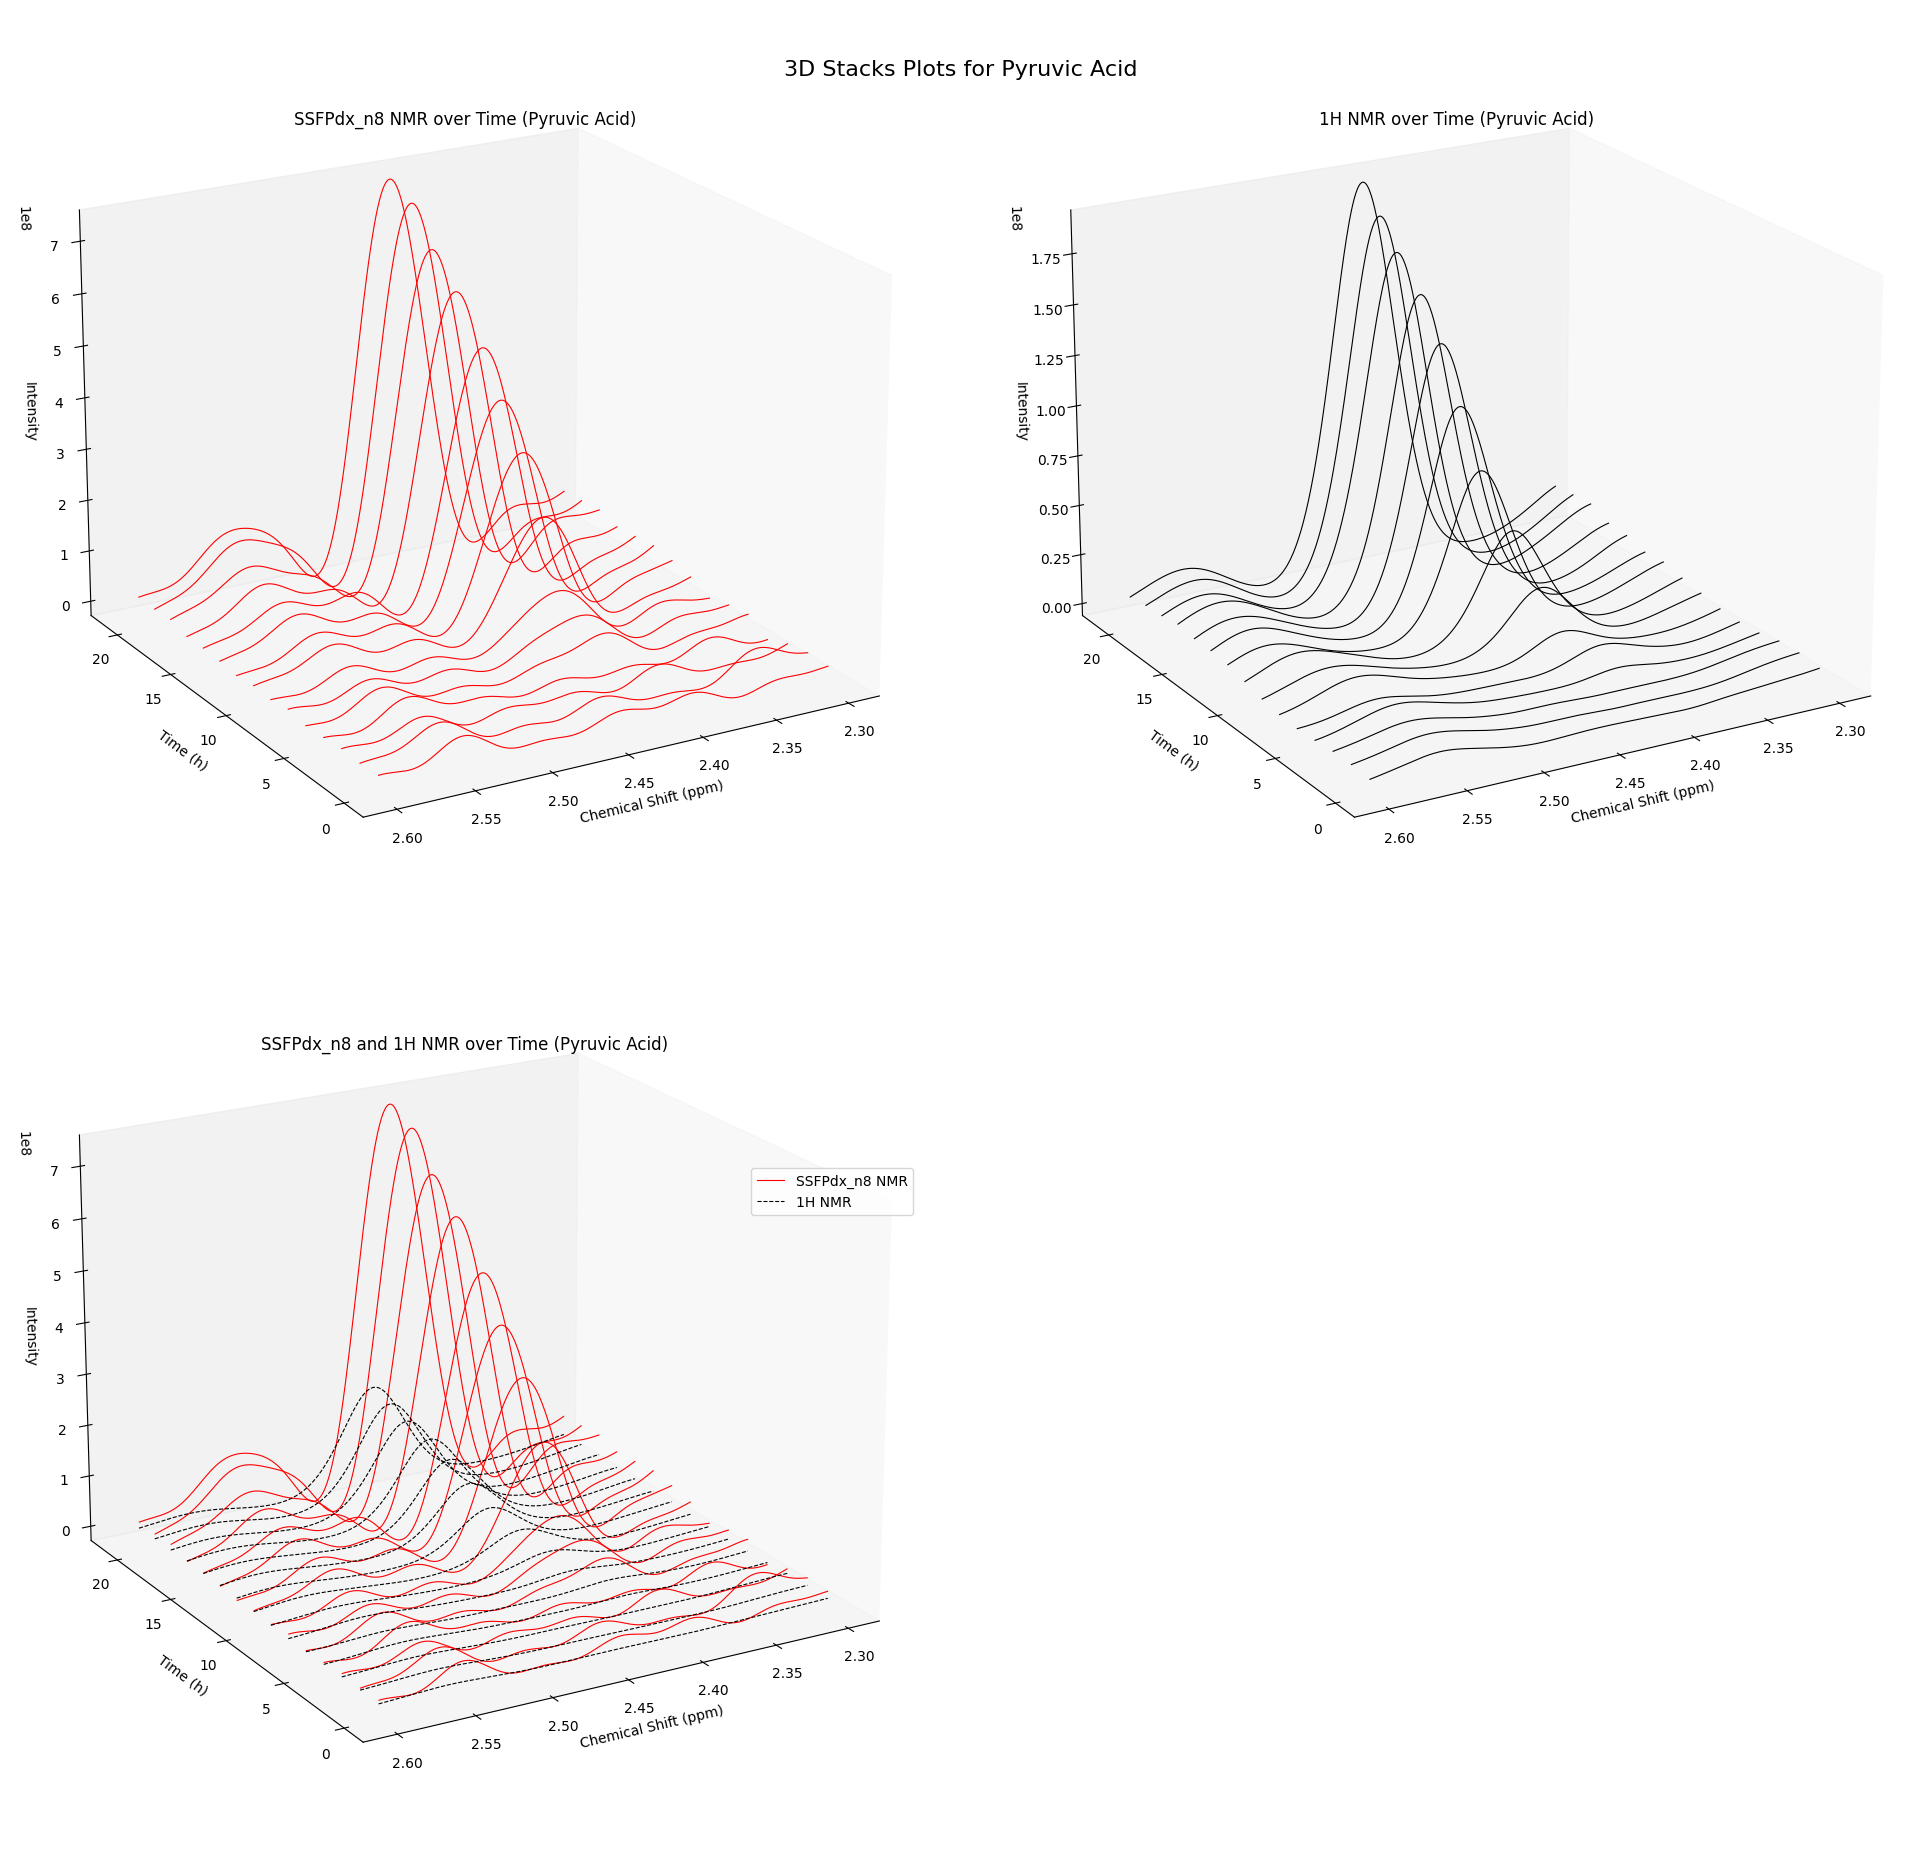

In [ ]:
# Call the new function to generate the 3D line plots
plot_nmr_data_3d_stack('Pyruvic Acid',
    df_time_files,
    path_ssfp,
    path_proton,
    5,
    0.06,
    2.6,
    2.3,
    141,
    2,
    False
)